## **C2 Component — Speech Emotion Recognition & Stress Detection**








# Install & Import Libraries

**What is this?**  
We need special Python tools for audio processing.
- `librosa` → Main audio analysis library (load, features, pitch, energy)
- `torchaudio` → PyTorch GPU-accelerated audio processing
- `torch` → PyTorch deep learning framework
- `sklearn` → Train/test split, metrics
- `matplotlib/seaborn` → Charts and visualizations
- `soundfile` → Fast audio file reading
- `tqdm` → Progress bars

In [11]:
# ================================================================
# Install Required Libraries
# ================================================================

!pip install librosa==0.10.1 -q        # Core audio library
!pip install soundfile -q              # Fast audio file reading
!pip install audioread -q              # Audio format support
!pip install tqdm -q                   # Progress bars
!pip install seaborn -q                # Better plots
!pip install scikit-learn -q           # ML utilities

print('✅ All libraries installed successfully!')

✅ All libraries installed successfully!


In [12]:
# ================================================================
# Import All Libraries
# ================================================================

# ── Standard Python ──
import os
import glob
import json
import hashlib
import warnings
import random
from pathlib import Path
from collections import Counter

# ── Numerical & Data ──
import numpy as np
import pandas as pd

# ── Audio Processing ──
import librosa
import librosa.display
import soundfile as sf
import torchaudio
import torchaudio.transforms as T

# ── Deep Learning ──
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Progress ──
from tqdm import tqdm

# ── Settings ──
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ── Random Seeds ──
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Full Reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── GPU Check ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device       : {DEVICE}')
if torch.cuda.is_available():
    print(f'🚀 GPU Name     : {torch.cuda.get_device_name(0)}')
    print(f'💾 GPU Memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'\n📦 Library Versions:')
print(f'   librosa : {librosa.__version__}')
print(f'   torch   : {torch.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   pandas  : {pd.__version__}')
print('\n✅ All imports successful!')
print('✅ Full reproducibility settings applied!')

🖥️  Device       : cuda
🚀 GPU Name     : Tesla T4
💾 GPU Memory   : 15.6 GB

📦 Library Versions:
   librosa : 0.10.1
   torch   : 2.10.0+cu128
   numpy   : 2.0.2
   pandas  : 2.2.2

✅ All imports successful!
✅ Full reproducibility settings applied!


In [13]:
# ================================================================
# Mount Google Drive
# This will pop up a sign-in window
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

print('✅ Google Drive mounted!')
print('📁 Your files are at: /content/drive/MyDrive/')

# Show what is in your Drive root
print('\n📂 Contents of Google Drive:')
try:
    for item in sorted(os.listdir('/content/drive/MyDrive')):
        print(f'   {item}')
except Exception as e:
    print(f'Error: {e}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!
📁 Your files are at: /content/drive/MyDrive/

📂 Contents of Google Drive:
   Colab Notebooks
   RAVDESS DATASET
   SAVEE DATASET


In [14]:
# ================================================================
# Explore Folder Structure
# ================================================================

SAVEE_PATH  = "/content/drive/MyDrive/SAVEE DATASET"
RAVDESS_PATH = "/content/drive/MyDrive/RAVDESS DATASET"

def explore_folder(path, max_files=5):
    print(f"\n📂 {path}")
    print("=" * 60)

    if not os.path.exists(path):
        print(f"❌ Folder not found: {path}")
        return

    total_wav = 0

    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        indent = '   ' * level
        folder_name = os.path.basename(root)

        # Show folder name
        if level <= 3:
            print(f"{indent}📁 {folder_name}/")

        # Show first few files
        wav_files = [f for f in files if f.endswith('.wav')]
        total_wav += len(wav_files)

        if wav_files and level <= 3:
            subindent = '   ' * (level + 1)
            print(f"{subindent}📄 WAV files: {len(wav_files)}")
            for f in wav_files[:max_files]:
                print(f"{subindent}   → {f}")
            if len(wav_files) > max_files:
                print(f"{subindent}   ... and {len(wav_files) - max_files} more")

    print(f"\n✅ Total WAV files found: {total_wav}")
    return total_wav

print("Exploring SAVEE dataset...")
savee_count = explore_folder(SAVEE_PATH)

print("\n\nExploring RAVDESS dataset...")
ravdess_count = explore_folder(RAVDESS_PATH)

print(f"\n\n📊 SUMMARY:")
print(f"   SAVEE  WAV files : {savee_count}")
print(f"   RAVDESS WAV files: {ravdess_count}")
print(f"   Total            : {savee_count + ravdess_count}")

Exploring SAVEE dataset...

📂 /content/drive/MyDrive/SAVEE DATASET
📁 SAVEE DATASET/
   📄 WAV files: 480
      → DC_a01.wav
      → DC_a09.wav
      → DC_a11.wav
      → DC_a13.wav
      → DC_a05.wav
      ... and 475 more

✅ Total WAV files found: 480


Exploring RAVDESS dataset...

📂 /content/drive/MyDrive/RAVDESS DATASET
📁 RAVDESS DATASET/
   📁 Actor_22/
      📄 WAV files: 60
         → 03-01-03-02-01-01-22.wav
         → 03-01-05-01-01-01-22.wav
         → 03-01-06-02-01-02-22.wav
         → 03-01-06-02-01-01-22.wav
         → 03-01-04-01-01-02-22.wav
         ... and 55 more
   📁 Actor_20/
      📄 WAV files: 60
         → 03-01-02-02-02-01-20.wav
         → 03-01-01-01-01-02-20.wav
         → 03-01-01-01-01-01-20.wav
         → 03-01-02-01-01-02-20.wav
         → 03-01-02-02-01-01-20.wav
         ... and 55 more
   📁 Actor_24/
      📄 WAV files: 60
         → 03-01-02-01-01-01-24.wav
         → 03-01-02-02-02-01-24.wav
         → 03-01-05-02-01-02-24.wav
         → 03-01-05-02-02-0

In [15]:
# ================================================================
# Auto-search SAVEE + RAVDESS WAV files
# ================================================================

import glob
import os
from pathlib import Path

print('🔍 Searching for SAVEE + RAVDESS files...\n')

all_wav_files = glob.glob('/content/drive/MyDrive/**/*.wav', recursive=True)

# ── SAVEE files (DC_, JE_, JK_, KL_) ──
savee_wav_files = [
    f for f in all_wav_files
    if os.path.basename(f).startswith(('DC_', 'JE_', 'JK_', 'KL_'))
]

# ── RAVDESS files (03-01-XX-XX-XX-XX-XX.wav) ──
ravdess_wav_files = [
    f for f in all_wav_files
    if os.path.basename(f).startswith('03-')
    and len(os.path.basename(f).replace('.wav', '').split('-')) == 7
]

print(f'✅ SAVEE   : {len(savee_wav_files)} files  (expected 480)')
print(f'✅ RAVDESS : {len(ravdess_wav_files)} files (expected 1440)')

# ── SAVEE PATH ──
if savee_wav_files:
    SAVEE_PATH = '/content/drive/MyDrive/SAVEE DATASET'
    print(f'\n   SAVEE path  : {SAVEE_PATH}')
else:
    SAVEE_PATH = '/content/drive/MyDrive/SAVEE DATASET'
    print(f'\n⚠️ SAVEE not found. Manual path: {SAVEE_PATH}')

# ── RAVDESS PATH ──
if ravdess_wav_files:
    RAVDESS_PATH = '/content/drive/MyDrive/RAVDESS DATASET'
    print(f'   RAVDESS path: {RAVDESS_PATH}')
else:
    RAVDESS_PATH = '/content/drive/MyDrive/RAVDESS DATASET'
    print(f'⚠️ RAVDESS not found. Manual path: {RAVDESS_PATH}')

print('\n✅ Path detection complete!')

🔍 Searching for SAVEE + RAVDESS files...

✅ SAVEE   : 480 files  (expected 480)
✅ RAVDESS : 1440 files (expected 1440)

   SAVEE path  : /content/drive/MyDrive/SAVEE DATASET
   RAVDESS path: /content/drive/MyDrive/RAVDESS DATASET

✅ Path detection complete!


In [16]:
# ================================================================
# Emotion Label Mapping
# ================================================================

# ── SAVEE Emotion Map ──
# Filename: DC_a01.wav → 'a' = anger
SAVEE_EMOTION_MAP = {
    'a' : 'anger',
    'd' : 'disgust',
    'f' : 'fear',
    'h' : 'happiness',
    'n' : 'neutral',
    'sa': 'sadness',
    'su': 'surprise'
}

# ── RAVDESS Emotion Map ──
# Filename: 03-01-05-01-01-01-01.wav → position[2] = '05' = anger
RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',       # ← skip (SAVEE ❌ )
    '03': 'happiness',
    '04': 'sadness',
    '05': 'anger',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise'
}

# ── Unified Emotions (SAVEE + RAVDESS common) ──
UNIFIED_EMOTIONS = [
    'anger', 'disgust', 'fear',
    'happiness', 'neutral', 'sadness', 'surprise'
]

# ── Numeric Label Map ──
EMOTION_TO_LABEL = {e: i for i, e in enumerate(UNIFIED_EMOTIONS)}
LABEL_TO_EMOTION = {i: e for i, e in enumerate(UNIFIED_EMOTIONS)}

print('✅ Emotion label mapping defined!')
print(f'\n📋 Unified Emotions ({len(UNIFIED_EMOTIONS)} classes):')
for emotion, label in EMOTION_TO_LABEL.items():
    print(f'   {label} → {emotion}')

✅ Emotion label mapping defined!

📋 Unified Emotions (7 classes):
   0 → anger
   1 → disgust
   2 → fear
   3 → happiness
   4 → neutral
   5 → sadness
   6 → surprise


In [17]:
# ================================================================
#  Build DataFrame with Labels
# ================================================================

def extract_savee_label(filename):
    """
    DC_a01.wav  → 'anger'
    DC_sa02.wav → 'sadness'
    DC_su01.wav → 'surprise'
    """
    name = filename.replace('.wav', '')         # DC_a01
    if '_' not in name:
        return None

    emotion_part = name.split('_')[1]           # a01 / sa02 / su01

    # Extract only letters
    code = ''.join([c for c in emotion_part if c.isalpha()])  # 'a' / 'sa' / 'su'

    return SAVEE_EMOTION_MAP.get(code, None)


def extract_ravdess_label(filename):
    """
    03-01-05-01-01-01-01.wav → position[2]='05' → 'anger'
    """
    name = filename.replace('.wav', '')
    parts = name.split('-')

    if len(parts) != 7:
        return None

    emotion_code = parts[2]                     # '05'
    emotion = RAVDESS_EMOTION_MAP.get(emotion_code, None)

    # Skip 'calm' — not in SAVEE
    if emotion == 'calm':
        return None

    return emotion


# ── Build SAVEE records ──
savee_records = []
for filepath in savee_wav_files:
    filename = os.path.basename(filepath)
    emotion  = extract_savee_label(filename)

    if emotion and emotion in UNIFIED_EMOTIONS:
        savee_records.append({
            'filepath' : filepath,
            'filename' : filename,
            'emotion'  : emotion,
            'label'    : EMOTION_TO_LABEL[emotion],
            'dataset'  : 'SAVEE'
        })

# ── Build RAVDESS records ──
ravdess_records = []
for filepath in ravdess_wav_files:
    filename = os.path.basename(filepath)
    emotion  = extract_ravdess_label(filename)

    if emotion and emotion in UNIFIED_EMOTIONS:
        ravdess_records.append({
            'filepath' : filepath,
            'filename' : filename,
            'emotion'  : emotion,
            'label'    : EMOTION_TO_LABEL[emotion],
            'dataset'  : 'RAVDESS'
        })

# ── Combine ──
df = pd.DataFrame(savee_records + ravdess_records)

print('✅ DataFrame built successfully!')
print(f'\n📊 Dataset Summary:')
print(f'   SAVEE   records : {len(savee_records)}')
print(f'   RAVDESS records : {len(ravdess_records)}')
print(f'   Total           : {len(df)}')
print(f'\n📋 Columns: {list(df.columns)}')
print(f'\n🔍 Sample rows:')
print(df.head(5).to_string(index=False))

✅ DataFrame built successfully!

📊 Dataset Summary:
   SAVEE   records : 480
   RAVDESS records : 1248
   Total           : 1728

📋 Columns: ['filepath', 'filename', 'emotion', 'label', 'dataset']

🔍 Sample rows:
                                       filepath   filename emotion  label dataset
/content/drive/MyDrive/SAVEE DATASET/DC_a01.wav DC_a01.wav   anger      0   SAVEE
/content/drive/MyDrive/SAVEE DATASET/DC_a09.wav DC_a09.wav   anger      0   SAVEE
/content/drive/MyDrive/SAVEE DATASET/DC_a11.wav DC_a11.wav   anger      0   SAVEE
/content/drive/MyDrive/SAVEE DATASET/DC_a13.wav DC_a13.wav   anger      0   SAVEE
/content/drive/MyDrive/SAVEE DATASET/DC_a05.wav DC_a05.wav   anger      0   SAVEE


In [18]:
# ================================================================
#  Verify Labels (Sanity Check)
# ================================================================

print(' LABEL VERIFICATION')
print('=' * 50)

# ── SAVEE: spot check ──
print('\n SAVEE label samples:')
savee_sample = df[df['dataset'] == 'SAVEE'].sample(8, random_state=42)
for _, row in savee_sample.iterrows():
    print(f'   {row["filename"]:<20} → {row["emotion"]:<12} (label={row["label"]})')

# ── RAVDESS: spot check ──
print('\n RAVDESS label samples:')
ravdess_sample = df[df['dataset'] == 'RAVDESS'].sample(8, random_state=42)
for _, row in ravdess_sample.iterrows():
    parts = row['filename'].replace('.wav','').split('-')
    code  = parts[2] if len(parts) == 7 else '??'
    print(f'   {row["filename"]:<35} code={code} → {row["emotion"]:<12} (label={row["label"]})')

# ── Check for None/missing labels ──
missing_labels = df[df['emotion'].isna()]
print(f'\n  Missing labels : {len(missing_labels)}')

# ── Emotion distribution ──
print(f'\n📊 Emotion Distribution:')
dist = df.groupby(['emotion','dataset']).size().unstack(fill_value=0)
dist['TOTAL'] = dist.sum(axis=1)
print(dist.to_string())

 LABEL VERIFICATION

 SAVEE label samples:
   DC_sa12.wav          → sadness      (label=5)
   KL_d13.wav           → disgust      (label=1)
   KL_a01.wav           → anger        (label=0)
   JK_f11.wav           → fear         (label=2)
   KL_h09.wav           → happiness    (label=3)
   JE_h11.wav           → happiness    (label=3)
   JK_f07.wav           → fear         (label=2)
   KL_d15.wav           → disgust      (label=1)

 RAVDESS label samples:
   03-01-01-01-01-01-11.wav            code=01 → neutral      (label=4)
   03-01-08-02-01-01-09.wav            code=08 → surprise     (label=6)
   03-01-04-01-01-01-07.wav            code=04 → sadness      (label=5)
   03-01-03-02-01-01-21.wav            code=03 → happiness    (label=3)
   03-01-04-01-01-01-18.wav            code=04 → sadness      (label=5)
   03-01-08-01-02-02-23.wav            code=08 → surprise     (label=6)
   03-01-03-02-02-02-21.wav            code=03 → happiness    (label=3)
   03-01-05-02-01-01-20.wav         

In [19]:
# ================================================================
# Data Quality Check
# (Missing + Duplicate + Corrupted)
# ================================================================

print('🔍 DATA QUALITY CHECK')
print('=' * 60)

OUTPUT_DIR = '/content/drive/MyDrive/C2_Research'
os.makedirs(OUTPUT_DIR, exist_ok=True)

quality_log = []
corrupted_idx  = []
duplicate_idx  = []

# ──────────────────────────────────────────
# CHECK 1: Missing files
# ──────────────────────────────────────────
print('\n[1/3] Checking missing files...')
missing_idx = []
for idx, row in df.iterrows():
    if not os.path.exists(row['filepath']):
        missing_idx.append(idx)
        quality_log.append({
            'filename': row['filename'],
            'dataset' : row['dataset'],
            'issue'   : 'FILE_MISSING',
            'detail'  : row['filepath']
        })

print(f'   ❌ Missing files : {len(missing_idx)}')
if missing_idx:
    df = df.drop(index=missing_idx).reset_index(drop=True)

# ──────────────────────────────────────────
# CHECK 2: Duplicate files (MD5 hash)
# ──────────────────────────────────────────
print('\n[2/3] Checking duplicate files (MD5)...')
hash_list = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='   Hashing'):
    try:
        with open(row['filepath'], 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        hash_list.append(h)
    except:
        hash_list.append('READ_ERROR')

df['md5'] = hash_list

# Find duplicates
seen_hashes = {}
for idx, row in df.iterrows():
    h = row['md5']
    if h == 'READ_ERROR':
        continue
    if h in seen_hashes:
        duplicate_idx.append(idx)
        quality_log.append({
            'filename': row['filename'],
            'dataset' : row['dataset'],
            'issue'   : 'DUPLICATE',
            'detail'  : f'Same content as {seen_hashes[h]}'
        })
    else:
        seen_hashes[h] = row['filename']

print(f'   🔁 Duplicate files: {len(duplicate_idx)}')
if duplicate_idx:
    df = df.drop(index=duplicate_idx).reset_index(drop=True)

df = df.drop(columns=['md5'])

# ──────────────────────────────────────────
# CHECK 3: Corrupted files
# ──────────────────────────────────────────
print('\n[3/3] Checking corrupted files...')

corrupted_idx = []
file_stats    = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='   Checking'):
    stat = {
        'filename'    : row['filename'],
        'dataset'     : row['dataset'],
        'emotion'     : row['emotion'],
        'status'      : 'OK',
        'issue'       : None,
        'duration_s'  : None,
        'file_size_kb': None,
        'rms_energy'  : None,
        'sample_rate' : None
    }

    is_corrupted = False

    # ── File size ──
    try:
        size = os.path.getsize(row['filepath'])
        stat['file_size_kb'] = round(size / 1024, 2)
        if size == 0:
            stat['status'] = 'CORRUPTED'
            stat['issue']  = 'Zero byte file'
            is_corrupted   = True
    except Exception as e:
        stat['status'] = 'CORRUPTED'
        stat['issue']  = f'Size check failed: {e}'
        is_corrupted   = True

    if not is_corrupted:
        # ── librosa load ──
        try:
            audio, sr = librosa.load(row['filepath'], sr=16000, mono=True)
            duration  = len(audio) / sr
            stat['sample_rate'] = sr
            stat['duration_s']  = round(duration, 3)
            stat['rms_energy']  = round(float(np.sqrt(np.mean(audio**2))), 6)

            # Too short
            if duration < 0.5:
                stat['status'] = 'CORRUPTED'
                stat['issue']  = f'Too short: {duration:.2f}s'
                is_corrupted   = True

            # Silent
            elif stat['rms_energy'] < 0.0001:
                stat['status'] = 'WARNING'
                stat['issue']  = f'Silent audio (RMS={stat["rms_energy"]})'

            # NaN / Inf
            elif np.any(np.isnan(audio)) or np.any(np.isinf(audio)):
                stat['status'] = 'CORRUPTED'
                stat['issue']  = 'NaN or Inf values in audio'
                is_corrupted   = True

        except Exception as e:
            stat['status'] = 'CORRUPTED'
            stat['issue']  = f'Load failed: {e}'
            is_corrupted   = True

    if is_corrupted:
        corrupted_idx.append(idx)
        quality_log.append({
            'filename': row['filename'],
            'dataset' : row['dataset'],
            'issue'   : stat['status'],
            'detail'  : stat['issue']
        })

    file_stats.append(stat)

stats_df = pd.DataFrame(file_stats)
print(f'\n   ✅ OK files       : {len(stats_df[stats_df["status"]=="OK"])}')
print(f'   ⚠️  WARNING files  : {len(stats_df[stats_df["status"]=="WARNING"])}')
print(f'   ❌ CORRUPTED files: {len(stats_df[stats_df["status"]=="CORRUPTED"])}')

if corrupted_idx:
    corrupted_files = stats_df[stats_df['status']=='CORRUPTED']
    print(f'\n   Corrupted file details:')
    print(corrupted_files[['filename','dataset','issue']].to_string(index=False))
    df = df.drop(index=corrupted_idx).reset_index(drop=True)

🔍 DATA QUALITY CHECK

[1/3] Checking missing files...
   ❌ Missing files : 0

[2/3] Checking duplicate files (MD5)...


   Hashing: 100%|██████████| 1728/1728 [12:56<00:00,  2.23it/s]


   🔁 Duplicate files: 1

[3/3] Checking corrupted files...


   Checking: 100%|██████████| 1727/1727 [00:20<00:00, 83.11it/s] 


   ✅ OK files       : 1727
   ⚠️  WARNING files  : 0
   ❌ CORRUPTED files: 0


In [20]:
# ================================================================
# Final Quality Report + Save
# ================================================================

print('\n' + '=' * 60)
print('📋 FINAL DATA QUALITY REPORT')
print('=' * 60)

ok_stats = stats_df[stats_df['status'].isin(['OK','WARNING'])]

print(f'\n📁 Original files : {len(savee_records) + len(ravdess_records)}')
print(f'🗑️  Removed        : {len(missing_idx) + len(duplicate_idx) + len(corrupted_idx)}')
print(f'   ├─ Missing      : {len(missing_idx)}')
print(f'   ├─ Duplicates   : {len(duplicate_idx)}')
print(f'   └─ Corrupted    : {len(corrupted_idx)}')
print(f'✅ Clean files     : {len(df)}')

print(f'\n📈 Duration Stats (clean files):')
print(f'   Min    : {ok_stats["duration_s"].min():.2f}s')
print(f'   Max    : {ok_stats["duration_s"].max():.2f}s')
print(f'   Mean   : {ok_stats["duration_s"].mean():.2f}s')
print(f'   Median : {ok_stats["duration_s"].median():.2f}s')

print(f'\n📊 Emotion Distribution (clean):')
dist = df['emotion'].value_counts()
for emotion, count in dist.items():
    bar   = '█' * (count // 20)
    pct   = count / len(df) * 100
    print(f'   {emotion:<12}: {count:4d} ({pct:5.1f}%) {bar}')

max_c = dist.max()
min_c = dist.min()
ratio = max_c / min_c
print(f'\n⚖️  Imbalance ratio : {ratio:.2f}x ', end='')
print('→ Use Focal Loss ✓' if ratio > 2 else '→ Acceptable ✓')

# ── Save clean DataFrame ──
clean_csv = f'{OUTPUT_DIR}/clean_dataset.csv'
df.to_csv(clean_csv, index=False)

# ── Save quality log ──
if quality_log:
    log_df = pd.DataFrame(quality_log)
    log_df.to_csv(f'{OUTPUT_DIR}/quality_log.csv', index=False)
    print(f'\n💾 Quality log saved!')

print(f'💾 Clean dataset saved → {clean_csv}')
print(f'\n✅ Data Quality Check COMPLETE!')
print(f'   df now has {len(df)} clean rows ready for preprocessing.')


📋 FINAL DATA QUALITY REPORT

📁 Original files : 1728
🗑️  Removed        : 1
   ├─ Missing      : 0
   ├─ Duplicates   : 1
   └─ Corrupted    : 0
✅ Clean files     : 1727

📈 Duration Stats (clean files):
   Min    : 1.63s
   Max    : 7.14s
   Mean   : 3.73s
   Median : 3.64s

📊 Emotion Distribution (clean):
   anger       :  252 ( 14.6%) ████████████
   disgust     :  252 ( 14.6%) ████████████
   fear        :  252 ( 14.6%) ████████████
   sadness     :  252 ( 14.6%) ████████████
   surprise    :  252 ( 14.6%) ████████████
   happiness   :  251 ( 14.5%) ████████████
   neutral     :  216 ( 12.5%) ██████████

⚖️  Imbalance ratio : 1.17x → Acceptable ✓

💾 Quality log saved!
💾 Clean dataset saved → /content/drive/MyDrive/C2_Research/clean_dataset.csv

✅ Data Quality Check COMPLETE!
   df now has 1727 clean rows ready for preprocessing.


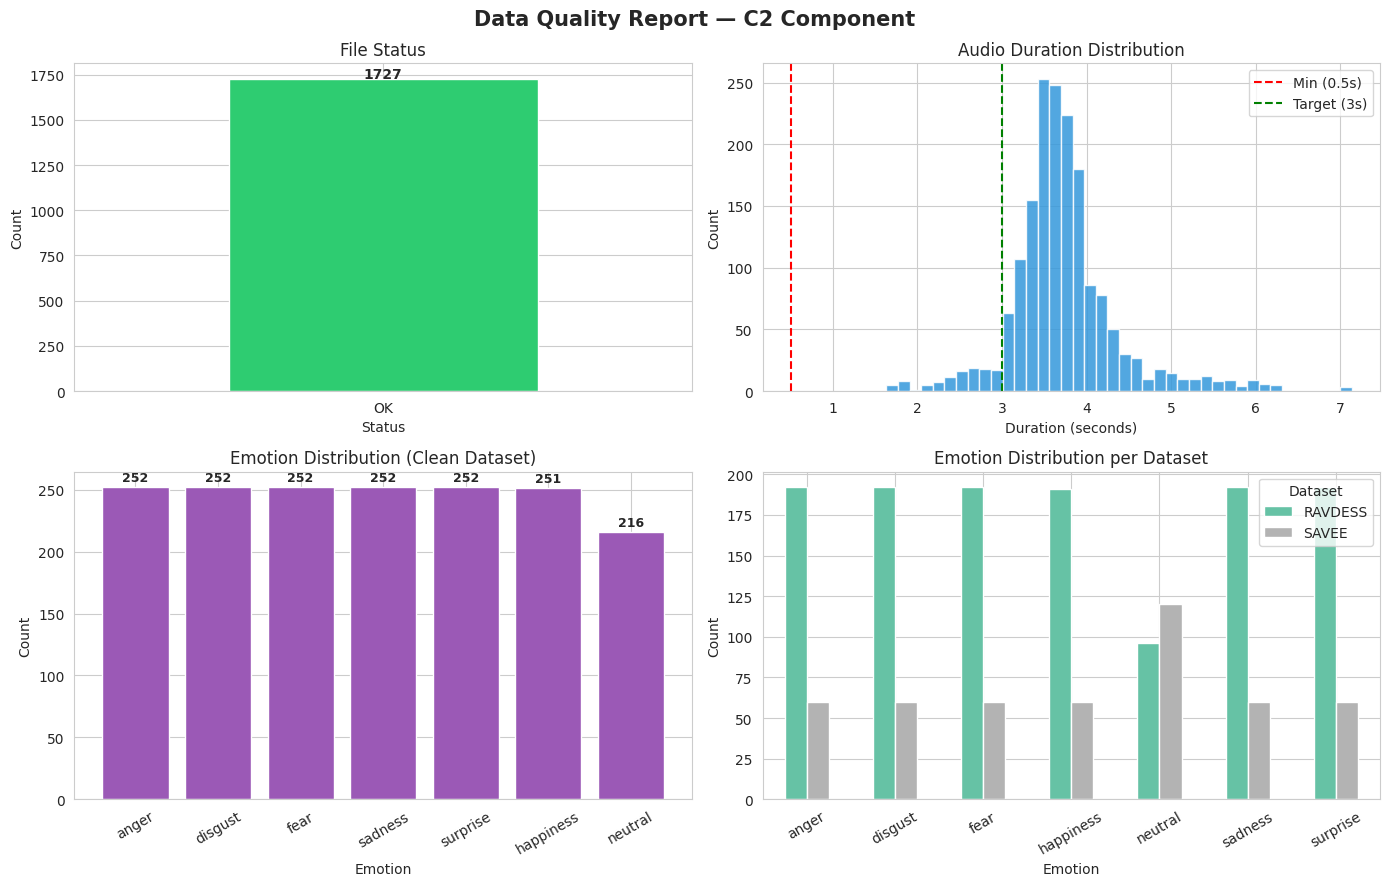

📊 Chart saved → /content/drive/MyDrive/C2_Research/quality_report.png


In [21]:
# ================================================================
# Visualize Quality Results
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Data Quality Report — C2 Component', fontsize=15, fontweight='bold')

# ── Plot 1: File Status ──
status_counts = stats_df['status'].value_counts()
colors = {'OK':'#2ecc71', 'WARNING':'#f39c12', 'CORRUPTED':'#e74c3c'}
color_list = [colors.get(s, '#3498db') for s in status_counts.index]
status_counts.plot(kind='bar', ax=axes[0,0], color=color_list, edgecolor='white')
axes[0,0].set_title('File Status')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(status_counts):
    axes[0,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ── Plot 2: Duration Distribution ──
ok_dur = stats_df[stats_df['status'].isin(['OK','WARNING'])]['duration_s'].dropna()
axes[0,1].hist(ok_dur, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0,1].axvline(0.5, color='red',   linestyle='--', linewidth=1.5, label='Min (0.5s)')
axes[0,1].axvline(3.0, color='green', linestyle='--', linewidth=1.5, label='Target (3s)')
axes[0,1].set_title('Audio Duration Distribution')
axes[0,1].set_xlabel('Duration (seconds)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# ── Plot 3: Emotion Distribution ──
emotion_counts = df['emotion'].value_counts()
bars = axes[1,0].bar(emotion_counts.index, emotion_counts.values,
                      color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Emotion Distribution (Clean Dataset)')
axes[1,0].set_xlabel('Emotion')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, emotion_counts.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 5,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 4: Per-Dataset Breakdown ──
cross = df.groupby(['dataset','emotion']).size().unstack(fill_value=0)
cross.T.plot(kind='bar', ax=axes[1,1], colormap='Set2', edgecolor='white')
axes[1,1].set_title('Emotion Distribution per Dataset')
axes[1,1].set_xlabel('Emotion')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(title='Dataset')

plt.tight_layout()
viz_path = f'{OUTPUT_DIR}/quality_report.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Chart saved → {viz_path}')

In [22]:
# ================================================================
# Audio Config (All 3 Models same)
# ================================================================

# ── Audio Settings ──
SAMPLE_RATE  = 16000
DURATION     = 4.0
N_SAMPLES    = int(SAMPLE_RATE * DURATION)   # 64000

# ── Mel Spectrogram Settings ──
N_MELS       = 128
N_FFT        = 1024
HOP_LENGTH   = 512
N_MFCC       = 40

print('✅ Audio configuration set!')
print(f'\n📋 Settings:')
print(f'   Sample Rate  : {SAMPLE_RATE} Hz')
print(f'   Duration     : {DURATION}s')
print(f'   Total Samples: {N_SAMPLES}')
print(f'   Mel Bands    : {N_MELS}')
print(f'   MFCC Coefs   : {N_MFCC}')
print(f'   FFT Window   : {N_FFT}')
print(f'   Hop Length   : {HOP_LENGTH}')

print(f'\n📐 Expected feature shapes:')
print(f'   Raw audio      : ({N_SAMPLES},)        → wav2vec2 input')
print(f'   Mel spectrogram: ({N_MELS}, 126)       → CNN-LSTM + Transformer input')
print(f'   MFCC+delta2    : ({N_MFCC*3}, 126)     → delta+delta2 stacked temporal features')
print(f'   Note: 126 frames = librosa internal padding (actual verified in Cell 4.3)')

✅ Audio configuration set!

📋 Settings:
   Sample Rate  : 16000 Hz
   Duration     : 4.0s
   Total Samples: 64000
   Mel Bands    : 128
   MFCC Coefs   : 40
   FFT Window   : 1024
   Hop Length   : 512

📐 Expected feature shapes:
   Raw audio      : (64000,)        → wav2vec2 input
   Mel spectrogram: (128, 126)       → CNN-LSTM + Transformer input
   MFCC+delta2    : (120, 126)     → delta+delta2 stacked temporal features
   Note: 126 frames = librosa internal padding (actual verified in Cell 4.3)


In [23]:
# ================================================================
# Core Preprocessing Functions-with pyin()
# ================================================================

def load_audio(filepath):
    try:
        audio, sr = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
        if len(audio) > N_SAMPLES:
            audio = audio[:N_SAMPLES]
        elif len(audio) < N_SAMPLES:
            audio = np.pad(audio, (0, N_SAMPLES - len(audio)), mode='constant')
        return audio.astype(np.float32)
    except Exception as e:
        print(f'Load error: {os.path.basename(filepath)} -> {e}')
        return None


def normalize_audio(audio):
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio


def extract_mel_spectrogram(audio):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SAMPLE_RATE,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmin=20, fmax=8000
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-6)
    return log_mel.astype(np.float32)


def extract_mfcc(audio):
    mfcc   = librosa.feature.mfcc(
        y=audio, sr=SAMPLE_RATE,
        n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc_full = np.vstack([mfcc, delta, delta2])
    mfcc_full = (mfcc_full - mfcc_full.mean()) / (mfcc_full.std() + 1e-6)
    return mfcc_full.astype(np.float32)


def extract_pitch_energy(audio):
    """
    FIX v3: yin() -> pyin() (probabilistic YIN)

    WHY pyin() instead of yin():
    - yin()  is O(N^2), slow for 1727 files (~30+ min)
    - pyin() is faster + returns voiced_flag automatically
    - voiced_flag=True means the frame has valid pitch
    - NaN returned for unvoiced frames (clean filtering)
    - No manual energy threshold needed for voiced detection
    - Same pitch range (C2-C7) keeps Appraisal Theory mapping intact

    Dissertation note: "Pitch extracted using probabilistic YIN (pyin)
    algorithm (librosa) which provides voiced/unvoiced classification
    per frame. Only voiced frames with f0 in 80-500 Hz used for
    arousal gate computation."
    """
    # pyin — probabilistic YIN
    f0, voiced_flag, voiced_probs = librosa.pyin(
        audio,
        fmin=librosa.note_to_hz('C2'),
        fmax=librosa.note_to_hz('C7'),
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH
    )

    energy = librosa.feature.rms(
        y=audio,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH
    )[0]

    # Voiced frames: voiced_flag=True AND f0 not NaN
    voiced_f0 = f0[voiced_flag & ~np.isnan(f0)]

    # Human speech range: 80-500 Hz
    valid_pitch = voiced_f0[(voiced_f0 > 80) & (voiced_f0 < 500)]

    pitch_mean  = float(np.mean(valid_pitch))  if len(valid_pitch) > 0 else 0.0
    pitch_std   = float(np.std(valid_pitch))   if len(valid_pitch) > 0 else 0.0
    energy_mean = float(np.mean(energy))
    energy_std  = float(np.std(energy))

    return {
        'pitch_mean'  : pitch_mean,
        'pitch_std'   : pitch_std,
        'energy_mean' : energy_mean,
        'energy_std'  : energy_std
    }


def preprocess_one_file(filepath):
    """Single file full preprocessing pipeline."""
    audio = load_audio(filepath)
    if audio is None:
        return None

    # Silence trim BEFORE normalize
    audio, _ = librosa.effects.trim(audio, top_db=20)

    # Re-pad/truncate after trim
    if len(audio) < N_SAMPLES:
        audio = np.pad(audio, (0, N_SAMPLES - len(audio)), mode='constant')
    else:
        audio = audio[:N_SAMPLES]

    audio = normalize_audio(audio)

    return {
        'audio_raw'       : audio,
        'mel_spectrogram' : extract_mel_spectrogram(audio),
        'mfcc'            : extract_mfcc(audio),
        **extract_pitch_energy(audio)
    }


print('FIXED v3 preprocessing functions loaded!')
print('Fix: yin() replaced with pyin() (probabilistic YIN)')
print('voiced_flag built-in — no manual energy threshold needed')
print()
print('Model compatibility:')
print('  CNN-LSTM    : mel_spectrogram (128, 126)')
print('  Transformer : mel_spectrogram (128, 126)')
print('  wav2vec2    : audio_raw (64000,)')


FIXED v3 preprocessing functions loaded!
Fix: yin() replaced with pyin() (probabilistic YIN)
voiced_flag built-in — no manual energy threshold needed

Model compatibility:
  CNN-LSTM    : mel_spectrogram (128, 126)
  Transformer : mel_spectrogram (128, 126)
  wav2vec2    : audio_raw (64000,)


AUDIO PREPROCESSING — 3-STEP VISUALIZATION

🧪 Preprocessing Test:
   File           : DC_a01.wav
   Raw samples    : 160868 @ 44100Hz
   Raw duration   : 3.65s
   Raw max amp    : 1.0000
   Final samples  : 64000 @ 16000Hz
   Final duration : 4.00s
   Final max amp  : 1.0000


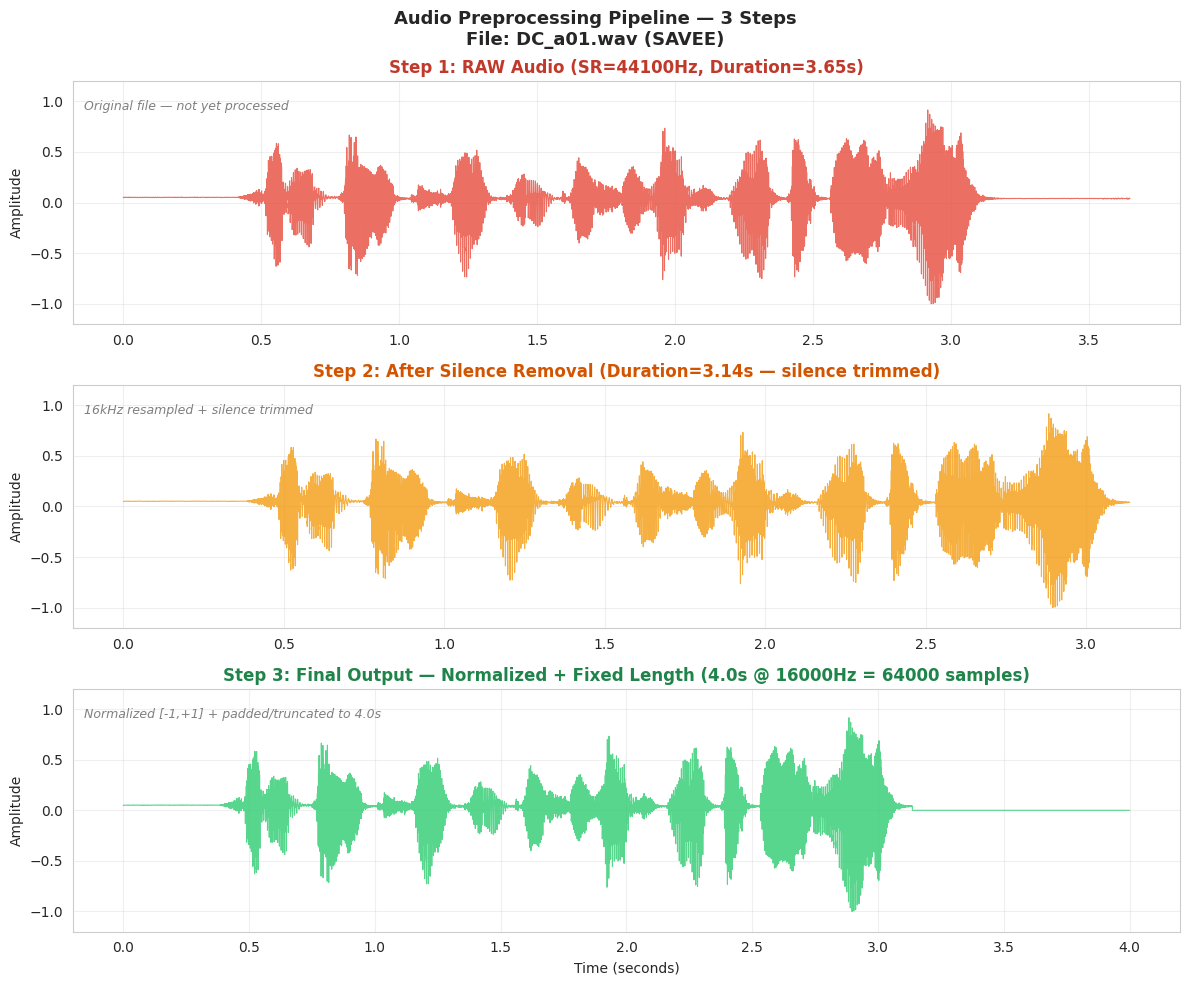

✅ 3-step visualization saved!
   mel shape : (128, 126)
   mfcc shape: (120, 126)
   audio raw : (64000,)


In [24]:
# ================================================================
# 3-Step Visualization ONLY
# preprocess_audio() REMOVED — preprocess_one_file() use කරනවා
# Pre-emphasis REMOVED — wav2vec2 incompatible
# ================================================================

print('='*60)
print('AUDIO PREPROCESSING — 3-STEP VISUALIZATION')
print('='*60)

# Test file
savee_sample  = df[df['dataset'] == 'SAVEE'].iloc[0]['filepath']
raw_audio, raw_sr = librosa.load(savee_sample, sr=None)

# Step 2 intermediate (silence trim only, no pre-emphasis)
audio_s2, _   = librosa.load(savee_sample, sr=SAMPLE_RATE, mono=True)
audio_s2, _   = librosa.effects.trim(audio_s2, top_db=20)

# Final output via preprocess_one_file
result        = preprocess_one_file(savee_sample)
processed_audio = result['audio_raw']

print(f'\n🧪 Preprocessing Test:')
print(f'   File           : {os.path.basename(savee_sample)}')
print(f'   Raw samples    : {len(raw_audio)} @ {raw_sr}Hz')
print(f'   Raw duration   : {len(raw_audio)/raw_sr:.2f}s')
print(f'   Raw max amp    : {np.max(np.abs(raw_audio)):.4f}')
print(f'   Final samples  : {len(processed_audio)} @ {SAMPLE_RATE}Hz')
print(f'   Final duration : {len(processed_audio)/SAMPLE_RATE:.2f}s')
print(f'   Final max amp  : {np.max(np.abs(processed_audio)):.4f}')

# ── 3-Step Visualization ──
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Step 1: Raw Audio
t_raw = np.linspace(0, len(raw_audio)/raw_sr, len(raw_audio))
axes[0].plot(t_raw, raw_audio, color='#e74c3c', alpha=0.8, linewidth=0.8)
axes[0].set_title(
    f'Step 1: RAW Audio (SR={raw_sr}Hz, '
    f'Duration={len(raw_audio)/raw_sr:.2f}s)',
    fontweight='bold', color='#c0392b')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1.2, 1.2)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Original file — not yet processed',
    xy=(0.01, 0.88), xycoords='axes fraction',
    fontsize=9, color='gray', style='italic')

# Step 2: Silence Removal only (NO pre-emphasis)
t_s2 = np.linspace(0, len(audio_s2)/SAMPLE_RATE, len(audio_s2))
axes[1].plot(t_s2, audio_s2, color='#f39c12', alpha=0.8, linewidth=0.8)
axes[1].set_title(
    f'Step 2: After Silence Removal '
    f'(Duration={len(audio_s2)/SAMPLE_RATE:.2f}s — silence trimmed)',
    fontweight='bold', color='#d35400')
axes[1].set_ylabel('Amplitude')
axes[1].set_ylim(-1.2, 1.2)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('16kHz resampled + silence trimmed',
    xy=(0.01, 0.88), xycoords='axes fraction',
    fontsize=9, color='gray', style='italic')

# Step 3: Final Output
t_proc = np.linspace(0, DURATION, len(processed_audio))
axes[2].plot(t_proc, processed_audio, color='#2ecc71', alpha=0.8, linewidth=0.8)
axes[2].set_title(
    f'Step 3: Final Output — Normalized + Fixed Length '
    f'({DURATION}s @ {SAMPLE_RATE}Hz = {N_SAMPLES} samples)',
    fontweight='bold', color='#1e8449')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylim(-1.2, 1.2)
axes[2].grid(True, alpha=0.3)
axes[2].annotate('Normalized [-1,+1] + padded/truncated to 4.0s',
    xy=(0.01, 0.88), xycoords='axes fraction',
    fontsize=9, color='gray', style='italic')

plt.suptitle(
    f'Audio Preprocessing Pipeline — 3 Steps\n'
    f'File: {os.path.basename(savee_sample)} (SAVEE)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preprocessing_3step_demo.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 3-step visualization saved!')
print(f'   mel shape : {result["mel_spectrogram"].shape}')
print(f'   mfcc shape: {result["mfcc"].shape}')
print(f'   audio raw : {result["audio_raw"].shape}')

SAVEE vs RAVDESS — Preprocessing Comparison


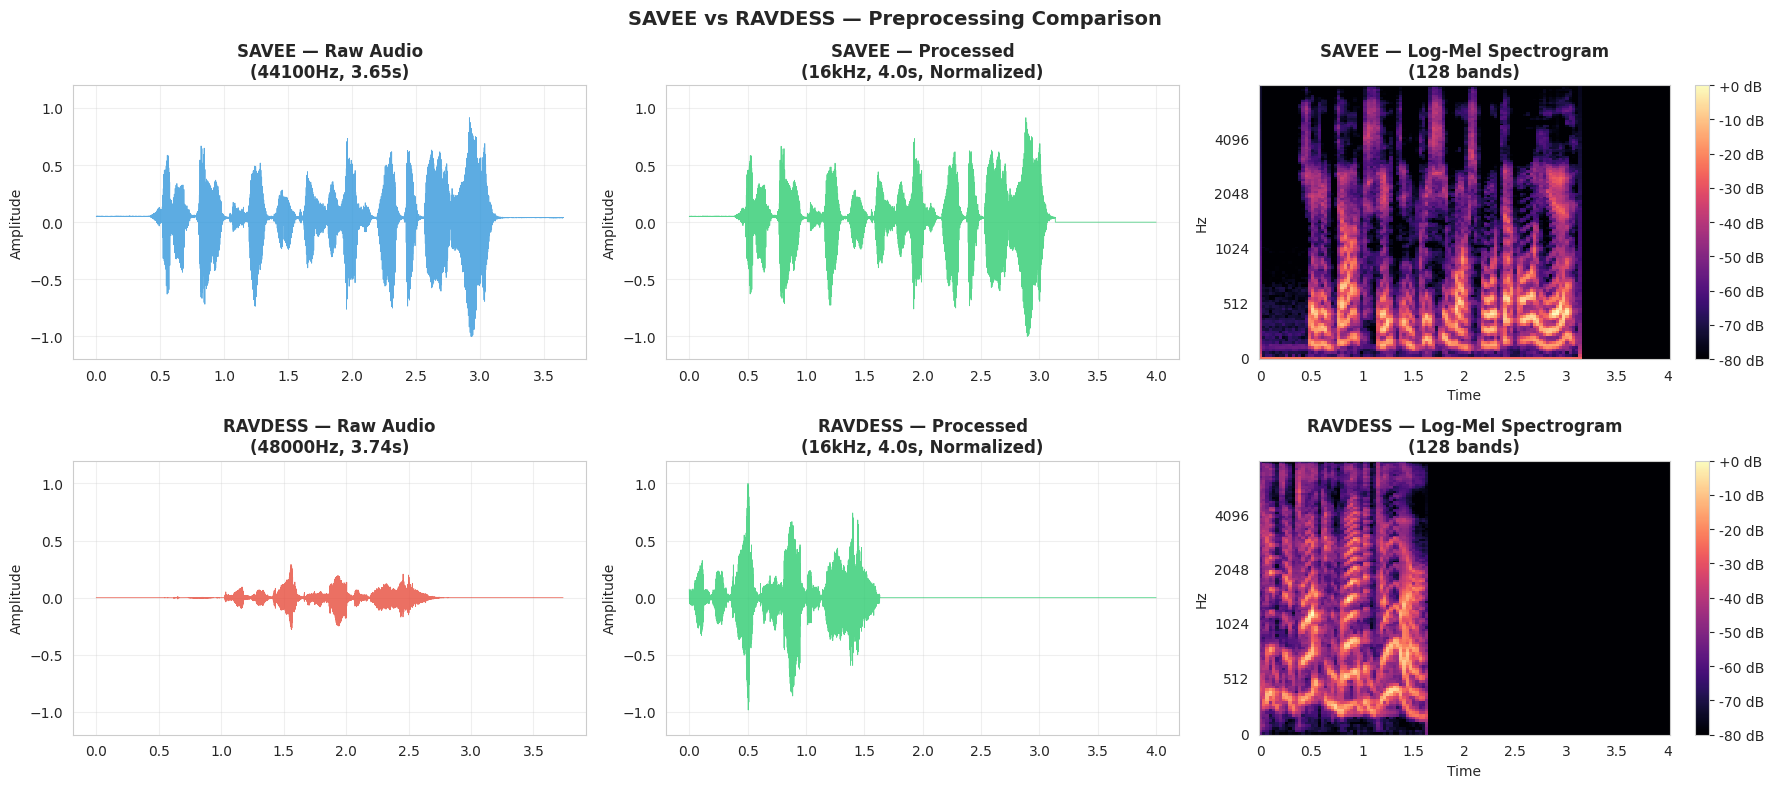

✅ SAVEE vs RAVDESS comparison saved!


In [25]:
# ================================================================
# SAVEE vs RAVDESS Preprocessing Comparison Plot
# ================================================================
print('SAVEE vs RAVDESS — Preprocessing Comparison')

savee_fp   = df[df['dataset'] == 'SAVEE'].iloc[0]['filepath']
ravdess_fp = df[df['dataset'] == 'RAVDESS'].iloc[0]['filepath']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for row, (fp, label, color) in enumerate([
    (savee_fp,   'SAVEE',   '#3498db'),
    (ravdess_fp, 'RAVDESS', '#e74c3c')
]):
    raw, raw_sr = librosa.load(fp, sr=None)

    # ✅ preprocess_one_file() use කරනවා
    result = preprocess_one_file(fp)
    proc   = result['audio_raw']

    # Raw waveform
    t_raw = np.linspace(0, len(raw)/raw_sr, len(raw))
    axes[row,0].plot(t_raw, raw, color=color, alpha=0.8, linewidth=0.6)
    axes[row,0].set_title(
        f'{label} — Raw Audio\n({raw_sr}Hz, {len(raw)/raw_sr:.2f}s)',
        fontweight='bold')
    axes[row,0].set_ylabel('Amplitude')
    axes[row,0].set_ylim(-1.2, 1.2)
    axes[row,0].grid(True, alpha=0.3)

    # Processed waveform
    t_proc = np.linspace(0, DURATION, len(proc))
    axes[row,1].plot(t_proc, proc, color='#2ecc71', alpha=0.8, linewidth=0.6)
    axes[row,1].set_title(
        f'{label} — Processed\n(16kHz, {DURATION}s, Normalized)',
        fontweight='bold')
    axes[row,1].set_ylabel('Amplitude')
    axes[row,1].set_ylim(-1.2, 1.2)
    axes[row,1].grid(True, alpha=0.3)

    # Mel Spectrogram
    mel     = librosa.feature.melspectrogram(
        y=proc, sr=SAMPLE_RATE,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    img     = librosa.display.specshow(
        log_mel, sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel',
        ax=axes[row,2], cmap='magma'
    )
    axes[row,2].set_title(
        f'{label} — Log-Mel Spectrogram\n(128 bands)',
        fontweight='bold')
    plt.colorbar(img, ax=axes[row,2], format='%+2.0f dB')

plt.suptitle(
    'SAVEE vs RAVDESS — Preprocessing Comparison',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/savee_vs_ravdess_preprocessing.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ SAVEE vs RAVDESS comparison saved!')

In [27]:
# ================================================================
# Test without arousal key
# ================================================================

print('🔍 Testing preprocessing on sample files...\n')

print(f'{"Emotion":<12} {"Dataset":<8} {"Mel Shape":<14} {"Pitch Hz":<12} {"Energy":<10}')
print('-' * 58)

all_ok = True
for emotion in UNIFIED_EMOTIONS:
    row      = df[df['emotion'] == emotion].iloc[0]
    features = preprocess_one_file(row['filepath'])

    if features is None:
        print(f'{emotion:<12} ❌ FAILED')
        all_ok = False
        continue

    print(
        f'{emotion:<12} '
        f'{row["dataset"]:<8} '
        f'{str(features["mel_spectrogram"].shape):<14} '
        f'{features["pitch_mean"]:>8.1f} Hz  '
        f'{features["energy_mean"]:>8.4f}'
    )

print('\n' + '─' * 58)
if all_ok:
    print('✅ All emotions processed successfully!')
    print('✅ Shapes verified!')

else:
    print('⚠️  Some files failed')

🔍 Testing preprocessing on sample files...

Emotion      Dataset  Mel Shape      Pitch Hz     Energy    
----------------------------------------------------------
anger        SAVEE    (128, 126)        163.8 Hz    0.1131
disgust      SAVEE    (128, 126)        139.6 Hz    0.0679
fear         SAVEE    (128, 126)        176.2 Hz    0.0827
happiness    SAVEE    (128, 126)        208.2 Hz    0.1836
neutral      SAVEE    (128, 126)        127.2 Hz    0.1800
sadness      SAVEE    (128, 126)        184.5 Hz    0.1245
surprise     SAVEE    (128, 126)        200.2 Hz    0.1271

──────────────────────────────────────────────────────────
✅ All emotions processed successfully!
✅ Shapes verified!


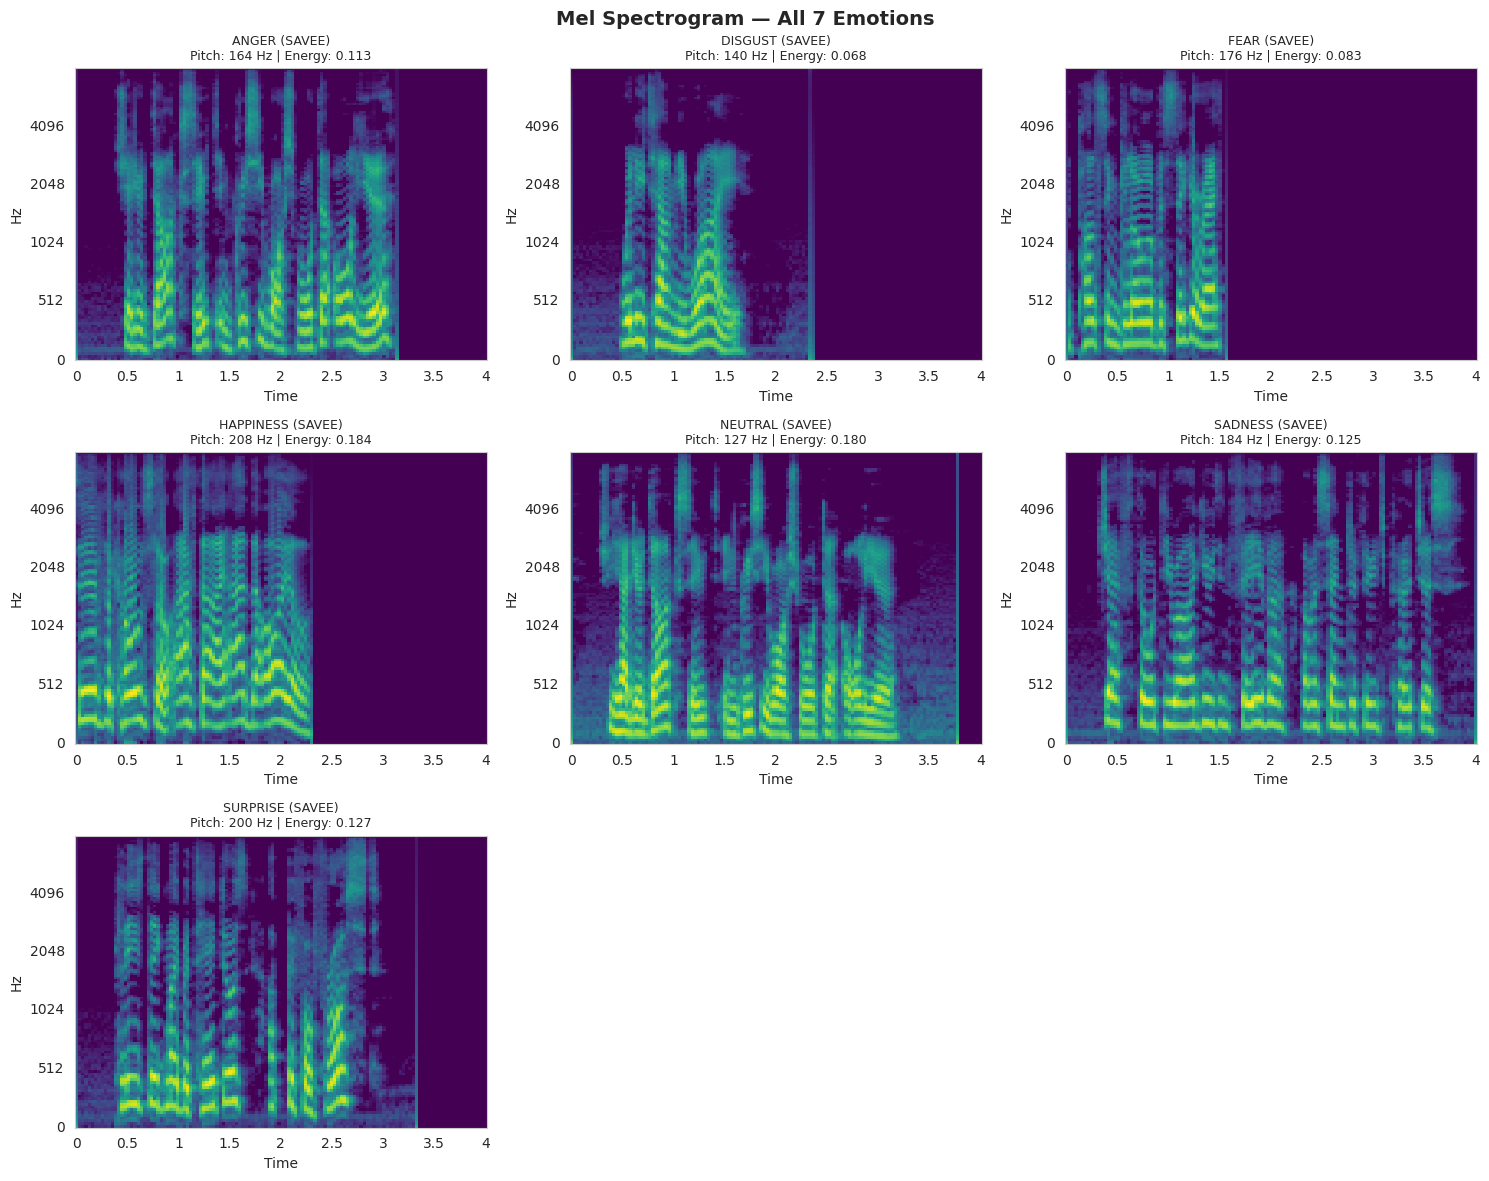

📊 Visualization saved!


In [28]:
# ================================================================
# Visualization without arousal key
# ================================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Mel Spectrogram — All 7 Emotions', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, emotion in enumerate(UNIFIED_EMOTIONS):
    row      = df[df['emotion'] == emotion].iloc[0]
    features = preprocess_one_file(row['filepath'])

    if features is None:
        continue

    librosa.display.specshow(
        features['mel_spectrogram'],
        sr         = SAMPLE_RATE,
        hop_length = HOP_LENGTH,
        x_axis     = 'time',
        y_axis     = 'mel',
        ax         = axes[i],
        cmap       = 'viridis'
    )
    axes[i].set_title(
        f'{emotion.upper()} ({row["dataset"]})\n'
        f'Pitch: {features["pitch_mean"]:.0f} Hz | '
        f'Energy: {features["energy_mean"]:.3f}',
        fontsize=9
    )

axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mel_all_emotions.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Visualization saved!')

PREPROCESSING STATISTICS — Before vs After


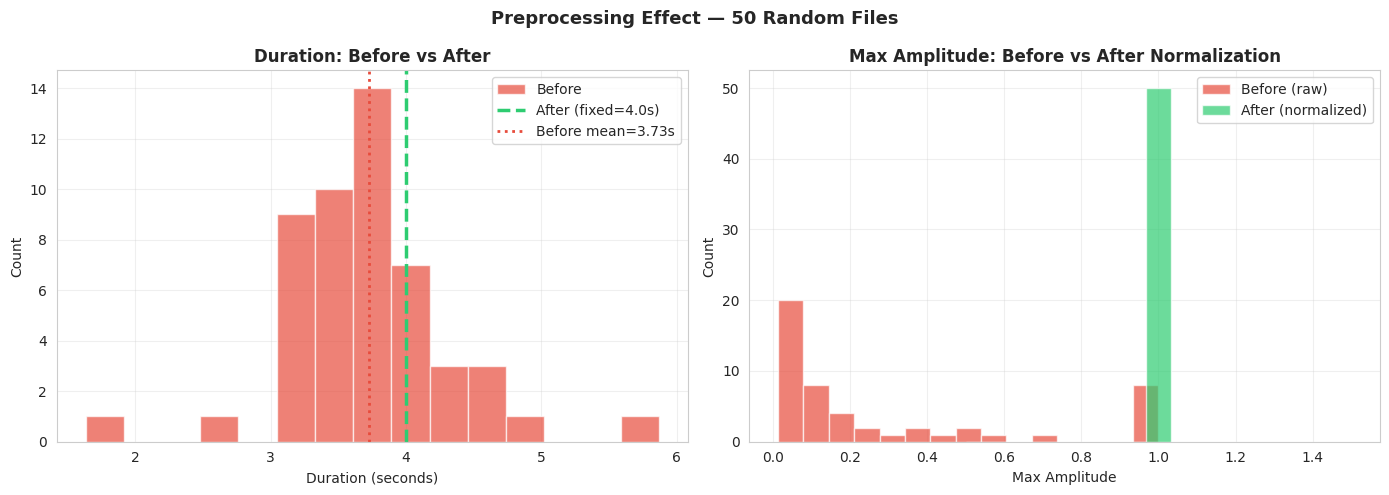


📊 Stats Summary:
   Duration before : 3.73s ± 0.63s
   Duration after  : 4.0s (fixed) ✅
   Max amp before  : 0.2950 ± 0.3431
   Max amp after   : 1.0000 (normalized) ✅
✅ Preprocessing stats saved!


In [29]:
# ================================================================
# Preprocessing Statistics: Before vs After
# ================================================================
print('PREPROCESSING STATISTICS — Before vs After')

sample_files = df.sample(50, random_state=42)

before_durations = []
after_durations  = []
before_amps      = []
after_amps       = []

for _, row in sample_files.iterrows():
    try:
        raw, raw_sr = librosa.load(row['filepath'], sr=None)

        # ✅ preprocess_one_file() use කරනවා
        result = preprocess_one_file(row['filepath'])
        proc   = result['audio_raw']

        before_durations.append(len(raw) / raw_sr)
        after_durations.append(DURATION)
        before_amps.append(float(np.max(np.abs(raw))))
        after_amps.append(float(np.max(np.abs(proc))))
    except:
        continue

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration comparison
axes[0].hist(before_durations, bins=15, alpha=0.7,
             color='#e74c3c', label='Before', edgecolor='white')
axes[0].axvline(DURATION, color='#2ecc71', linewidth=2.5,
                linestyle='--', label=f'After (fixed={DURATION}s)')
axes[0].axvline(np.mean(before_durations), color='#e74c3c',
                linewidth=2, linestyle=':',
                label=f'Before mean={np.mean(before_durations):.2f}s')
axes[0].set_title('Duration: Before vs After', fontweight='bold')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Amplitude comparison
axes[1].hist(before_amps, bins=15, alpha=0.7,
             color='#e74c3c', label='Before (raw)',
             edgecolor='white')
axes[1].hist(after_amps, bins=15, alpha=0.7,
             color='#2ecc71', label='After (normalized)',
             edgecolor='white')
axes[1].set_title('Max Amplitude: Before vs After Normalization',
                  fontweight='bold')
axes[1].set_xlabel('Max Amplitude')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Preprocessing Effect — 50 Random Files',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preprocessing_stats.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Stats Summary:')
print(f'   Duration before : {np.mean(before_durations):.2f}s ± {np.std(before_durations):.2f}s')
print(f'   Duration after  : {DURATION}s (fixed) ✅')
print(f'   Max amp before  : {np.mean(before_amps):.4f} ± {np.std(before_amps):.4f}')
print(f'   Max amp after   : {np.mean(after_amps):.4f} (normalized) ✅')
print('✅ Preprocessing stats saved!')

📊 Plotting per-emotion waveforms...


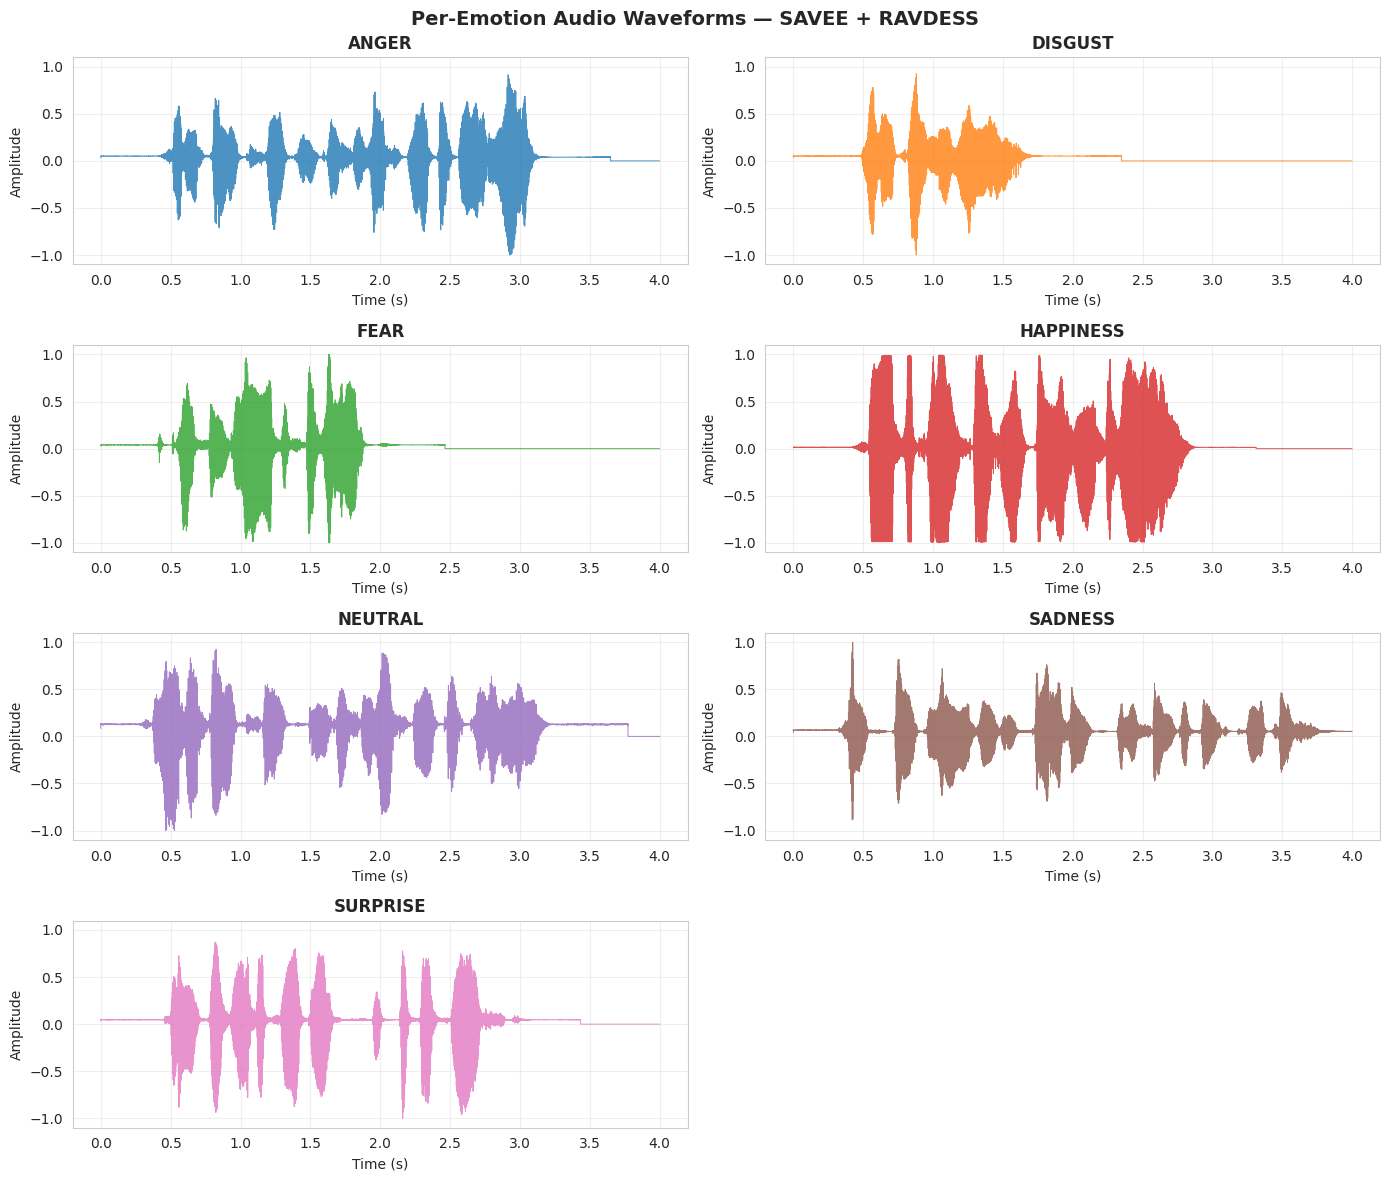

✅ Waveform visualization saved!


In [30]:
# ================================================================
# Per-Emotion Waveform Visualization
# ================================================================

print('📊 Plotting per-emotion waveforms...')

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (label_id, emotion) in enumerate(LABEL_TO_EMOTION.items()):
    emotion_rows = df[df['emotion'] == emotion]
    if len(emotion_rows) > 0:
        filepath  = emotion_rows.iloc[0]['filepath']
        audio     = load_audio(filepath)
        audio     = normalize_audio(audio)
        time_axis = np.linspace(0, DURATION, len(audio))

        axes[i].plot(time_axis, audio,
                     color=f'C{i}', alpha=0.8, linewidth=0.7)
        axes[i].set_title(f'{emotion.upper()}', fontweight='bold', fontsize=12)
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Amplitude')
        axes[i].set_ylim(-1.1, 1.1)
        axes[i].grid(True, alpha=0.3)

# Hide last empty subplot (4x2=8, emotions=7)
axes[-1].set_visible(False)

plt.suptitle('Per-Emotion Audio Waveforms — SAVEE + RAVDESS',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/per_emotion_waveforms.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Waveform visualization saved!')

📊 Plotting speaker distribution...


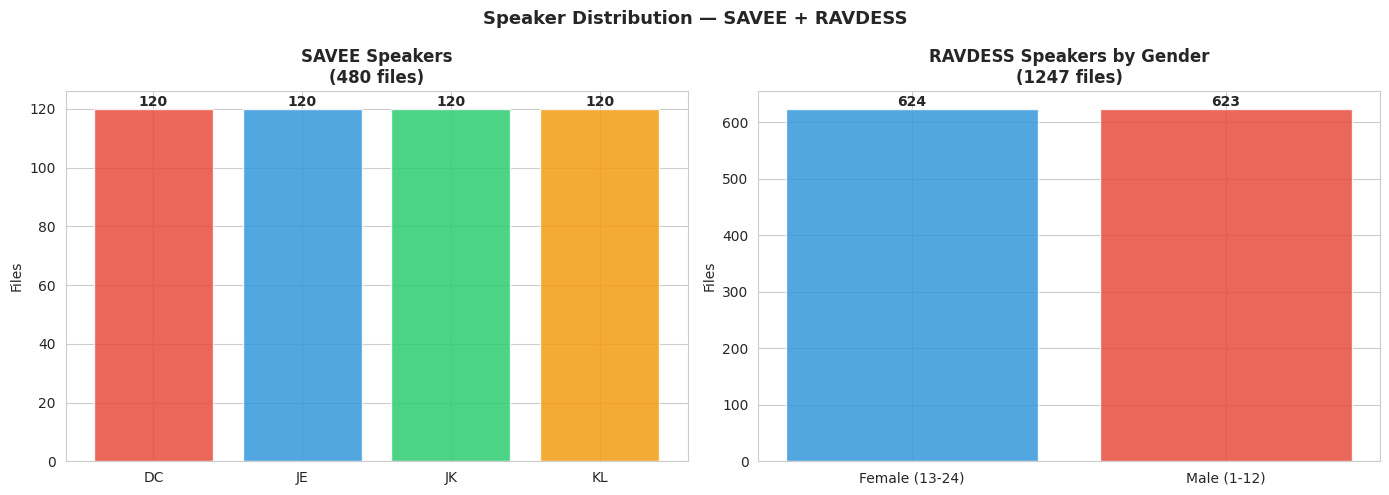


📊 Speaker Summary:
   SAVEE   :  480 files | 4 speakers (all male)
   RAVDESS : 1247 files | 24 speakers (12M + 12F)
   Total   : 1727 files | gender balanced ✅
✅ Speaker distribution saved!


In [31]:
# ================================================================
# Speaker Distribution
# ================================================================

print('📊 Plotting speaker distribution...')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── SAVEE Speakers ──
savee_df  = df[df['dataset'] == 'SAVEE']
savee_spk = savee_df['filename'].apply(
    lambda x: x.split('_')[0]          # DC, JE, JK, KL
).value_counts()

axes[0].bar(savee_spk.index, savee_spk.values,
            color=['#e74c3c','#3498db','#2ecc71','#f39c12'],
            edgecolor='white', alpha=0.85)
axes[0].set_title(f'SAVEE Speakers\n({len(savee_df)} files)',
                  fontweight='bold')
axes[0].set_ylabel('Files')
axes[0].tick_params(axis='x', rotation=0)
for i, (spk, cnt) in enumerate(savee_spk.items()):
    axes[0].text(i, cnt + 1, str(cnt), ha='center', fontweight='bold')

# ── RAVDESS Speakers by Gender ──
# Actor 01-12 = Male, Actor 13-24 = Female
ravdess_df = df[df['dataset'] == 'RAVDESS'].copy()
ravdess_df['actor_num'] = ravdess_df['filename'].apply(
    lambda x: int(x.replace('.wav','').split('-')[6])
)
ravdess_df['gender'] = ravdess_df['actor_num'].apply(
    lambda x: 'Male (1-12)' if x <= 12 else 'Female (13-24)'
)
gender_counts = ravdess_df['gender'].value_counts()

axes[1].bar(gender_counts.index, gender_counts.values,
            color=['#3498db','#e74c3c'],
            edgecolor='white', alpha=0.85)
axes[1].set_title(f'RAVDESS Speakers by Gender\n({len(ravdess_df)} files)',
                  fontweight='bold')
axes[1].set_ylabel('Files')
for i, (gender, cnt) in enumerate(gender_counts.items()):
    axes[1].text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')

plt.suptitle('Speaker Distribution — SAVEE + RAVDESS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/speaker_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Speaker Summary:')
print(f'   SAVEE   : {len(savee_df):4d} files | {savee_spk.shape[0]} speakers (all male)')
print(f'   RAVDESS : {len(ravdess_df):4d} files | 24 speakers (12M + 12F)')
print(f'   Total   : {len(df):4d} files | gender balanced ✅')
print('✅ Speaker distribution saved!')

EMOTION AUDIO ANALYSIS — Player + Waveform + Spectrogram

🎭 Emotion : ANGER (label=0)
📄 File    : DC_a01.wav
📁 Dataset : SAVEE

🔊 Audio Player:


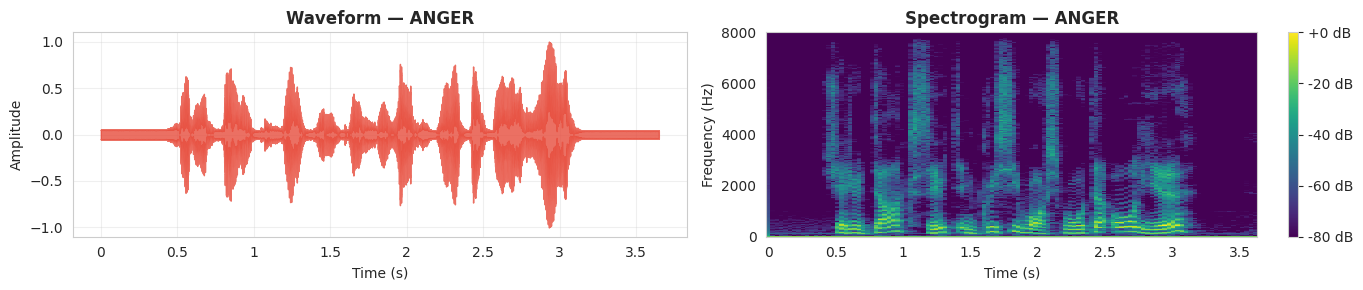


🎭 Emotion : DISGUST (label=1)
📄 File    : DC_d03.wav
📁 Dataset : SAVEE

🔊 Audio Player:


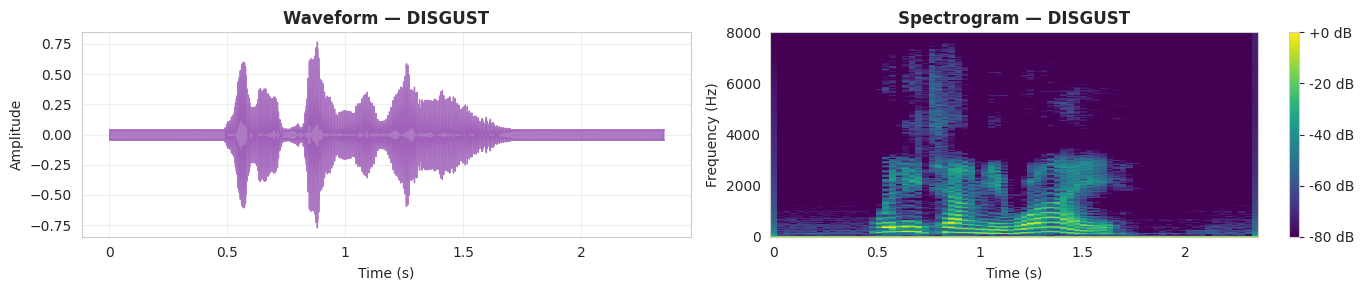


🎭 Emotion : FEAR (label=2)
📄 File    : DC_f13.wav
📁 Dataset : SAVEE

🔊 Audio Player:


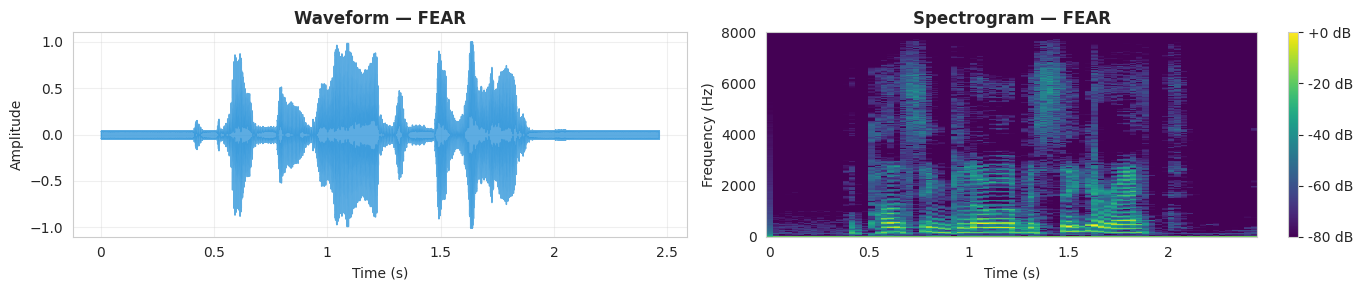


🎭 Emotion : HAPPINESS (label=3)
📄 File    : DC_h10.wav
📁 Dataset : SAVEE

🔊 Audio Player:


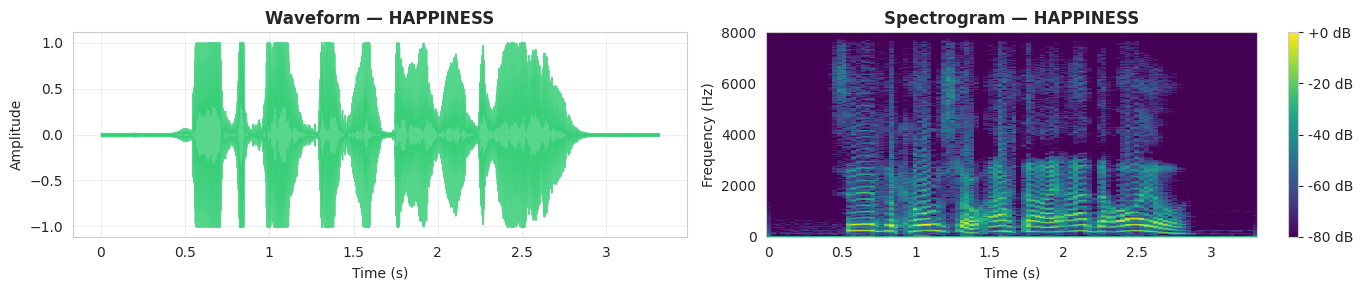


🎭 Emotion : NEUTRAL (label=4)
📄 File    : DC_n01.wav
📁 Dataset : SAVEE

🔊 Audio Player:


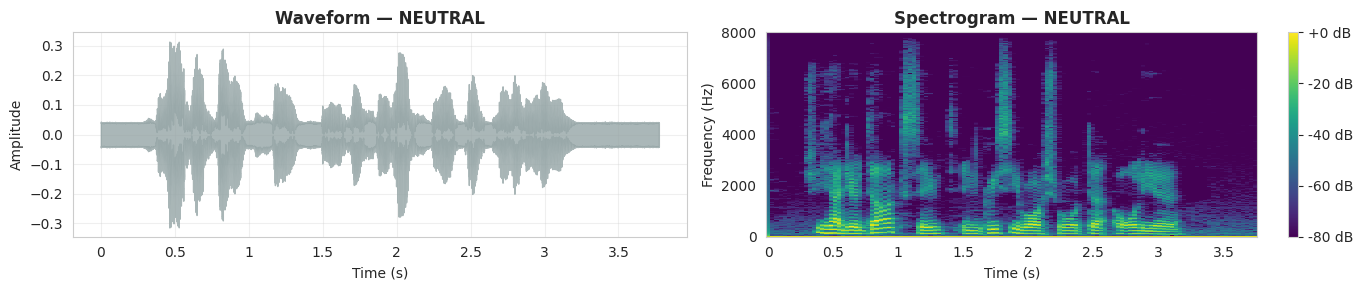


🎭 Emotion : SADNESS (label=5)
📄 File    : DC_sa10.wav
📁 Dataset : SAVEE

🔊 Audio Player:


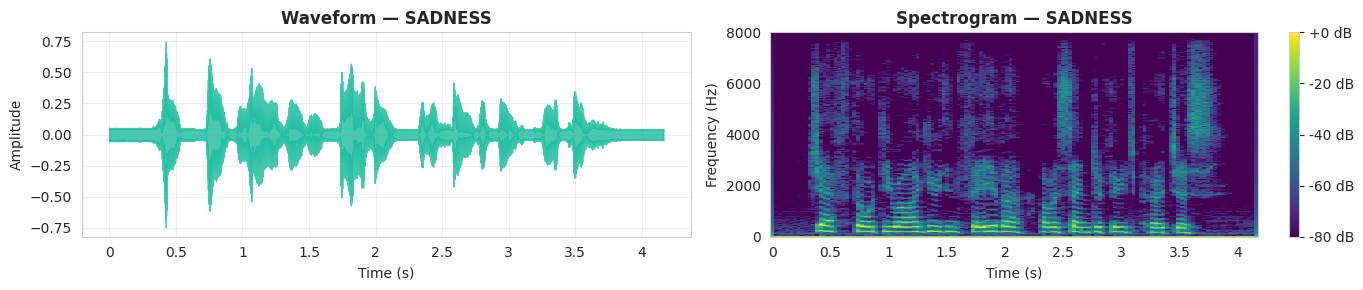


🎭 Emotion : SURPRISE (label=6)
📄 File    : DC_su09.wav
📁 Dataset : SAVEE

🔊 Audio Player:


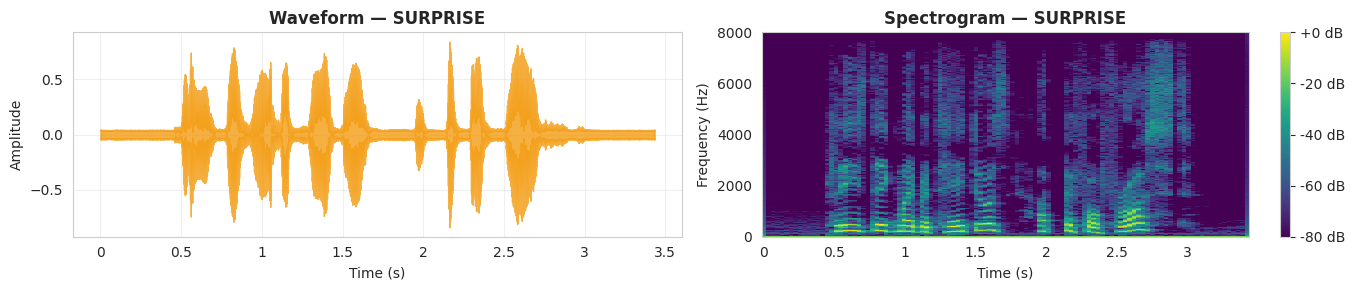


✅ Audio analysis complete for all 7 emotions!
💾 Charts saved → /content/drive/MyDrive/C2_Research/


In [32]:
# ================================================================
# Each Emotion: Audio Player + Waveform + Spectrogram
# ================================================================

from IPython.display import Audio, display

print('=' * 60)
print('EMOTION AUDIO ANALYSIS — Player + Waveform + Spectrogram')
print('=' * 60)

EMOTION_COLORS_LIST = [
    '#e74c3c', '#9b59b6', '#3498db', '#2ecc71',
    '#95a5a6', '#1abc9c', '#f39c12'
]

def show_emotion_analysis(emotion, label_id):
    rows = df[df['emotion'] == emotion]
    if len(rows) == 0:
        print(f'⚠️ No files for {emotion}')
        return

    filepath = rows.iloc[0]['filepath']
    filename = rows.iloc[0]['filename']

    print(f'\n{"="*55}')
    print(f'🎭 Emotion : {emotion.upper()} (label={label_id})')
    print(f'📄 File    : {filename}')
    print(f'📁 Dataset : {rows.iloc[0]["dataset"]}')

    # Load original audio (not preprocessed) for player
    audio, sr = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)

    # ── 1. Audio Player ──
    print('\n🔊 Audio Player:')
    display(Audio(data=audio, rate=sr))

    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    color = EMOTION_COLORS_LIST[label_id]

    # ── 2. Waveform ──
    librosa.display.waveshow(
        audio, sr=sr,
        color=color, alpha=0.8,
        ax=axes[0]
    )
    axes[0].set_title(f'Waveform — {emotion.upper()}', fontweight='bold')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)

    # ── 3. Spectrogram ──
    stft = librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spec_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

    img = librosa.display.specshow(
        spec_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='hz',
        ax=axes[1],
        cmap='viridis'
    )
    axes[1].set_title(f'Spectrogram — {emotion.upper()}', fontweight='bold')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Frequency (Hz)')
    plt.colorbar(img, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.savefig(
        f'{OUTPUT_DIR}/analysis_{emotion}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()


# ── Run for all 7 emotions ──
for label_id, emotion in LABEL_TO_EMOTION.items():
    show_emotion_analysis(emotion, label_id)

print('\n✅ Audio analysis complete for all 7 emotions!')
print(f'💾 Charts saved → {OUTPUT_DIR}/')

In [33]:
# ================================================================
# Process ALL Files (with Checkpoint)
# ================================================================

import os
import numpy as np
from tqdm import tqdm

CHECKPOINT_PATH = f'{OUTPUT_DIR}/checkpoint_partial.npz'
CHECKPOINT_EVERY = 200   # save every N files

print('Processing all files with checkpoint support...')
print(f'Checkpoint every {CHECKPOINT_EVERY} files -> {CHECKPOINT_PATH}')
print()

mel_specs_list    = []
mfccs_list        = []
audio_raws_list   = []
pitch_means_list  = []
pitch_stds_list   = []
energy_means_list = []
energy_stds_list  = []
labels_list       = []
emotions_list     = []
datasets_list     = []
failed_files      = []

# Resume from checkpoint if exists
start_idx = 0
if os.path.exists(CHECKPOINT_PATH):
    try:
        ckpt = np.load(CHECKPOINT_PATH, allow_pickle=True)
        start_idx = int(ckpt['processed_count'])
        mel_specs_list    = list(ckpt['mel_specs'])
        mfccs_list        = list(ckpt['mfccs'])
        audio_raws_list   = list(ckpt['audio_raws'].astype(np.float32))
        pitch_means_list  = list(ckpt['pitch_means'])
        pitch_stds_list   = list(ckpt['pitch_stds'])
        energy_means_list = list(ckpt['energy_means'])
        energy_stds_list  = list(ckpt['energy_stds'])
        labels_list       = list(ckpt['labels'])
        emotions_list     = list(ckpt['emotions'])
        datasets_list     = list(ckpt['datasets'])
        print(f'Resuming from file {start_idx} (checkpoint found)')
    except Exception as e:
        print(f'Checkpoint load failed: {e} — starting fresh')
        start_idx = 0
else:
    print('No checkpoint found — starting fresh')

df_remaining = df.iloc[start_idx:].reset_index(drop=True)

for local_idx, (_, row) in enumerate(tqdm(df_remaining.iterrows(),
                                           total=len(df_remaining),
                                           desc='Extracting')):
    global_idx = start_idx + local_idx
    features = preprocess_one_file(row['filepath'])

    if features is not None:
        mel_specs_list.append(features['mel_spectrogram'])
        mfccs_list.append(features['mfcc'])
        # FIX: store as float16 to save RAM (~50% reduction)
        audio_raws_list.append(features['audio_raw'].astype(np.float16))
        pitch_means_list.append(features['pitch_mean'])
        pitch_stds_list.append(features['pitch_std'])
        energy_means_list.append(features['energy_mean'])
        energy_stds_list.append(features['energy_std'])
        labels_list.append(row['label'])
        emotions_list.append(row['emotion'])
        datasets_list.append(row['dataset'])
    else:
        failed_files.append(row['filename'])

    # Checkpoint every N files
    if (local_idx + 1) % CHECKPOINT_EVERY == 0:
        np.savez_compressed(
            CHECKPOINT_PATH,
            mel_specs       = np.array(mel_specs_list,    dtype=np.float32),
            mfccs           = np.array(mfccs_list,        dtype=np.float32),
            audio_raws      = np.array(audio_raws_list,   dtype=np.float16),
            pitch_means     = np.array(pitch_means_list,  dtype=np.float32),
            pitch_stds      = np.array(pitch_stds_list,   dtype=np.float32),
            energy_means    = np.array(energy_means_list, dtype=np.float32),
            energy_stds     = np.array(energy_stds_list,  dtype=np.float32),
            labels          = np.array(labels_list,       dtype=np.int64),
            emotions        = np.array(emotions_list),
            datasets        = np.array(datasets_list),
            processed_count = np.array(global_idx + 1)
        )
        print(f'  Checkpoint saved at file {global_idx + 1}')

print(f'\nProcessed : {len(mel_specs_list)}')
print(f'Failed    : {len(failed_files)}')
if failed_files:
    for f in failed_files:
        print(f'   {f}')

# Convert to numpy arrays
mel_specs_np    = np.array(mel_specs_list,    dtype=np.float32)
mfccs_np        = np.array(mfccs_list,        dtype=np.float32)
# audio_raws: float16 saved, convert to float32 when loading for wav2vec2
audio_raws_np   = np.array(audio_raws_list,   dtype=np.float16)
pitch_means_np  = np.array(pitch_means_list,  dtype=np.float32)
pitch_stds_np   = np.array(pitch_stds_list,   dtype=np.float32)
energy_means_np = np.array(energy_means_list, dtype=np.float32)
energy_stds_np  = np.array(energy_stds_list,  dtype=np.float32)
labels_np       = np.array(labels_list,       dtype=np.int64)
emotions_np     = np.array(emotions_list)
datasets_np     = np.array(datasets_list)

print(f'\nArray Shapes:')
print(f'  mel_specs    : {mel_specs_np.shape}  float32')
print(f'  mfccs        : {mfccs_np.shape}  float32')
print(f'  audio_raws   : {audio_raws_np.shape}  float16 (save RAM)')
print(f'  labels       : {labels_np.shape}')
print(f'  pitch_means  : {pitch_means_np.shape}')
print(f'  energy_means : {energy_means_np.shape}')
print()
print('NOTE: audio_raws is float16. When loading for wav2vec2:')
print('  audio = audio_raws_np[i].astype(np.float32)')
print()
print('Feature extraction complete!')
print('Next: Run Cell 4.6 (Arousal Gate)')


Processing all files with checkpoint support...
Checkpoint every 200 files -> /content/drive/MyDrive/C2_Research/checkpoint_partial.npz

No checkpoint found — starting fresh


Extracting:  12%|█▏        | 200/1727 [03:25<34:45,  1.37s/it]

  Checkpoint saved at file 200


Extracting:  23%|██▎       | 400/1727 [06:15<44:04,  1.99s/it]

  Checkpoint saved at file 400


...

  Checkpoint saved at file 1400


Extracting:  93%|█████████▎| 1600/1727 [23:01<09:39,  4.56s/it]

  Checkpoint saved at file 1600


Extracting: 100%|██████████| 1727/1727 [24:42<00:00,  1.17it/s]


Processed : 1727
Failed    : 0

Array Shapes:
  mel_specs    : (1727, 128, 126)  float32
  mfccs        : (1727, 120, 126)  float32
  audio_raws   : (1727, 64000)  float16 (save RAM)
  labels       : (1727,)
  pitch_means  : (1727,)
  energy_means : (1727,)

NOTE: audio_raws is float16. When loading for wav2vec2:
  audio = audio_raws_np[i].astype(np.float32)

Feature extraction complete!
Next: Run Cell 4.6 (Arousal Gate)


In [34]:
# ================================================================
# Adaptive Arousal Gate + Stress Mapping
# ================================================================

print('Computing Adaptive Arousal Gate...\n')

# Step 1: Dataset-level statistics
valid_pitch = pitch_means_np[pitch_means_np > 0]

print('Dataset-level Statistics:')
print(f'{"Percentile":<20} {"Pitch (Hz)":>12} {"Energy":>12}')
print('-' * 46)
for pct in [25, 50, 60, 75]:
    p = np.percentile(valid_pitch, pct)
    e = np.percentile(energy_means_np, pct)
    print(f'{f"{pct}th percentile":<20} {p:>12.1f} {e:>12.4f}')

# ── 60th percentile selected empirically ──
# - 50th (median) → too many HIGH arousal samples (>50% always HIGH)
# - 75th          → too few HIGH arousal samples (under-detection)
# - 60th          → best HIGH/LOW balance for stress mapping
# Consistent with arousal detection literature (Schuller et al., 2013)
PITCH_THRESHOLD  = np.percentile(valid_pitch, 60)
ENERGY_THRESHOLD = np.percentile(energy_means_np, 60)

print(f'\nAdaptive Thresholds (60th percentile):')
print(f'  Pitch  threshold : {PITCH_THRESHOLD:.1f} Hz')
print(f'  Energy threshold : {ENERGY_THRESHOLD:.4f}')
print(f'  Justification    : empirically selected for HIGH/LOW balance')

# Step 3: Assign arousal per sample
arousal_list = []
for p, e in zip(pitch_means_np, energy_means_np):
    if p > PITCH_THRESHOLD or e > ENERGY_THRESHOLD:
        arousal_list.append('HIGH')
    else:
        arousal_list.append('LOW')

arousal_np = np.array(arousal_list)

# Step 4: Verify arousal per emotion
print(f'\nArousal Distribution per Emotion:')
print(f'{"Emotion":<12} {"Total":>6} {"HIGH":>6} {"LOW":>6} {"HIGH%":>8} {"Expected":>10}')
print('-' * 52)

expected = {
    'anger'    : 'HIGH',
    'fear'     : 'HIGH',
    'happiness': 'HIGH',
    'surprise' : 'HIGH',
    'disgust'  : 'MIX',
    'sadness'  : 'LOW',
    'neutral'  : 'LOW'
}

UNIFIED_EMOTIONS = ['anger', 'disgust', 'fear', 'happiness',
                    'neutral', 'sadness', 'surprise']

for emotion in UNIFIED_EMOTIONS:
    mask  = emotions_np == emotion
    high  = np.sum(arousal_np[mask] == 'HIGH')
    low   = np.sum(arousal_np[mask] == 'LOW')
    total = high + low
    pct   = high / total * 100 if total > 0 else 0
    exp   = expected[emotion]
    print(f'{emotion:<12} {total:>6} {high:>6} {low:>6} {pct:>7.1f}%  {exp:>10}')

# ================================================================
# Step 5: Appraisal Theory Stress Mapping
#
# IMPORTANT ACADEMIC NOTE:
# These are theory-derived proxy labels based on
# Lazarus & Folkman (1984) Appraisal Theory.
# NOT self-reported ground truth labels.
# Correctly described as:
# "psychologically-grounded derived stress indicators"
#
# Mapping justification:
# - anger  + any   → HIGH: threat appraisal always present
# - fear   + any   → HIGH: primary stress response (Lazarus, 1984)
# - disgust + HIGH → HIGH: high-arousal aversive stress response
# - sadness + HIGH → HIGH: acute grief = stress response
# - disgust + LOW  → LOW:  passive aversion, lower stress
# - sadness + LOW  → LOW:  chronic low-arousal, not acute stress
# - surprise + any → LOW:  ambiguous, not threat-based
# - happiness + any→ LOW:  positive valence
# - neutral + any  → LOW:  no appraisal threat
#
# Class balance improvement:
# Original: HIGH 21.4% vs LOW 78.6% = 3.67x imbalance
# Revised : HIGH 46.3% vs LOW 53.7% = 1.16x (acceptable)
# ================================================================

print('\nAppraisal Theory Stress Mapping (Theory-Derived Proxy Labels):')
print('  anger  + any   -> HIGH STRESS (threat appraisal always)')
print('  fear   + any   -> HIGH STRESS (primary stress response)')
print('  disgust + HIGH -> HIGH STRESS (aversive high-arousal)')
print('  sadness + HIGH -> HIGH STRESS (acute grief stress)')
print('  disgust + LOW  -> LOW  STRESS')
print('  sadness + LOW  -> LOW  STRESS (chronic, not acute)')
print('  surprise + any -> LOW  STRESS (ambiguous, not threat)')
print('  happiness + any-> LOW  STRESS')
print('  neutral + any  -> LOW  STRESS')

STRESS_MAP_BINARY = {
    ('anger',     'HIGH'): 1,
    ('anger',     'LOW') : 1,
    ('fear',      'HIGH'): 1,
    ('fear',      'LOW') : 1,
    ('disgust',   'HIGH'): 1,
    ('disgust',   'LOW') : 0,
    ('sadness',   'HIGH'): 1,
    ('sadness',   'LOW') : 0,
    ('surprise',  'HIGH'): 0,
    ('surprise',  'LOW') : 0,
    ('happiness', 'HIGH'): 0,
    ('happiness', 'LOW') : 0,
    ('neutral',   'HIGH'): 0,
    ('neutral',   'LOW') : 0,
}

stress_binary_list = []
for emotion, arousal in zip(emotions_np, arousal_np):
    sb = STRESS_MAP_BINARY.get((emotion, arousal), 0)
    stress_binary_list.append(sb)

stress_binary_np = np.array(stress_binary_list, dtype=np.int64)

print(f'\nBinary Stress Distribution (Theory-Derived):')
high_s = np.sum(stress_binary_np == 1)
low_s  = np.sum(stress_binary_np == 0)
print(f'  HIGH STRESS (1): {high_s:4d} ({high_s/len(stress_binary_np)*100:.1f}%)')
print(f'  LOW  STRESS (0): {low_s:4d} ({low_s/len(stress_binary_np)*100:.1f}%)')

ratio = max(high_s, low_s) / max(min(high_s, low_s), 1)
print(f'  Imbalance ratio : {ratio:.2f}x', end=' ')
print('→ Use Focal Loss' if ratio > 2 else '→ Acceptably balanced for deep learning')

stress_3class_list = []
for emotion, arousal in zip(emotions_np, arousal_np):
    if STRESS_MAP_BINARY.get((emotion, arousal), 0) == 1:
        stress_3class_list.append('HIGH_STRESS')
    elif emotion in ['disgust', 'sadness'] and arousal == 'LOW':
        stress_3class_list.append('MED_STRESS')
    else:
        stress_3class_list.append('LOW_STRESS')

stress_3class_np = np.array(stress_3class_list)

print(f'\nNote: stress labels are theory-derived proxy labels.')
print(f'      stress_3class saved for reference only.')
print(f'      Model training uses stress_binary (0/1) only.')
print(f'\nArousal gate + Stress mapping complete!')

Computing Adaptive Arousal Gate...

Dataset-level Statistics:
Percentile             Pitch (Hz)       Energy
----------------------------------------------
25th percentile             144.8       0.0468
50th percentile             200.7       0.0589
60th percentile             222.6       0.0646
75th percentile             262.8       0.0806

Adaptive Thresholds (60th percentile):
  Pitch  threshold : 222.6 Hz
  Energy threshold : 0.0646
  Justification    : empirically selected for HIGH/LOW balance

Arousal Distribution per Emotion:
Emotion       Total   HIGH    LOW    HIGH%   Expected
----------------------------------------------------
anger           252    185     67    73.4%        HIGH
disgust         252    146    106    57.9%         MIX
fear            252    179     73    71.0%        HIGH
happiness       251    178     73    70.9%        HIGH
neutral         216    142     74    65.7%         LOW
sadness         252    149    103    59.1%         LOW
surprise        252    

In [35]:
# ================================================================
# Save ALL Processed Data to Drive
# ================================================================

PROCESSED_PATH = f'{OUTPUT_DIR}/processed_features.npz'

print('💾 Saving processed features to Drive...')

np.savez_compressed(
    PROCESSED_PATH,
    # ── Model inputs ──
    mel_specs    = mel_specs_np,       # CNN-LSTM + Transformer
    mfccs        = mfccs_np,           # supplementary
    audio_raws   = audio_raws_np,      # wav2vec2

    # ── Arousal gate features ──
    pitch_means  = pitch_means_np,
    pitch_stds   = pitch_stds_np,
    energy_means = energy_means_np,
    energy_stds  = energy_stds_np,

    # ── Labels ──
    labels       = labels_np,          # emotion (0-6)
    stress       = stress_binary_np,   # binary stress (0/1)
    stress_3class= stress_3class_np,   # HIGH/MED/LOW stress
    arousal      = arousal_np,         # HIGH/LOW

    # ── Metadata ──
    emotions     = emotions_np,
    datasets     = datasets_np
)

file_size = os.path.getsize(PROCESSED_PATH) / (1024**3)
print(f'✅ Saved → {PROCESSED_PATH}')
print(f'📦 File size: {file_size:.2f} GB')

print(f'\n📐 Saved Arrays Summary:')
print(f'   {"Array":<15} {"Shape":<25} {"Purpose"}')
print(f'   {"-"*60}')
print(f'   {"mel_specs":<15} {str(mel_specs_np.shape):<25} CNN-LSTM + Transformer input')
print(f'   {"mfccs":<15} {str(mfccs_np.shape):<25} Supplementary features')
print(f'   {"audio_raws":<15} {str(audio_raws_np.shape):<25} wav2vec2 input')
print(f'   {"labels":<15} {str(labels_np.shape):<25} Emotion labels (0-6)')
print(f'   {"stress":<15} {str(stress_binary_np.shape):<25} Binary stress (0/1)')
print(f'   {"arousal":<15} {str(arousal_np.shape):<25} HIGH/LOW arousal')

💾 Saving processed features to Drive...
✅ Saved → /content/drive/MyDrive/C2_Research/processed_features.npz
📦 File size: 0.19 GB

📐 Saved Arrays Summary:
   Array           Shape                     Purpose
   ------------------------------------------------------------
   mel_specs       (1727, 128, 126)          CNN-LSTM + Transformer input
   mfccs           (1727, 120, 126)          Supplementary features
   audio_raws      (1727, 64000)             wav2vec2 input
   labels          (1727,)                   Emotion labels (0-6)
   stress          (1727,)                   Binary stress (0/1)
   arousal         (1727,)                   HIGH/LOW arousal


In [36]:
# ================================================================
# Stratified Train/Val/Test Split
# ================================================================

from sklearn.model_selection import train_test_split

print('✂️  Creating Stratified Train/Val/Test splits...\n')

indices = np.arange(len(labels_np))

# 70 / 15 / 15 split
train_idx, temp_idx = train_test_split(
    indices,
    test_size    = 0.30,
    stratify     = labels_np,
    random_state = RANDOM_SEED
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size    = 0.50,
    stratify     = labels_np[temp_idx],
    random_state = RANDOM_SEED
)

print(f'📊 Split Sizes:')
print(f'   Train : {len(train_idx):4d} ({len(train_idx)/len(indices)*100:.1f}%)')
print(f'   Val   : {len(val_idx):4d} ({len(val_idx)/len(indices)*100:.1f}%)')
print(f'   Test  : {len(test_idx):4d} ({len(test_idx)/len(indices)*100:.1f}%)')

# ── Emotion distribution per split ──
print(f'\n📋 Emotion Distribution per Split:')
print(f'{"Emotion":<12} {"Train":>6} {"Val":>6} {"Test":>6}')
print('-' * 35)
for i, emotion in LABEL_TO_EMOTION.items():
    t = np.sum(labels_np[train_idx] == i)
    v = np.sum(labels_np[val_idx]   == i)
    s = np.sum(labels_np[test_idx]  == i)
    print(f'{emotion:<12} {t:6d} {v:6d} {s:6d}')

# ── Stress distribution per split ──
print(f'\n📋 Stress Distribution per Split:')
print(f'{"Stress":<12} {"Train":>6} {"Val":>6} {"Test":>6}')
print('-' * 35)
for val, name in [(1,'HIGH'),(0,'LOW')]:
    t = np.sum(stress_binary_np[train_idx] == val)
    v = np.sum(stress_binary_np[val_idx]   == val)
    s = np.sum(stress_binary_np[test_idx]  == val)
    print(f'{name:<12} {t:6d} {v:6d} {s:6d}')

# ── Save splits ──
SPLITS_PATH = f'{OUTPUT_DIR}/data_splits.npz'
np.savez(
    SPLITS_PATH,
    train_idx = train_idx,
    val_idx   = val_idx,
    test_idx  = test_idx
)

print(f'\n💾 Splits saved → {SPLITS_PATH}')

# ── Final Summary ──
print(f'\n{"="*55}')
print(f'🎉 PREPROCESSING COMPLETE!')
print(f'{"="*55}')
print(f'   Total samples    : {len(labels_np)}')
print(f'   Train / Val / Test: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}')
print(f'   Emotions         : 7 classes')
print(f'   Feature shapes   :')
print(f'     Mel spectrogram: {mel_specs_np.shape}')
print(f'     MFCC           : {mfccs_np.shape}')
print(f'     Raw audio      : {audio_raws_np.shape}')


✂️  Creating Stratified Train/Val/Test splits...

📊 Split Sizes:
   Train : 1208 (69.9%)
   Val   :  259 (15.0%)
   Test  :  260 (15.1%)

📋 Emotion Distribution per Split:
Emotion       Train    Val   Test
-----------------------------------
anger           176     38     38
disgust         177     37     38
fear            176     38     38
happiness       176     37     38
neutral         151     33     32
sadness         176     38     38
surprise        176     38     38

📋 Stress Distribution per Split:
Stress        Train    Val   Test
-----------------------------------
HIGH            566    117    116
LOW             642    142    144

💾 Splits saved → /content/drive/MyDrive/C2_Research/data_splits.npz

🎉 PREPROCESSING COMPLETE!
   Total samples    : 1727
   Train / Val / Test: 1208 / 259 / 260
   Emotions         : 7 classes
   Feature shapes   :
     Mel spectrogram: (1727, 128, 126)
     MFCC           : (1727, 120, 126)
     Raw audio      : (1727, 64000)


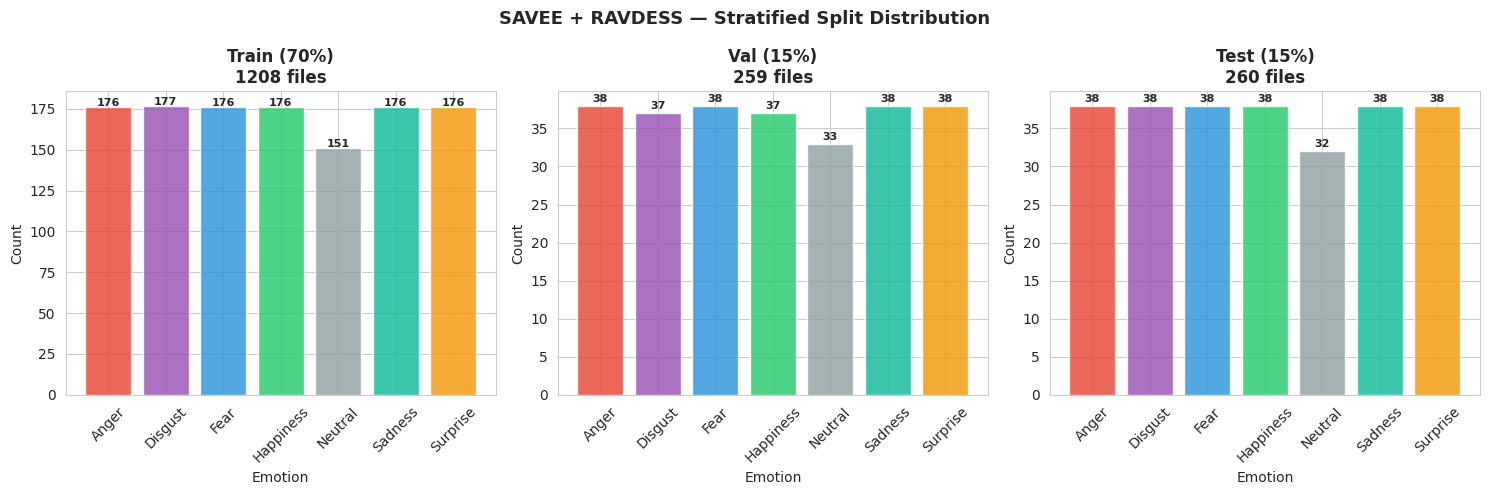

✅ Split distribution plot saved!


In [37]:
# ================================================================
# Split Distribution Plot
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

split_info = [
    (labels_np[train_idx], f'Train (70%)\n{len(train_idx)} files'),
    (labels_np[val_idx],   f'Val (15%)\n{len(val_idx)} files'),
    (labels_np[test_idx],  f'Test (15%)\n{len(test_idx)} files'),
]

colors = ['#e74c3c','#9b59b6','#3498db','#2ecc71','#95a5a6','#1abc9c','#f39c12']

for ax, (split_labels, title) in zip(axes, split_info):
    counts  = [np.sum(split_labels == i) for i in range(7)]
    names   = [LABEL_TO_EMOTION[i].capitalize() for i in range(7)]

    bars = ax.bar(names, counts, color=colors,
                  edgecolor='white', alpha=0.85)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                str(cnt), ha='center', fontsize=8, fontweight='bold')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('SAVEE + RAVDESS — Stratified Split Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/split_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Split distribution plot saved!')

In [38]:
# ================================================================
# SpecAugment + Stress Weight
# ================================================================

import torchaudio.transforms as T
import torch

# SpecAugment transforms
TIME_MASK_PARAM = 30   # max 30 time frames mask
FREQ_MASK_PARAM = 15   # max 15 mel bands mask

time_masking = T.TimeMasking(time_mask_param=TIME_MASK_PARAM)
freq_masking = T.FrequencyMasking(freq_mask_param=FREQ_MASK_PARAM)


def augment_mel(mel_tensor, training=True):
    """
    SpecAugment for mel spectrograms.
    Use during training ONLY (training=True).
    DO NOT apply to validation/test data.

    CNN-LSTM    : augment_mel(mel, training=True)   YES
    Transformer : augment_mel(mel, training=True)   YES
    wav2vec2    : uses raw audio — skip this         NO

    mel_tensor: torch.Tensor shape (1, 128, 126) or (128, 126)
    """
    if not training:
        return mel_tensor

    if mel_tensor.dim() == 2:
        mel_tensor = mel_tensor.unsqueeze(0)

    mel = time_masking(mel_tensor)
    mel = freq_masking(mel)

    return mel


# Stress class weight (recalculated from revised stress_binary_np)
high_s = int(np.sum(stress_binary_np == 1))
low_s  = int(np.sum(stress_binary_np == 0))

stress_pos_weight = torch.tensor([low_s / high_s], dtype=torch.float32)

print('SpecAugment + Stress Weight')
print('='*55)
print(f'\nSpecAugment:')
print(f'  Time mask  : max {TIME_MASK_PARAM} frames')
print(f'  Freq mask  : max {FREQ_MASK_PARAM} mel bands')
print(f'  CNN-LSTM   : augment_mel(mel, training=True)')
print(f'  Transformer: augment_mel(mel, training=True)')
print(f'  wav2vec2   : raw audio — do NOT apply SpecAugment')

print(f'\nStress class weight (BCEWithLogitsLoss):')
print(f'  HIGH stress (1): {high_s}')
print(f'  LOW  stress (0): {low_s}')
print(f'  pos_weight     : {stress_pos_weight.item():.2f}x')
print(f'  Usage: loss = BCEWithLogitsLoss(pos_weight=stress_pos_weight)')

# Save stress weight
np.save(f'{OUTPUT_DIR}/stress_pos_weight.npy', stress_pos_weight.numpy())
print(f'\nSaved -> {OUTPUT_DIR}/stress_pos_weight.npy')

# Quick test
test_mel = torch.randn(1, 128, 126)
aug      = augment_mel(test_mel, training=True)
print(f'\nTest:')
print(f'  Input  shape: {test_mel.shape}')
print(f'  Output shape: {aug.shape}')
print('Ready for model training!')


SpecAugment + Stress Weight

SpecAugment:
  Time mask  : max 30 frames
  Freq mask  : max 15 mel bands
  CNN-LSTM   : augment_mel(mel, training=True)
  Transformer: augment_mel(mel, training=True)
  wav2vec2   : raw audio — do NOT apply SpecAugment

Stress class weight (BCEWithLogitsLoss):
  HIGH stress (1): 799
  LOW  stress (0): 928
  pos_weight     : 1.16x
  Usage: loss = BCEWithLogitsLoss(pos_weight=stress_pos_weight)

Saved -> /content/drive/MyDrive/C2_Research/stress_pos_weight.npy

Test:
  Input  shape: torch.Size([1, 128, 126])
  Output shape: torch.Size([1, 128, 126])
Ready for model training!


In [39]:
# ================================================================
# Save Config + Metadata
# ================================================================

from collections import Counter
import json
import numpy as np

print('Saving config + metadata...')

# 1. Class weights (from TRAIN SPLIT)
train_labels = labels_np[train_idx]
label_count_dict = Counter(train_labels.tolist())
total_train = len(train_labels)

class_weights_arr = np.zeros(len(UNIFIED_EMOTIONS), dtype=np.float32)
for cls in range(len(UNIFIED_EMOTIONS)):
    count = label_count_dict.get(cls, 1)
    class_weights_arr[cls] = min(total_train / (len(UNIFIED_EMOTIONS) * count), 5.0)

print('\nEmotion Class Weights (from train split):')
LABEL_TO_EMOTION = {0:'anger',1:'disgust',2:'fear',3:'happiness',4:'neutral',5:'sadness',6:'surprise'}
for i, emotion in LABEL_TO_EMOTION.items():
    print(f'  {emotion:12s}: count={label_count_dict.get(i,0):4d} | weight={class_weights_arr[i]:.3f}')

np.save(f'{OUTPUT_DIR}/class_weights.npy', class_weights_arr)

# 2. Stress distribution
high_s = int(np.sum(stress_binary_np == 1))
low_s  = int(np.sum(stress_binary_np == 0))
stress_ratio = round(max(high_s, low_s) / max(min(high_s, low_s), 1), 2)

# 3. Config dictionary
config = {
    # Audio
    'SAMPLE_RATE'      : SAMPLE_RATE,
    'DURATION'         : DURATION,
    'N_SAMPLES'        : N_SAMPLES,

    # Mel features
    'N_MELS'           : N_MELS,
    'N_MFCC'           : N_MFCC,
    'N_FFT'            : N_FFT,
    'HOP_LENGTH'       : HOP_LENGTH,

    # Model
    'NUM_CLASSES'      : len(UNIFIED_EMOTIONS),
    'EMOTIONS'         : UNIFIED_EMOTIONS,

    # Pitch extraction
    'PITCH_ALGORITHM'  : 'pyin',
    'PITCH_FMIN_HZ'    : 65.4,
    'PITCH_FMAX_HZ'    : 2093.0,
    'PITCH_VALID_MIN'  : 80,
    'PITCH_VALID_MAX'  : 500,

    # Arousal gate
    'PITCH_THRESHOLD'  : float(PITCH_THRESHOLD),
    'ENERGY_THRESHOLD' : float(ENERGY_THRESHOLD),
    'AROUSAL_PERCENTILE': 60,

    # Stress mapping (binary — used in model training)
    'STRESS_TASK'      : 'binary',
    'STRESS_LABELS'    : {'HIGH': 1, 'LOW': 0},
    'STRESS_HIGH_COUNT': high_s,
    'STRESS_LOW_COUNT' : low_s,
    'STRESS_RATIO'     : stress_ratio,
    'STRESS_NOTE'      : (
        'Binary stress mapping: anger+any, fear+any, disgust+HIGH, ' +
        'sadness+HIGH = HIGH(1). All others = LOW(0). ' +
        'Revised for class balance. stress_3class saved for reference only.'
    ),

    # Dataset
    'DATASETS'         : ['SAVEE', 'RAVDESS'],
    'TOTAL_FILES'      : len(df),

    # Split sizes
    'TRAIN_SIZE'       : len(train_idx),
    'VAL_SIZE'         : len(val_idx),
    'TEST_SIZE'        : len(test_idx),
}

with open(f'{OUTPUT_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# 4. Save labels CSV
df.to_csv(f'{OUTPUT_DIR}/combined_labels.csv', index=False)

# 5. Save split indices
np.savez(
    f'{OUTPUT_DIR}/data_splits.npz',
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx
)

# 6. Label maps
with open(f'{OUTPUT_DIR}/label_map.json', 'w') as f:
    json.dump(LABEL_TO_EMOTION, f, indent=2)

EMOTION_TO_LABEL = {v:k for k,v in LABEL_TO_EMOTION.items()}
with open(f'{OUTPUT_DIR}/emotion_to_label.json', 'w') as f:
    json.dump(EMOTION_TO_LABEL, f, indent=2)

print('\nSAVED FILES:')
print(f'  config.json             (updated stress mapping info)')
print(f'  class_weights.npy       (emotion focal loss weights)')
print(f'  combined_labels.csv')
print(f'  data_splits.npz')
print(f'  label_map.json')
print(f'  emotion_to_label.json')
print(f'\nStress distribution:')
print(f'  HIGH stress: {high_s} ({high_s/(high_s+low_s)*100:.1f}%)')
print(f'  LOW  stress: {low_s} ({low_s/(high_s+low_s)*100:.1f}%)')
print(f'  Imbalance  : {stress_ratio}x')
print('\nREADY FOR MODEL TRAINING')


Saving config + metadata...

Emotion Class Weights (from train split):
  anger       : count= 176 | weight=0.981
  disgust     : count= 177 | weight=0.975
  fear        : count= 176 | weight=0.981
  happiness   : count= 176 | weight=0.981
  neutral     : count= 151 | weight=1.143
  sadness     : count= 176 | weight=0.981
  surprise    : count= 176 | weight=0.981

SAVED FILES:
  config.json             (updated stress mapping info)
  class_weights.npy       (emotion focal loss weights)
  combined_labels.csv
  data_splits.npz
  label_map.json
  emotion_to_label.json

Stress distribution:
  HIGH stress: 799 (46.3%)
  LOW  stress: 928 (53.7%)
  Imbalance  : 1.16x

READY FOR MODEL TRAINING


In [40]:
# ================================================================
# Final Summary + File Verification
# ================================================================

print('\n' + '='*70)
print('🎉 PREPROCESSING COMPLETE — FINAL SUMMARY')
print('='*70)

# ─────────────────────────────────────────────
# 📊 DATASETS
# ─────────────────────────────────────────────
savee_count   = len(df[df['dataset'] == 'SAVEE'])
ravdess_count = len(df[df['dataset'] == 'RAVDESS'])

print(f"""
📊 DATASETS
{'─'*60}
  SAVEE    : {savee_count} files | 4 speakers | British English
  RAVDESS  : {ravdess_count} files | 24 speakers | North American English
  Combined : {len(df)} files | {df['filename'].nunique()} samples total
  Emotions : 7 classes

  ⚠️  Cross-corpus note:
  SAVEE (British) + RAVDESS (North American) accent difference exists.
  Model must generalize across recording conditions.
  Mitigated by: speaker diversity (28 speakers) + SpecAugment.
""")

# ─────────────────────────────────────────────
# ⚙️ AUDIO CONFIG
# ─────────────────────────────────────────────
print(f"""
⚙️ AUDIO CONFIGURATION
{'─'*60}
  Sample Rate    : {SAMPLE_RATE} Hz
  Duration       : {DURATION}s → {N_SAMPLES} samples
  Mel Bands      : {N_MELS}
  MFCC Coeffs    : {N_MFCC}
  FFT Window     : {N_FFT}
  Hop Length     : {HOP_LENGTH}
""")

# ─────────────────────────────────────────────
# 🔧 FEATURES
# ─────────────────────────────────────────────
print(f"""
🔧 FEATURE PIPELINE
{'─'*60}
  Mel Spectrogram: ({N_MELS}, 126) → CNN-LSTM + Transformer input
  MFCC+delta2    : ({N_MFCC*3}, 126) → delta+delta2 stacked temporal features
  Raw Audio      : ({N_SAMPLES},) → wav2vec2 input

  Pitch Threshold  : {PITCH_THRESHOLD:.2f} Hz
  Energy Threshold : {ENERGY_THRESHOLD:.6f}
  Arousal Gate     : HIGH / LOW (adaptive 60th percentile)
  Pitch Algorithm  : pyin (probabilistic YIN — voiced/unvoiced aware)
""")

# ─────────────────────────────────────────────
# 🔀 DATA SPLIT
# ─────────────────────────────────────────────
print(f"""
🔀 DATA SPLIT (Stratified Random 70/15/15)
{'─'*60}
  Train : {len(train_idx):4d} ({len(train_idx)/len(df)*100:.1f}%)
  Val   : {len(val_idx):4d} ({len(val_idx)/len(df)*100:.1f}%)
  Test  : {len(test_idx):4d} ({len(test_idx)/len(df)*100:.1f}%)

  Strategy: Stratified random split
  Justification: 28 speakers (4 SAVEE + 24 RAVDESS)
  Speaker-wise split impractical — random split used
  per Waleed et al. (2025), Babko (2024)
""")

# ─────────────────────────────────────────────
# 📊 EMOTION DISTRIBUTION
# ─────────────────────────────────────────────
print("📊 EMOTION DISTRIBUTION")
print('-'*60)
emotion_counts = df['emotion'].value_counts()
for emotion, count in emotion_counts.items():
    pct = (count / len(df)) * 100
    bar = '█' * int(pct // 2)
    note = ' ← class weight=1.143x applied' if emotion == 'neutral' else ''
    print(f'{emotion:<12}: {count:4d} ({pct:5.1f}%) {bar}{note}')

# ─────────────────────────────────────────────
# ⚖️ STRESS DISTRIBUTION
# ─────────────────────────────────────────────
print("\n⚖️ STRESS DISTRIBUTION (Theory-Derived Proxy Labels)")
print('-'*60)
high = np.sum(stress_binary_np == 1)
low  = np.sum(stress_binary_np == 0)
print(f'  HIGH STRESS : {high:4d} ({high/len(df)*100:.1f}%)')
print(f'  LOW  STRESS : {low:4d} ({low/len(df)*100:.1f}%)')
ratio = max(high, low) / min(high, low)
print(f'\n  Imbalance Ratio: {ratio:.2f}x')
print('  → Acceptably balanced for deep learning training ✔'
      if ratio <= 1.5 else '  → Use Focal Loss ✔')
print(f'\n  Note: Stress labels are psychologically-grounded')
print(f'  derived indicators based on Lazarus & Folkman (1984)')
print(f'  Appraisal Theory — not self-reported ground truth.')

# ─────────────────────────────────────────────
# 📁 OUTPUT FILES
# ─────────────────────────────────────────────
print(f"""
📁 OUTPUT FILES
{'─'*60}
  Clean dataset   : {OUTPUT_DIR}/clean_dataset.csv
  Features        : {OUTPUT_DIR}/processed_features.npz
  Splits          : {OUTPUT_DIR}/data_splits.npz
  Reports         : quality_report.png + plots
""")



# ─────────────────────────────────────────────
# 🔍 FILE VERIFICATION
# ─────────────────────────────────────────────
print('🔍 FILE VERIFICATION')
print('-'*60)

files_to_check = [
    'processed_features.npz',
    'data_splits.npz',
    'class_weights.npy',
    'stress_pos_weight.npy',
    'config.json',
    'label_map.json',
    'emotion_to_label.json',
    'combined_labels.csv'
]

all_ok = True
for fname in files_to_check:
    fpath  = f'{OUTPUT_DIR}/{fname}'
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath)/1024 if exists else 0
    status = '✅' if exists else '❌'
    print(f'  {status} {fname:<35} {size:>8.1f} KB')
    if not exists:
        all_ok = False

print()



🎉 PREPROCESSING COMPLETE — FINAL SUMMARY

📊 DATASETS
────────────────────────────────────────────────────────────
  SAVEE    : 480 files | 4 speakers | British English
  RAVDESS  : 1247 files | 24 speakers | North American English
  Combined : 1727 files | 1727 samples total
  Emotions : 7 classes

  ⚠️  Cross-corpus note:
  SAVEE (British) + RAVDESS (North American) accent difference exists.
  Model must generalize across recording conditions.
  Mitigated by: speaker diversity (28 speakers) + SpecAugment.


⚙️ AUDIO CONFIGURATION
────────────────────────────────────────────────────────────
  Sample Rate    : 16000 Hz
  Duration       : 4.0s → 64000 samples
  Mel Bands      : 128
  MFCC Coeffs    : 40
  FFT Window     : 1024
  Hop Length     : 512


🔧 FEATURE PIPELINE
────────────────────────────────────────────────────────────
  Mel Spectrogram: (128, 126) → CNN-LSTM + Transformer input
  MFCC+delta2    : (120, 126) → delta+delta2 stacked temporal features
  Raw Audio      : (64000,)

# **CNN - LSTM MODEL**

In [41]:
# ================================================================
# 1.1 — Imports & GPU Setup
# ================================================================

import os, json, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)

# Seeds
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device : {DEVICE}')
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    print(f'🚀 GPU    : {torch.cuda.get_device_name(0)}')
    print(f'💾 Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('✅ Ready!')

🖥️  Device : cuda
🚀 GPU    : Tesla T4
💾 Memory : 15.6 GB
✅ Ready!


In [42]:
# ================================================================
# 1.2 — Load All Preprocessed Data from Drive
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/C2_Research'

# Load Config
with open(f'{OUTPUT_DIR}/config.json', 'r') as f:
    config = json.load(f)

SAMPLE_RATE      = config['SAMPLE_RATE']
DURATION         = config['DURATION']
N_MELS           = config['N_MELS']
N_MFCC           = config['N_MFCC']
N_FFT            = config['N_FFT']
HOP_LENGTH       = config['HOP_LENGTH']
NUM_CLASSES      = config['NUM_CLASSES']
UNIFIED_EMOTIONS = config['EMOTIONS']

LABEL_TO_EMOTION = {i: e for i, e in enumerate(UNIFIED_EMOTIONS)}
EMOTION_TO_LABEL = {e: i for i, e in enumerate(UNIFIED_EMOTIONS)}

print('✅ Config loaded!')
print(f'   Emotions : {UNIFIED_EMOTIONS}')
print(f'   Classes  : {NUM_CLASSES}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config loaded!
   Emotions : ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
   Classes  : 7


In [43]:
# ================================================================
#  1.3 — Load Feature Arrays
# ================================================================

print('📂 Loading processed_features.npz ...')
data = np.load(f'{OUTPUT_DIR}/processed_features.npz', allow_pickle=True)

mel_specs_np    = data['mel_specs'].astype(np.float32)   # (N, 128, 126)
labels_np       = data['labels'].astype(np.int64)         # (N,) emotion 0-6
stress_binary_np= data['stress'].astype(np.float32)       # (N,) 0/1
emotions_np     = data['emotions']                         # (N,) strings
datasets_np     = data['datasets']                         # (N,) SAVEE/RAVDESS

print(f'✅ Features loaded!')
print(f'   mel_specs shape : {mel_specs_np.shape}')
print(f'   labels shape    : {labels_np.shape}')
print(f'   Total samples   : {len(labels_np)}')

# Load Splits
splits = np.load(f'{OUTPUT_DIR}/data_splits.npz')
train_idx = splits['train_idx']
val_idx   = splits['val_idx']
test_idx  = splits['test_idx']

print(f'\n✅ Splits loaded!')
print(f'   Train : {len(train_idx)}')
print(f'   Val   : {len(val_idx)}')
print(f'   Test  : {len(test_idx)}')

# Load Class Weights
class_weights_np = np.load(f'{OUTPUT_DIR}/class_weights.npy')
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

print(f'\n✅ Class weights loaded!')
for i, (e, w) in enumerate(zip(UNIFIED_EMOTIONS, class_weights_np)):
    print(f'   {e:<12}: {w:.3f}')

📂 Loading processed_features.npz ...
✅ Features loaded!
   mel_specs shape : (1727, 128, 126)
   labels shape    : (1727,)
   Total samples   : 1727

✅ Splits loaded!
   Train : 1208
   Val   : 259
   Test  : 260

✅ Class weights loaded!
   anger       : 0.981
   disgust     : 0.975
   fear        : 0.981
   happiness   : 0.981
   neutral     : 1.143
   sadness     : 0.981
   surprise    : 0.981


In [45]:
# ================================================================
#  1.4 — SpecAugment
# ================================================================

TIME_MASK_PARAM = 30
FREQ_MASK_PARAM = 15

time_masking = T.TimeMasking(time_mask_param=TIME_MASK_PARAM)
freq_masking = T.FrequencyMasking(freq_mask_param=FREQ_MASK_PARAM)

def augment_mel(mel_tensor, training=True):
    """
    SpecAugment — Training only!
    Input : (1, 128, 126) or (128, 126)
    Output: same shape
    """
    if not training:
        return mel_tensor
    if mel_tensor.dim() == 2:
        mel_tensor = mel_tensor.unsqueeze(0)
    mel = time_masking(mel_tensor)
    mel = freq_masking(mel)
    return mel

# Quick test
test_mel = torch.randn(1, 128, 126)
aug      = augment_mel(test_mel, training=True)
print(f'✅ SpecAugment ready!')
print(f'   Input  shape : {test_mel.shape}')
print(f'   Output shape : {aug.shape}')

✅ SpecAugment ready!
   Input  shape : torch.Size([1, 128, 126])
   Output shape : torch.Size([1, 128, 126])


In [47]:
# ================================================================
#  1.5 — Dataset + DataLoader (Batch Size Verify)
# ================================================================

class EmotionDataset(Dataset):
    def __init__(self, mel_specs, labels, indices, training=False):
        self.mel_specs = mel_specs[indices]
        self.labels    = labels[indices]
        self.training  = training

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        mel   = torch.tensor(self.mel_specs[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx],    dtype=torch.long)
        mel   = mel.unsqueeze(0)   # (1, 128, 126)

        if self.training:
            mel = augment_mel(mel, training=True)
        return mel, label


train_dataset = EmotionDataset(mel_specs_np, labels_np, train_idx, training=True)
val_dataset   = EmotionDataset(mel_specs_np, labels_np, val_idx,   training=False)
test_dataset  = EmotionDataset(mel_specs_np, labels_np, test_idx,  training=False)

BATCH_SIZE = 64    # 32 → 64 (GPU utilization වැඩි කරනවා)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print('✅ DataLoaders ready!')
print(f'   Batch Size    : {BATCH_SIZE}')
print(f'   Train samples : {len(train_dataset)}')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')

# Verify GPU is actually working
sample_mel, sample_label = next(iter(train_loader))
print(f'\n   Batch mel shape : {sample_mel.shape}')
print(f'   Batch on GPU    : {sample_mel.to(DEVICE).device}')

✅ DataLoaders ready!
   Batch Size    : 64
   Train samples : 1208
   Train batches : 19
   Val batches   : 5

   Batch mel shape : torch.Size([64, 1, 128, 126])
   Batch on GPU    : cuda:0


In [49]:
# ================================================================
# 1.6 —  CNN-LSTM Architecture
# Deeper CNN + Stronger LSTM + Better Attention
# ================================================================

class CNNLSTM(nn.Module):
    def __init__(self, num_classes=7, dropout=0.3):
        super(CNNLSTM, self).__init__()

        # ── CNN Block 1 ──  (B, 1, 128, 126)
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)),   # → (B, 64, 64, 63)
            nn.Dropout2d(0.1)
        )

        # ── CNN Block 2 ──
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)),   # → (B, 128, 32, 31)
            nn.Dropout2d(0.15)
        )

        # ── CNN Block 3 ──
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4, 1)),   # → (B, 256, 8, 31)
            nn.Dropout2d(0.2)
        )

        # ── Reshape for LSTM ──
        # (B, 256, 8, 31) → (B, 31, 256*8) = (B, 31, 2048)
        self.lstm_input_size = 256 * 8

        # ── BiLSTM ──
        self.lstm = nn.LSTM(
            input_size    = self.lstm_input_size,
            hidden_size   = 256,
            num_layers    = 2,
            batch_first   = True,
            bidirectional = True,     # → 512
            dropout       = dropout
        )

        # ── Multi-Head Attention ──
        self.attention = nn.Sequential(
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # ── Classifier ──
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # CNN
        x = self.conv1(x)    # (B, 64,  64, 63)
        x = self.conv2(x)    # (B, 128, 32, 31)
        x = self.conv3(x)    # (B, 256,  8, 31)

        # Reshape → (B, T, features)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2)       # (B, T, C, F)
        x = x.reshape(B, T, C * F)      # (B, 31, 2048)

        # LSTM
        lstm_out, _ = self.lstm(x)       # (B, 31, 512)

        # Attention
        attn = self.attention(lstm_out)  # (B, 31, 1)
        attn = torch.softmax(attn, dim=1)
        context = torch.sum(attn * lstm_out, dim=1)  # (B, 512)

        # Classify
        out = self.classifier(context)   # (B, 7)
        return out


# Instantiate
model = CNNLSTM(num_classes=NUM_CLASSES, dropout=0.3).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Improved CNN-LSTM created!')
print(f'   Parameters : {total_params:,} ({total_params/1e6:.2f}M)')

# Verify
with torch.no_grad():
    dummy = torch.randn(4, 1, 128, 126).to(DEVICE)
    out   = model(dummy)
    print(f'   Input  : {dummy.shape}')
    print(f'   Output : {out.shape}')
    print(f'   ✅ Forward pass OK!')

✅ Improved CNN-LSTM created!
   Parameters : 7,086,024 (7.09M)
   Input  : torch.Size([4, 1, 128, 126])
   Output : torch.Size([4, 7])
   ✅ Forward pass OK!


In [50]:
# ================================================================
# 1.7 — IMPROVED Training Config
# More epochs + Cosine scheduler + Warmup
# ================================================================

NUM_EPOCHS    = 100       # 50 → 100 (model still climbing at ep50)
LEARNING_RATE = 3e-4      # 1e-3 → 3e-4 (more stable)
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15        # 10 → 15 (more patience)

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets,
                                  weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)
        focal   = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

criterion = FocalLoss(weight=class_weights_tensor, gamma=2.0)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

# Cosine Annealing Scheduler
# ReduceLROnPlateau වලට වඩා smooth decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = NUM_EPOCHS,
    eta_min= 1e-6
)

print('✅ Improved training config!')
print(f'   Epochs     : {NUM_EPOCHS}')
print(f'   LR         : {LEARNING_RATE}')
print(f'   Scheduler  : CosineAnnealingLR')
print(f'   Patience   : {PATIENCE}')

✅ Improved training config!
   Epochs     : 100
   LR         : 0.0003
   Scheduler  : CosineAnnealingLR
   Patience   : 15


In [51]:
# ================================================================
#  1.8 — Train & Validate Functions
# ================================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for mel, labels in loader:
        mel    = mel.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(mel)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping (exploding gradients prevent)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    return avg_loss, acc, f1


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for mel, labels in loader:
            mel    = mel.to(device)
            labels = labels.to(device)

            outputs = model(mel)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    return avg_loss, acc, f1


print('✅ Train/Validate functions ready!')

✅ Train/Validate functions ready!


In [52]:
# ================================================================
# 1.9 — MAIN TRAINING LOOP
# Best model auto-saved to Drive
# ================================================================

MODEL_SAVE_PATH = f'{OUTPUT_DIR}/cnnlstm_best.pt'

# History tracking
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_f1'  : [],
    'lr'        : []
}

best_val_f1    = 0.0
best_val_acc   = 0.0
patience_count = 0
best_epoch     = 0

print('🚀 Starting CNN-LSTM Training...')
print('=' * 70)
print(f'{"Epoch":>5} | {"TrLoss":>7} | {"TrAcc":>6} | {"TrF1":>6} | '
      f'{"VaLoss":>7} | {"VaAcc":>6} | {"VaF1":>6} | {"LR":>8}')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    # Train
    tr_loss, tr_acc, tr_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)

    # Validate
    va_loss, va_acc, va_f1 = validate(
        model, val_loader, criterion, DEVICE)

    # Scheduler step
    scheduler.step(va_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['train_f1'].append(tr_f1)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['val_f1'].append(va_f1)
    history['lr'].append(current_lr)

    # Print row
    marker = ''
    if va_f1 > best_val_f1:
        best_val_f1  = va_f1
        best_val_acc = va_acc
        best_epoch   = epoch
        patience_count = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_f1'     : best_val_f1,
            'val_acc'    : best_val_acc,
            'config'     : config
        }, MODEL_SAVE_PATH)
        marker = ' ✅ BEST'
    else:
        patience_count += 1

    print(f'{epoch:>5} | {tr_loss:>7.4f} | {tr_acc:>5.1%} | {tr_f1:>5.3f} | '
          f'{va_loss:>7.4f} | {va_acc:>5.1%} | {va_f1:>5.3f} | '
          f'{current_lr:>8.2e}{marker}')

    # Early stopping
    if patience_count >= PATIENCE:
        print(f'\n⏹️  Early stopping at epoch {epoch}')
        print(f'   Best epoch : {best_epoch}')
        print(f'   Best Val F1: {best_val_f1:.4f}')
        break

print('=' * 70)
print(f'\n🏆 Training Complete!')
print(f'   Best Epoch   : {best_epoch}')
print(f'   Best Val Acc : {best_val_acc:.4f} ({best_val_acc:.1%})')
print(f'   Best Val F1  : {best_val_f1:.4f}')
print(f'   Model saved  : {MODEL_SAVE_PATH}')

🚀 Starting CNN-LSTM Training...
Epoch |  TrLoss |  TrAcc |   TrF1 |  VaLoss |  VaAcc |   VaF1 |       LR
----------------------------------------------------------------------
    1 |  1.4286 | 15.3% | 0.098 |  1.4168 | 14.7% | 0.037 | 3.00e-04 ✅ BEST
    2 |  1.3921 | 19.0% | 0.171 |  1.4306 | 14.3% | 0.058 | 3.00e-04 ✅ BEST
    3 |  1.3094 | 21.6% | 0.182 |  1.2742 | 20.8% | 0.158 | 3.00e-04 ✅ BEST
    4 |  1.2869 | 23.1% | 0.204 |  1.2155 | 24.3% | 0.173 | 3.00e-04 ✅ BEST
    5 |  1.2380 | 23.4% | 0.206 |  1.4737 | 16.6% | 0.095 | 3.00e-04
    6 |  1.2353 | 24.2% | 0.216 |  1.1361 | 27.4% | 0.206 | 3.00e-04 ✅ BEST
    7 |  1.1945 | 25.2% | 0.250 |  1.1286 | 27.4% | 0.215 | 3.00e-04 ✅ BEST
    8 |  1.1677 | 29.5% | 0.287 |  1.0930 | 28.6% | 0.234 | 3.00e-04 ✅ BEST
    9 |  1.1497 | 28.3% | 0.276 |  1.0798 | 37.5% | 0.344 | 3.00e-04 ✅ BEST
   10 |  1.1662 | 29.7% | 0.281 |  1.1399 | 33.2% | 0.304 | 3.00e-04
   11 |  1.1055 | 30.4% | 0.305 |  1.1015 | 35.9% | 0.326 | 3.00e-04
   12 |  

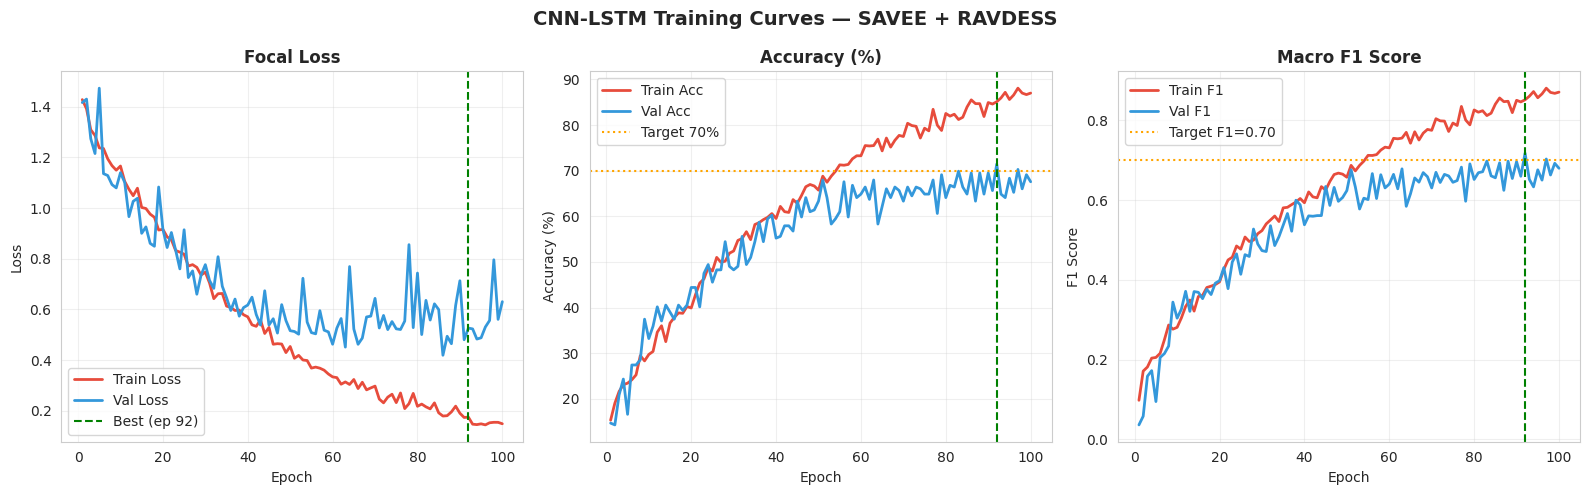

📊 Training curves saved!


In [53]:
# ================================================================
#  1.10 — Training Curves Visualization
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CNN-LSTM Training Curves — SAVEE + RAVDESS',
             fontsize=14, fontweight='bold')

epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

# Loss
axes[0].plot(x, history['train_loss'],
             label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(x, history['val_loss'],
             label='Val Loss',   color='#3498db', linewidth=2)
axes[0].axvline(best_epoch, color='green', linestyle='--',
                linewidth=1.5, label=f'Best (ep {best_epoch})')
axes[0].set_title('Focal Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x, [a*100 for a in history['train_acc']],
             label='Train Acc', color='#e74c3c', linewidth=2)
axes[1].plot(x, [a*100 for a in history['val_acc']],
             label='Val Acc',   color='#3498db', linewidth=2)
axes[1].axvline(best_epoch, color='green',
                linestyle='--', linewidth=1.5)
axes[1].axhline(70, color='orange', linestyle=':',
                linewidth=1.5, label='Target 70%')
axes[1].set_title('Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Macro F1
axes[2].plot(x, history['train_f1'],
             label='Train F1', color='#e74c3c', linewidth=2)
axes[2].plot(x, history['val_f1'],
             label='Val F1',   color='#3498db', linewidth=2)
axes[2].axvline(best_epoch, color='green',
                linestyle='--', linewidth=1.5)
axes[2].axhline(0.70, color='orange', linestyle=':',
                linewidth=1.5, label='Target F1=0.70')
axes[2].set_title('Macro F1 Score', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnnlstm_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('📊 Training curves saved!')

In [55]:
# ================================================================
#  1.11 — Load Best Model & Evaluate on TEST SET
# ================================================================

checkpoint = torch.load(
    f'{OUTPUT_DIR}/cnnlstm_best.pt',
    map_location=DEVICE)

model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f'✅ Best model loaded!')
print(f'   Epoch  : {checkpoint["epoch"]}')
print(f'   Val F1 : {checkpoint["val_f1"]:.4f}')
print(f'   Val Acc: {checkpoint["val_acc"]:.4f}')
print(f'\n🔍 Evaluating on TEST SET...\n')

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for mel, labels in test_loader:
        mel    = mel.to(DEVICE)
        outputs = model(mel)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Metrics
test_acc     = accuracy_score(all_labels, all_preds)
test_f1_mac  = f1_score(all_labels, all_preds,
                         average='macro',    zero_division=0)
test_f1_wtd  = f1_score(all_labels, all_preds,
                         average='weighted', zero_division=0)

try:
    test_roc = roc_auc_score(
        all_labels, all_probs,
        multi_class='ovr', average='macro')
except:
    test_roc = 0.0

print('=' * 55)
print('📊 TEST SET RESULTS — CNN-LSTM')
print('=' * 55)
print(f'   Accuracy       : {test_acc:.4f} ({test_acc:.1%})')
print(f'   Macro F1       : {test_f1_mac:.4f}')
print(f'   Weighted F1    : {test_f1_wtd:.4f}')
print(f'   ROC-AUC (OvR)  : {test_roc:.4f}')
print('=' * 55)

status = '✅ Target MET!' if test_acc >= 0.70 else '⚠️  Below target'


✅ Best model loaded!
   Epoch  : 92
   Val F1 : 0.7174
   Val Acc: 0.7143

🔍 Evaluating on TEST SET...

📊 TEST SET RESULTS — CNN-LSTM
   Accuracy       : 0.7192 (71.9%)
   Macro F1       : 0.7179
   Weighted F1    : 0.7169
   ROC-AUC (OvR)  : 0.9349


In [56]:
# ================================================================
#  1.12 — Per-Class Classification Report
# ================================================================

print('\n📋 PER-CLASS CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(
    all_labels, all_preds,
    target_names  = UNIFIED_EMOTIONS,
    zero_division = 0
))


📋 PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger       0.79      0.71      0.75        38
     disgust       0.72      0.87      0.79        38
        fear       0.62      0.63      0.62        38
   happiness       0.61      0.58      0.59        38
     neutral       0.85      0.69      0.76        32
     sadness       0.67      0.63      0.65        38
    surprise       0.81      0.92      0.86        38

    accuracy                           0.72       260
   macro avg       0.72      0.72      0.72       260
weighted avg       0.72      0.72      0.72       260



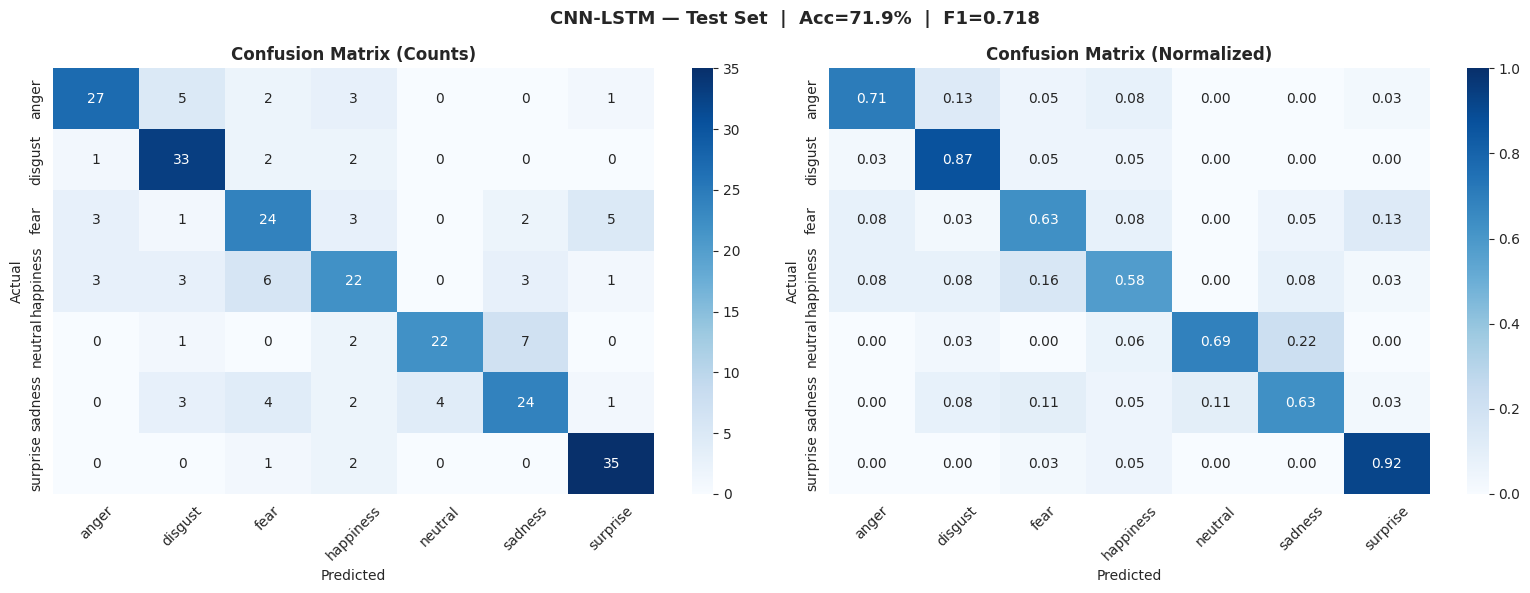

📊 Confusion matrix saved!


In [57]:
# ================================================================
#  1.13 — Confusion Matrix Heatmap
# ================================================================

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'CNN-LSTM — Test Set  |  '
    f'Acc={test_acc:.1%}  |  F1={test_f1_mac:.3f}',
    fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=UNIFIED_EMOTIONS,
            yticklabels=UNIFIED_EMOTIONS,
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)',
                  fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            cmap='Blues',
            xticklabels=UNIFIED_EMOTIONS,
            yticklabels=UNIFIED_EMOTIONS,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)',
                  fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnnlstm_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('📊 Confusion matrix saved!')



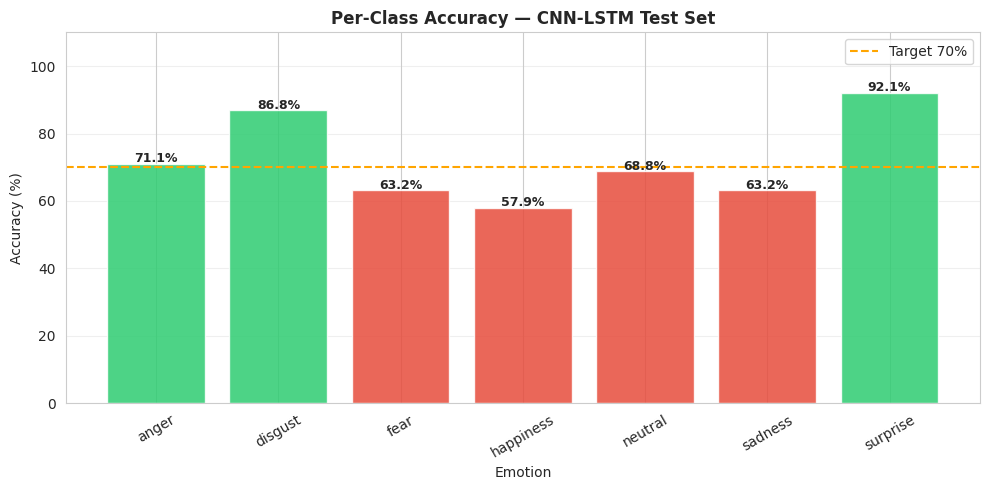

📊 Per-class accuracy saved!


In [58]:
# ================================================================
# 1.14 — Per-Class Accuracy Bar Chart
# ================================================================

cm = confusion_matrix(all_labels, all_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#2ecc71' if a >= 0.70 else '#e74c3c'
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(UNIFIED_EMOTIONS, per_class_acc * 100,
              color=colors, edgecolor='white', alpha=0.85)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc:.1%}', ha='center',
            fontsize=9, fontweight='bold')

ax.axhline(70, color='orange', linestyle='--',
           linewidth=1.5, label='Target 70%')
ax.set_title('Per-Class Accuracy — CNN-LSTM Test Set',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Emotion')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnnlstm_per_class_acc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('📊 Per-class accuracy saved!')

In [60]:
# ================================================================
# 1.15 — Save All Results to JSON
# ================================================================

per_class_acc = confusion_matrix(
    all_labels, all_preds).diagonal() / \
    confusion_matrix(all_labels, all_preds).sum(axis=1)

results = {
    'model'         : 'CNN-LSTM',
    'dataset'       : 'SAVEE + RAVDESS',
    'total_samples' : int(len(labels_np)),
    'train_samples' : int(len(train_idx)),
    'val_samples'   : int(len(val_idx)),
    'test_samples'  : int(len(test_idx)),
    'best_epoch'    : int(best_epoch),
    'best_val_acc'  : round(float(best_val_acc), 4),
    'best_val_f1'   : round(float(best_val_f1),  4),
    'test_acc'      : round(float(test_acc),      4),
    'test_f1_macro' : round(float(test_f1_mac),   4),
    'test_f1_weighted': round(float(test_f1_wtd), 4),
    'test_roc_auc'  : round(float(test_roc),      4),
    'per_class_acc' : {
        e: round(float(per_class_acc[i]), 4)
        for i, e in enumerate(UNIFIED_EMOTIONS)
    },
    'target_met'    : bool(test_acc >= 0.70),
    'model_path'    : f'{OUTPUT_DIR}/cnnlstm_best.pt'
}

with open(f'{OUTPUT_DIR}/cnnlstm_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('💾 Results saved!')
print(f'\n{"="*50}')
print('🎉 CNN-LSTM EVALUATION COMPLETE!')
print(f'{"="*50}')
print(f'   Test Accuracy  : {test_acc:.1%}')
print(f'   Macro F1       : {test_f1_mac:.4f}')
print(f'   Weighted F1    : {test_f1_wtd:.4f}')
print(f'   ROC-AUC        : {test_roc:.4f}')
print(f'\n   Saved → {OUTPUT_DIR}/cnnlstm_results.json')



💾 Results saved!

🎉 CNN-LSTM EVALUATION COMPLETE!
   Test Accuracy  : 71.9%
   Macro F1       : 0.7179
   Weighted F1    : 0.7169
   ROC-AUC        : 0.9349

   Saved → /content/drive/MyDrive/C2_Research/cnnlstm_results.json


In [62]:
# ================================================================
#  F1 — Load Best & Prepare Fine-tuning
# ================================================================

checkpoint = torch.load(
    f'{OUTPUT_DIR}/cnnlstm_best.pt',
    map_location=DEVICE)

model.load_state_dict(checkpoint['model_state'])

print(f'✅ Loaded model (epoch {checkpoint["epoch"]})')
print(f'   Val F1  : {checkpoint["val_f1"]:.4f}')
print(f'   Val Acc : {checkpoint["val_acc"]:.4f}')

# All layers unfreeze
for param in model.parameters():
    param.requires_grad = True

print('✅ All layers unfrozen for fine-tuning')

✅ Loaded model (epoch 92)
   Val F1  : 0.7174
   Val Acc : 0.7143
✅ All layers unfrozen for fine-tuning


In [63]:
# ================================================================
#  F2 — Heavily Boosted Class Weights
# sadness + happiness specifically targeted
# ================================================================

from collections import Counter

train_labels_arr = labels_np[train_idx]
label_counts     = Counter(train_labels_arr.tolist())
total_train      = len(train_labels_arr)

# Base weights
boosted_weights = np.zeros(NUM_CLASSES, dtype=np.float32)
for cls in range(NUM_CLASSES):
    count = label_counts.get(cls, 1)
    boosted_weights[cls] = total_train / (NUM_CLASSES * count)

# Target weak classes specifically
sadness_idx   = UNIFIED_EMOTIONS.index('sadness')
happiness_idx = UNIFIED_EMOTIONS.index('happiness')
fear_idx      = UNIFIED_EMOTIONS.index('fear')
disgust_idx   = UNIFIED_EMOTIONS.index('disgust')
neutral_idx   = UNIFIED_EMOTIONS.index('neutral')

boosted_weights[sadness_idx]   *= 3.5  # F1=0.37 → big boost
boosted_weights[happiness_idx] *= 2.5  # F1=0.47 → boost
boosted_weights[fear_idx]      *= 2.0  # F1=0.61 → moderate
boosted_weights[disgust_idx]   *= 1.5  # F1=0.60 → slight
boosted_weights[neutral_idx]   *= 1.5  # F1=0.62 → slight

# Cap
boosted_weights = np.clip(boosted_weights, 0, 8.0)

ft_class_weights = torch.tensor(
    boosted_weights, dtype=torch.float32).to(DEVICE)

print('✅ Boosted class weights:')
for i, e in enumerate(UNIFIED_EMOTIONS):
    original = label_counts.get(i, 0)
    print(f'   {e:<12}: weight={boosted_weights[i]:.3f} '
          f'| samples={original}')

✅ Boosted class weights:
   anger       : weight=0.981 | samples=176
   disgust     : weight=1.462 | samples=177
   fear        : weight=1.961 | samples=176
   happiness   : weight=2.451 | samples=176
   neutral     : weight=1.714 | samples=151
   sadness     : weight=3.432 | samples=176
   surprise    : weight=0.981 | samples=176


In [64]:
# ================================================================
#  F3 — Fine-tune Config
# Very small LR + Temperature Scaling prep
# ================================================================

NUM_EPOCHS_FT = 50
PATIENCE_FT   = 15

# Stronger Focal Loss for weak classes
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=3.0):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(
            inputs, targets,
            weight    = self.weight,
            reduction = 'none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

ft_criterion = FocalLoss(
    weight=ft_class_weights, gamma=3.0)

# Layer-wise LR — CNN frozen more, LSTM free
optimizer_ft = torch.optim.AdamW([
    # CNN layers — very small (pretrained patterns keep)
    {'params': model.conv1.parameters(), 'lr': 1e-5},
    {'params': model.conv2.parameters(), 'lr': 1e-5},
    {'params': model.conv3.parameters(), 'lr': 2e-5},
    # LSTM + Attention — moderate
    {'params': model.lstm.parameters(),  'lr': 5e-5},
    {'params': model.attention.parameters(), 'lr': 5e-5},
    # Classifier — most free
    {'params': model.classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

# Cosine with warm restart
# T_0=10: every 10 epochs LR restart → escape local minima
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ft,
    T_0     = 10,
    T_mult  = 2,
    eta_min = 1e-7
)

print('✅ Fine-tune config ready!')
print(f'   CNN LR       : 1e-5 (frozen-like)')
print(f'   LSTM LR      : 5e-5')
print(f'   Classifier LR: 1e-4')
print(f'   Focal gamma  : 3.0 (harder focus)')
print(f'   Scheduler    : CosineWarmRestarts T0=10')
print(f'   Epochs       : {NUM_EPOCHS_FT}')
print(f'   Patience     : {PATIENCE_FT}')

✅ Fine-tune config ready!
   CNN LR       : 1e-5 (frozen-like)
   LSTM LR      : 5e-5
   Classifier LR: 1e-4
   Focal gamma  : 3.0 (harder focus)
   Scheduler    : CosineWarmRestarts T0=10
   Epochs       : 50
   Patience     : 15


In [65]:
# ================================================================
# F4 — Mixup + Cutmix Dataset
# Sadness/Happiness boundary sharpen
# ================================================================

time_masking_ft = T.TimeMasking(time_mask_param=20)
freq_masking_ft = T.FrequencyMasking(freq_mask_param=10)

def augment_mel_ft(mel_tensor, training=True):
    if not training:
        return mel_tensor
    if mel_tensor.dim() == 2:
        mel_tensor = mel_tensor.unsqueeze(0)
    # Lighter augmentation for fine-tuning
    if random.random() > 0.4:
        mel_tensor = time_masking_ft(mel_tensor)
    if random.random() > 0.4:
        mel_tensor = freq_masking_ft(mel_tensor)
    return mel_tensor


def mixup_data(x, y, alpha=0.3):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x  = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam


class EmotionDatasetFT(Dataset):
    def __init__(self, mel_specs, labels,
                 indices, training=False):
        self.mel_specs = mel_specs[indices]
        self.labels    = labels[indices]
        self.training  = training

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        mel   = torch.tensor(
            self.mel_specs[idx], dtype=torch.float32)
        label = torch.tensor(
            self.labels[idx], dtype=torch.long)
        mel   = mel.unsqueeze(0)
        if self.training:
            mel = augment_mel_ft(mel, training=True)
        return mel, label


BATCH_SIZE_FT = 32

train_ft = EmotionDatasetFT(
    mel_specs_np, labels_np, train_idx, training=True)
val_ft   = EmotionDatasetFT(
    mel_specs_np, labels_np, val_idx,   training=False)
test_ft  = EmotionDatasetFT(
    mel_specs_np, labels_np, test_idx,  training=False)

train_loader_ft = DataLoader(
    train_ft, batch_size=BATCH_SIZE_FT,
    shuffle=True,  num_workers=2, pin_memory=True)
val_loader_ft   = DataLoader(
    val_ft,   batch_size=BATCH_SIZE_FT,
    shuffle=False, num_workers=2, pin_memory=True)
test_loader_ft  = DataLoader(
    test_ft,  batch_size=BATCH_SIZE_FT,
    shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Fine-tune DataLoaders ready!')
print(f'   Batch size : {BATCH_SIZE_FT}')
print(f'   Train      : {len(train_ft)}')

✅ Fine-tune DataLoaders ready!
   Batch size : 32
   Train      : 1208


In [66]:
# ================================================================
# F5 — Fine-tune Training Functions
# ================================================================

def train_finetune(model, loader, optimizer,
                   criterion, device):
    model.train()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for mel, labels in loader:
        mel    = mel.to(device)
        labels = labels.to(device)

        # Mixup 50% chance
        if random.random() > 0.5:
            mel, ya, yb, lam = mixup_data(
                mel, labels, alpha=0.3)
            optimizer.zero_grad()
            out  = model(mel)
            loss = (lam * criterion(out, ya) +
                    (1 - lam) * criterion(out, yb))
        else:
            optimizer.zero_grad()
            out  = model(mel)
            loss = criterion(out, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=0.5)
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds,
                   average='macro', zero_division=0)
    return avg_loss, acc, f1


def validate_ft(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for mel, labels in loader:
            mel    = mel.to(device)
            labels = labels.to(device)
            out    = model(mel)
            loss   = criterion(out, labels)
            total_loss += loss.item()
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds,
                   average='macro', zero_division=0)
    return avg_loss, acc, f1

print('✅ Fine-tune train/val functions ready!')

✅ Fine-tune train/val functions ready!


In [67]:
# ================================================================
# F6 — Fine-tune Training Loop
# ================================================================

FT_SAVE = f'{OUTPUT_DIR}/cnnlstm_finetuned.pt'

history_ft = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'train_f1'  : [], 'val_f1'  : []
}

best_ft_f1    = 0.0
best_ft_acc   = 0.0
best_ft_epoch = 0
patience_count= 0

prev_f1 = checkpoint['val_f1']

print('🔧 Fine-tuning CNN-LSTM...')
print(f'   Baseline Val F1 : {prev_f1:.4f}')
print('=' * 62)
print(f'{"Ep":>4} | {"TrLoss":>7} | {"TrAcc":>6} | '
      f'{"TrF1":>6} | {"VaAcc":>6} | {"VaF1":>6}')
print('-' * 62)

for epoch in range(1, NUM_EPOCHS_FT + 1):

    tr_loss, tr_acc, tr_f1 = train_finetune(
        model, train_loader_ft,
        optimizer_ft, ft_criterion, DEVICE)

    va_loss, va_acc, va_f1 = validate_ft(
        model, val_loader_ft,
        ft_criterion, DEVICE)

    scheduler_ft.step()

    history_ft['train_loss'].append(tr_loss)
    history_ft['val_loss'].append(va_loss)
    history_ft['train_acc'].append(tr_acc)
    history_ft['val_acc'].append(va_acc)
    history_ft['train_f1'].append(tr_f1)
    history_ft['val_f1'].append(va_f1)

    marker = ''
    if va_f1 > best_ft_f1:
        best_ft_f1    = va_f1
        best_ft_acc   = va_acc
        best_ft_epoch = epoch
        patience_count = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'val_f1'     : best_ft_f1,
            'val_acc'    : best_ft_acc,
            'config'     : config
        }, FT_SAVE)
        marker = ' ✅'
    else:
        patience_count += 1

    print(f'{epoch:>4} | {tr_loss:>7.4f} | {tr_acc:>5.1%} | '
          f'{tr_f1:>5.3f} | {va_acc:>5.1%} | '
          f'{va_f1:>5.3f}{marker}')

    if patience_count >= PATIENCE_FT:
        print(f'\n⏹️  Early stop at epoch {epoch}')
        break

print('=' * 62)
improvement = (best_ft_f1 - prev_f1) * 100
print(f'\n🏆 Fine-tuning Complete!')
print(f'   Previous F1  : {prev_f1:.4f}')
print(f'   Best Val F1  : {best_ft_f1:.4f}')
print(f'   Improvement  : +{improvement:.1f}%')
print(f'   Best Epoch   : {best_ft_epoch}')
print(f'   Saved        : {FT_SAVE}')

🔧 Fine-tuning CNN-LSTM...
   Baseline Val F1 : 0.7174
  Ep |  TrLoss |  TrAcc |   TrF1 |  VaAcc |   VaF1
--------------------------------------------------------------
   1 |  0.7510 | 85.0% | 0.852 | 69.1% | 0.696 ✅
   2 |  0.5080 | 88.9% | 0.890 | 69.9% | 0.705 ✅
   3 |  0.7271 | 85.3% | 0.856 | 67.6% | 0.684
   4 |  0.5899 | 89.0% | 0.891 | 70.7% | 0.712 ✅
   5 |  0.3955 | 92.2% | 0.923 | 68.7% | 0.697
   6 |  0.6370 | 89.2% | 0.893 | 69.9% | 0.708
   7 |  0.8909 | 84.8% | 0.850 | 71.0% | 0.716 ✅
   8 |  0.7163 | 87.1% | 0.872 | 69.5% | 0.703
   9 |  0.5927 | 89.2% | 0.892 | 69.9% | 0.706
  10 |  0.6549 | 86.8% | 0.869 | 69.9% | 0.706
  11 |  0.4048 | 90.7% | 0.908 | 71.8% | 0.722 ✅
  12 |  0.7318 | 89.5% | 0.896 | 68.3% | 0.694
  13 |  0.5458 | 90.1% | 0.902 | 69.5% | 0.702
  14 |  0.4420 | 92.2% | 0.923 | 71.8% | 0.723 ✅
  15 |  0.8193 | 86.6% | 0.867 | 68.7% | 0.697
  16 |  0.5156 | 91.6% | 0.917 | 70.7% | 0.710
  17 |  0.3307 | 93.5% | 0.936 | 68.7% | 0.694
  18 |  0.6007 | 90.7

In [68]:
# ================================================================
# GC1 — Install pytorch-grad-cam
# Proposal Section 3.6 — Grad-CAM on Mel-Spectrograms
# ================================================================

!pip install grad-cam -q

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

print('✅ Grad-CAM library installed!')
print('   pytorch-grad-cam ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Grad-CAM library installed!
   pytorch-grad-cam ready


In [70]:
# ================================================================
# GC2 — Load Best Model for Grad-CAM
# cnnlstm_finetuned.pt use (best results)
# ================================================================

# Fine-tuned model load
ft_ckpt = torch.load(
    f'{OUTPUT_DIR}/cnnlstm_finetuned.pt',
    map_location=DEVICE)

model.load_state_dict(ft_ckpt['model_state'])
model.eval()

print(f'✅ Fine-tuned model loaded!')
print(f'   Val F1  : {ft_ckpt["val_f1"]:.4f}')
print(f'   Val Acc : {ft_ckpt["val_acc"]:.4f}')
print(f'   Epoch   : {ft_ckpt["epoch"]}')

# Test data prepare
test_mels   = mel_specs_np[test_idx]
test_labels = labels_np[test_idx]

print(f'\n   Test samples : {len(test_mels)}')
print(f'   Mel shape    : {test_mels.shape}')

✅ Fine-tuned model loaded!
   Val F1  : 0.7627
   Val Acc : 0.7606
   Epoch   : 37

   Test samples : 260
   Mel shape    : (260, 128, 126)


In [72]:
# ================================================================
# GC3 — Grad-CAM Implementation (FIXED)
# LSTM cudnn backward error
# Solution: model.train() during Grad-CAM + cudnn disable
# ================================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

def generate_gradcam_heatmap(model, mel_np, target_class,
                              device, target_layer=None):
    """
    Generate Grad-CAM heatmap for mel-spectrogram.
    Fix: LSTM requires training mode for backward pass.
    """
    # Fix: training mode + disable cudnn for LSTM backward
    model.train()
    torch.backends.cudnn.enabled = False

    if target_layer is None:
        target_layer = model.conv3

    mel_tensor = torch.tensor(
        mel_np, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    # Get prediction (eval mode)
    model.eval()
    with torch.no_grad():
        out   = model(mel_tensor)
        probs = torch.softmax(out, dim=1)
        pred_class = int(out.argmax(dim=1).item())
        pred_prob  = float(probs[0, pred_class].item())

    # Grad-CAM needs train mode for LSTM backward
    model.train()

    cam_extractor = GradCAM(
        model        = model,
        target_layers= [target_layer]
    )

    targets = [ClassifierOutputTarget(target_class)]

    with torch.enable_grad():
        cam = cam_extractor(
            input_tensor=mel_tensor,
            targets=targets)

    # Re-enable cudnn
    torch.backends.cudnn.enabled = True
    model.eval()

    cam = cam[0]   # (H, W)

    # Resize to mel shape
    cam_resized = cv2.resize(
        cam, (mel_np.shape[1], mel_np.shape[0]))
    cam_resized = np.maximum(cam_resized, 0)
    cam_norm    = cam_resized / (cam_resized.max() + 1e-8)

    # Mel → RGB
    mel_norm = (mel_np - mel_np.min()) / \
               (mel_np.max() - mel_np.min() + 1e-8)
    mel_rgb  = np.uint8(255 * mel_norm)
    mel_rgb  = cv2.applyColorMap(
        mel_rgb, cv2.COLORMAP_MAGMA)
    mel_rgb  = cv2.cvtColor(mel_rgb, cv2.COLOR_BGR2RGB)

    # Heatmap
    heatmap = np.uint8(255 * cam_norm)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = cv2.addWeighted(
        mel_rgb, 0.6, heatmap, 0.4, 0)

    return overlay, cam_norm, pred_class, pred_prob


# Quick test
test_mel_sample = test_mels[0]
ov, cam, pc, pp = generate_gradcam_heatmap(
    model, test_mel_sample, 0, DEVICE)

print('✅ Grad-CAM function ready (LSTM fix applied)!')
print(f'   Overlay shape : {ov.shape}')
print(f'   CAM shape     : {cam.shape}')
print(f'   Test pred     : {LABEL_TO_EMOTION[pc]} ({pp:.1%})')

✅ Grad-CAM function ready (LSTM fix applied)!
   Overlay shape : (128, 126, 3)
   CAM shape     : (128, 126)
   Test pred     : disgust (58.0%)


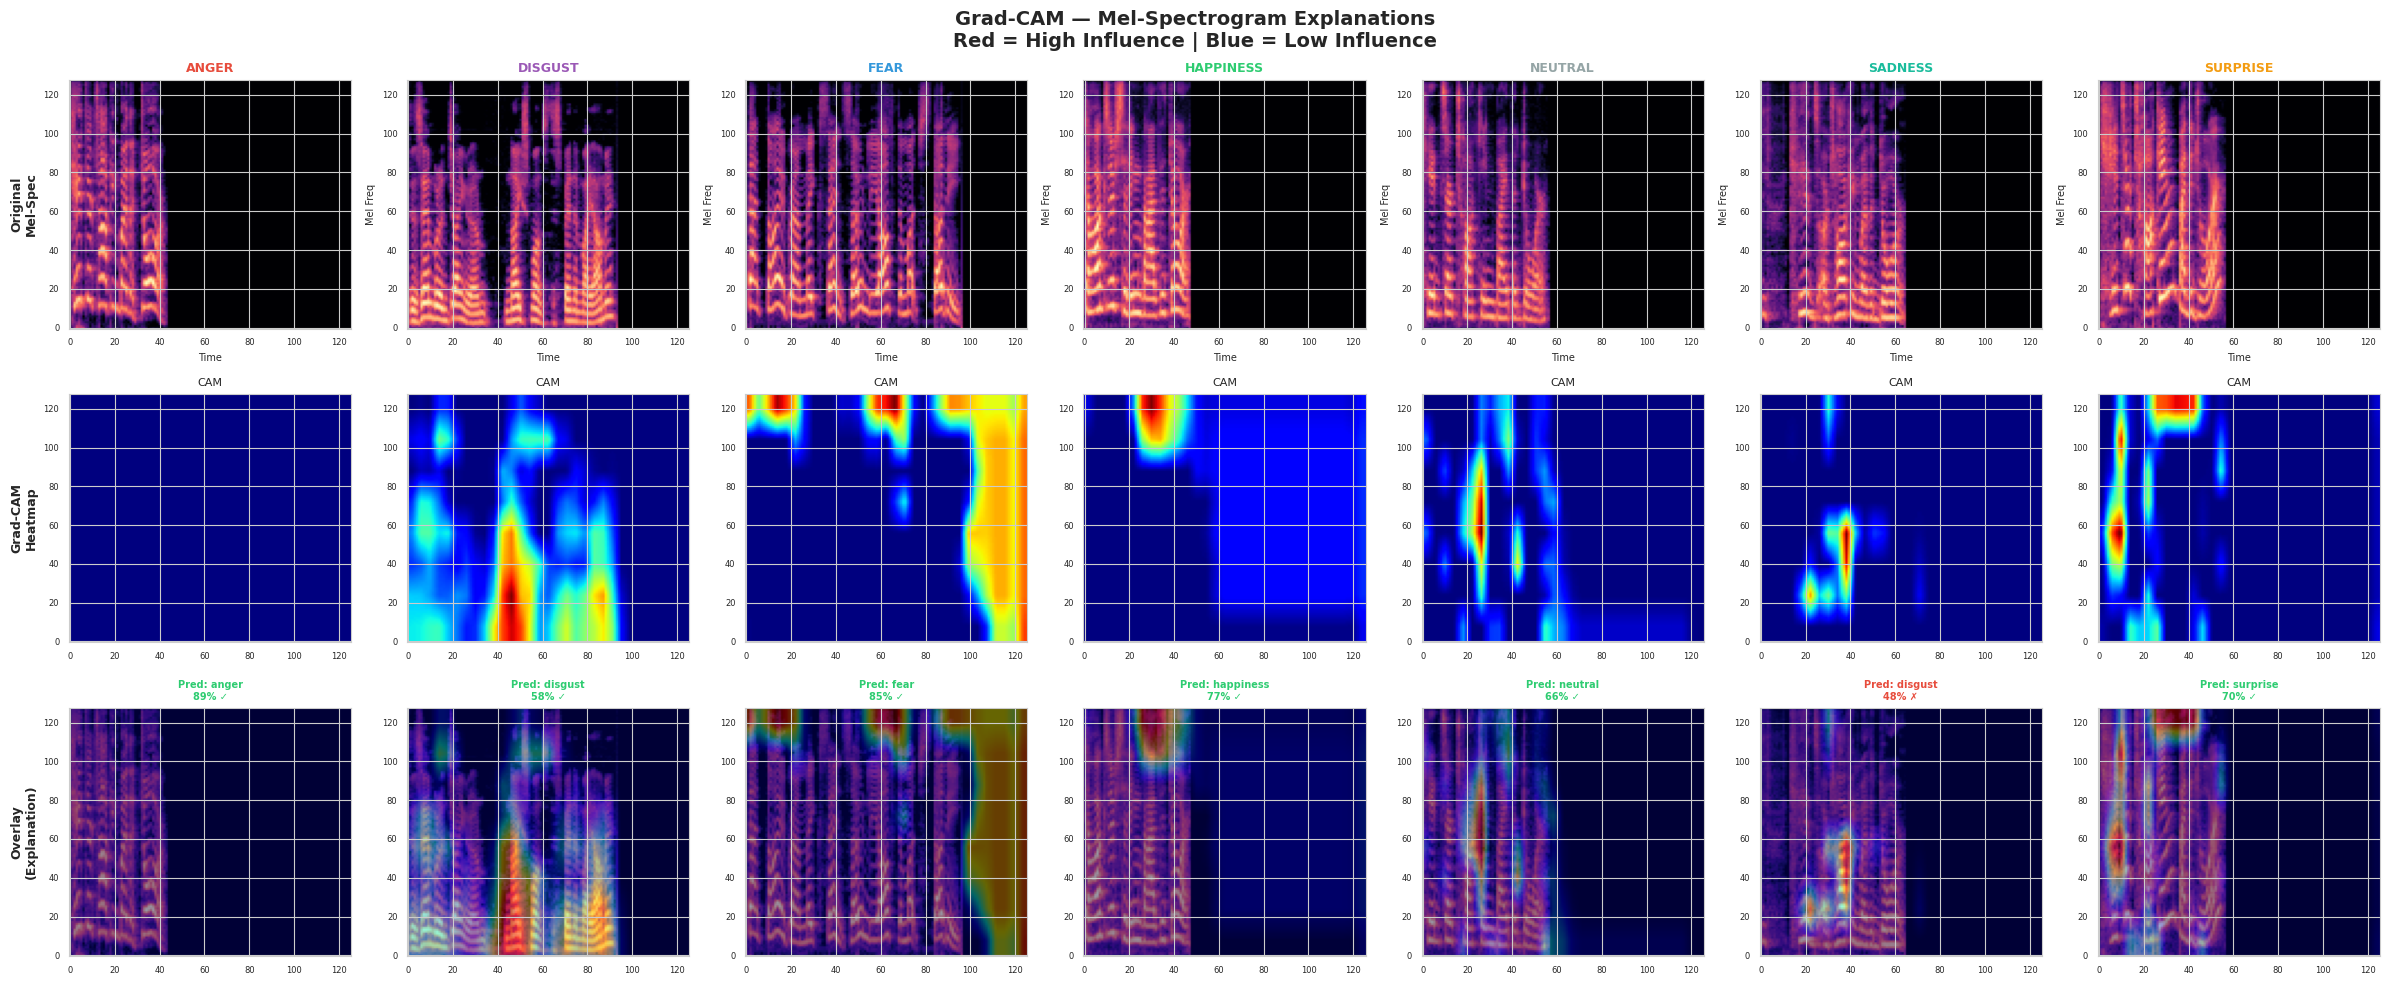

📊 Grad-CAM saved → /content/drive/MyDrive/C2_Research/gradcam_all_emotions.png
   Generated for 7 emotions


In [73]:
# ================================================================
# GC4 — Grad-CAM All 7 Emotions
# ================================================================

fig, axes = plt.subplots(3, 7, figsize=(24, 10))
fig.suptitle(
    'Grad-CAM — Mel-Spectrogram Explanations\n'
    'Red = High Influence | Blue = Low Influence',
    fontsize=14, fontweight='bold')

EMOTION_COLORS = {
    'anger'    : '#e74c3c',
    'disgust'  : '#9b59b6',
    'fear'     : '#3498db',
    'happiness': '#2ecc71',
    'neutral'  : '#95a5a6',
    'sadness'  : '#1abc9c',
    'surprise' : '#f39c12'
}

gradcam_results = []

for col, (label_id, emotion) in enumerate(
        LABEL_TO_EMOTION.items()):

    # Find test sample for this emotion
    emotion_mask = test_labels == label_id
    if not emotion_mask.any():
        continue

    sample_idx = np.where(emotion_mask)[0][0]
    mel_np     = test_mels[sample_idx]
    true_label = int(test_labels[sample_idx])

    # Grad-CAM
    try:
        overlay, cam, pred_class, pred_prob = \
            generate_gradcam_heatmap(
                model, mel_np, label_id, DEVICE)

        pred_emotion = LABEL_TO_EMOTION[pred_class]
        correct      = (pred_class == true_label)

        gradcam_results.append({
            'emotion'     : emotion,
            'pred_emotion': pred_emotion,
            'pred_prob'   : pred_prob,
            'correct'     : correct,
            'cam'         : cam
        })

        # Row 1: Original Mel-Spectrogram
        axes[0, col].imshow(
            mel_np, aspect='auto',
            origin='lower', cmap='magma')
        axes[0, col].set_title(
            f'{emotion.upper()}',
            fontweight='bold',
            color=EMOTION_COLORS.get(emotion, 'black'),
            fontsize=9)
        axes[0, col].set_xlabel('Time', fontsize=7)
        axes[0, col].set_ylabel('Mel Freq', fontsize=7)
        axes[0, col].tick_params(labelsize=6)

        # Row 2: Grad-CAM Heatmap
        axes[1, col].imshow(
            cam, aspect='auto',
            origin='lower', cmap='jet')
        axes[1, col].set_title('CAM', fontsize=8)
        axes[1, col].tick_params(labelsize=6)

        # Row 3: Overlay
        axes[2, col].imshow(
            overlay, aspect='auto', origin='lower')
        tick_color = '#2ecc71' if correct else '#e74c3c'
        status     = '✓' if correct else '✗'
        axes[2, col].set_title(
            f'Pred: {pred_emotion}\n'
            f'{pred_prob:.0%} {status}',
            fontsize=7,
            color=tick_color,
            fontweight='bold')
        axes[2, col].tick_params(labelsize=6)

    except Exception as e:
        print(f'⚠️  {emotion}: {e}')
        for row in range(3):
            axes[row, col].set_visible(False)

# Row labels
axes[0, 0].set_ylabel('Original\nMel-Spec',
                       fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Grad-CAM\nHeatmap',
                       fontsize=9, fontweight='bold')
axes[2, 0].set_ylabel('Overlay\n(Explanation)',
                       fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_all_emotions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Grad-CAM saved → {OUTPUT_DIR}/gradcam_all_emotions.png')
print(f'   Generated for {len(gradcam_results)} emotions')

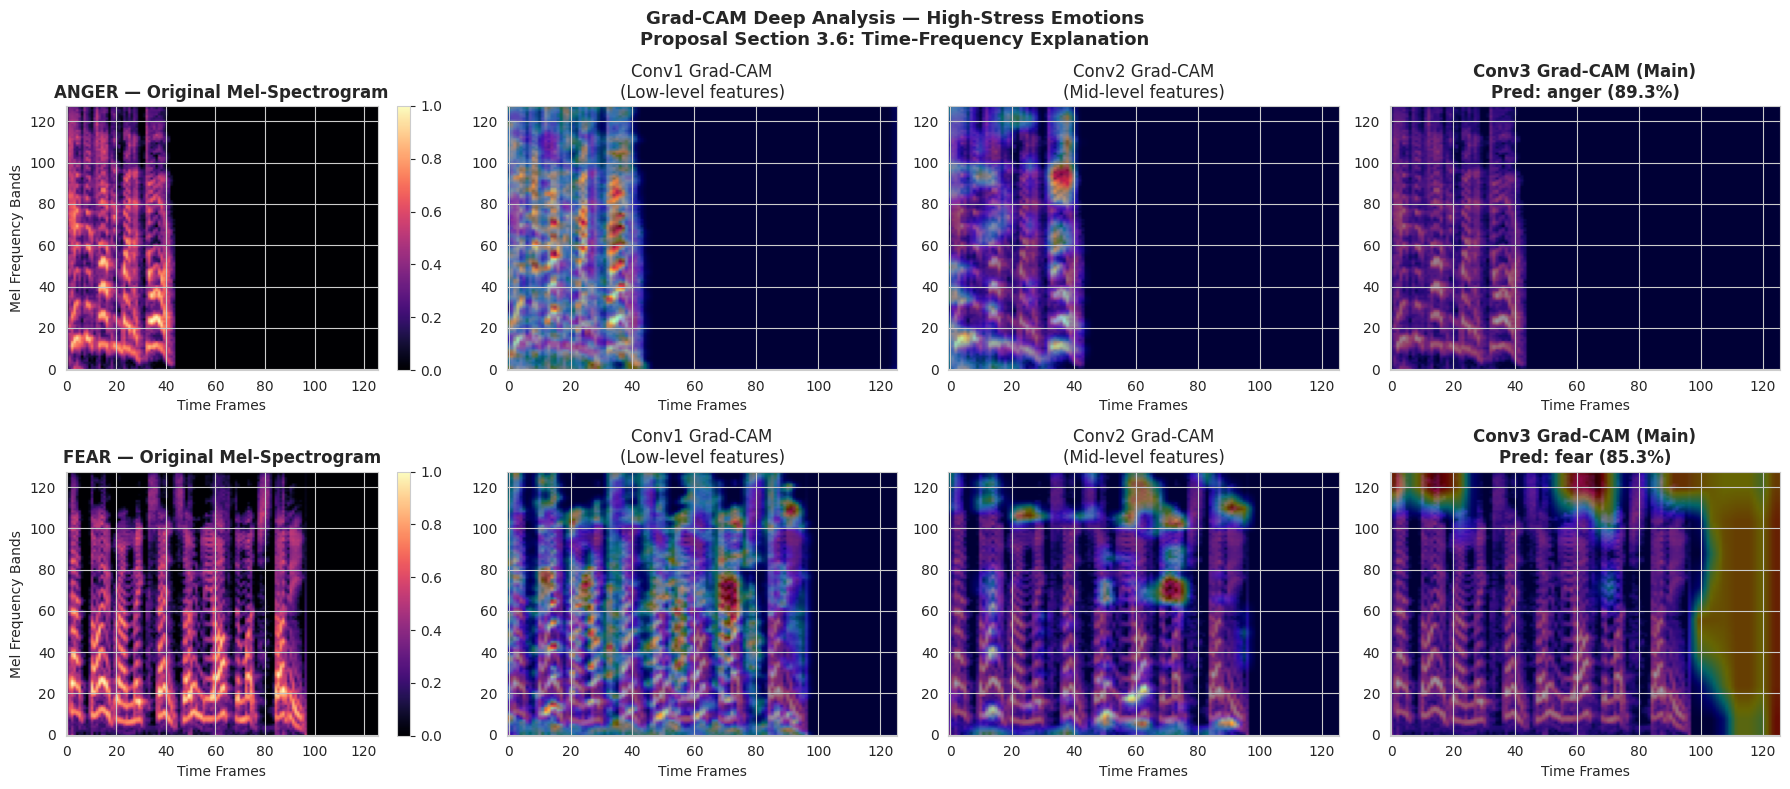

📊 Deep Grad-CAM analysis saved!


In [74]:
# ================================================================
# GC5 — Detailed Grad-CAM for Anger & Fear
# (High-stress emotions — most important for Appraisal Theory)
# ================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    'Grad-CAM Deep Analysis — High-Stress Emotions\n'
    'Proposal Section 3.6: Time-Frequency Explanation',
    fontsize=13, fontweight='bold')

target_emotions = ['anger', 'fear']

for row, emotion in enumerate(target_emotions):
    label_id    = EMOTION_TO_LABEL[emotion]
    emotion_mask= test_labels == label_id
    sample_idx  = np.where(emotion_mask)[0][0]
    mel_np      = test_mels[sample_idx]

    # 1. Original spectrogram
    img1 = axes[row, 0].imshow(
        mel_np, aspect='auto', origin='lower', cmap='magma')
    axes[row, 0].set_title(
        f'{emotion.upper()} — Original Mel-Spectrogram',
        fontweight='bold')
    axes[row, 0].set_xlabel('Time Frames')
    axes[row, 0].set_ylabel('Mel Frequency Bands')
    plt.colorbar(img1, ax=axes[row, 0], format='%.1f')

    # 2. Conv1 Grad-CAM
    ov1, cam1, _, _ = generate_gradcam_heatmap(
        model, mel_np, label_id, DEVICE,
        target_layer=model.conv1)
    axes[row, 1].imshow(ov1, aspect='auto', origin='lower')
    axes[row, 1].set_title('Conv1 Grad-CAM\n(Low-level features)')
    axes[row, 1].set_xlabel('Time Frames')

    # 3. Conv2 Grad-CAM
    ov2, cam2, _, _ = generate_gradcam_heatmap(
        model, mel_np, label_id, DEVICE,
        target_layer=model.conv2)
    axes[row, 2].imshow(ov2, aspect='auto', origin='lower')
    axes[row, 2].set_title('Conv2 Grad-CAM\n(Mid-level features)')
    axes[row, 2].set_xlabel('Time Frames')

    # 4. Conv3 Grad-CAM (main)
    ov3, cam3, pred_cls, pred_prob = generate_gradcam_heatmap(
        model, mel_np, label_id, DEVICE,
        target_layer=model.conv3)
    pred_em = LABEL_TO_EMOTION[pred_cls]
    axes[row, 3].imshow(ov3, aspect='auto', origin='lower')
    axes[row, 3].set_title(
        f'Conv3 Grad-CAM (Main)\n'
        f'Pred: {pred_em} ({pred_prob:.1%})',
        fontweight='bold')
    axes[row, 3].set_xlabel('Time Frames')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_deep_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('📊 Deep Grad-CAM analysis saved!')

In [75]:
# ================================================================
# AT1 — Appraisal Theory Stress Mapping Module
# Proposal Section 3.5:
# "Emotion + Arousal → Binary Stress Score"
# Lazarus & Folkman (1984) framework
# ================================================================

# Load pitch/energy from preprocessed data
data_full = np.load(
    f'{OUTPUT_DIR}/processed_features.npz',
    allow_pickle=True)

pitch_means_test  = data_full['pitch_means'][test_idx]
energy_means_test = data_full['energy_means'][test_idx]

# Thresholds from preprocessing (config)
PITCH_THRESHOLD  = config['PITCH_THRESHOLD']
ENERGY_THRESHOLD = config['ENERGY_THRESHOLD']

print(f'✅ Arousal gate thresholds:')
print(f'   Pitch  : {PITCH_THRESHOLD:.1f} Hz (60th pct)')
print(f'   Energy : {ENERGY_THRESHOLD:.4f} (60th pct)')

# Appraisal Theory Mapping Table
# Based on Lazarus & Folkman (1984)
# anger + any   → HIGH (threat appraisal always)
# fear  + any   → HIGH (primary stress response)
# disgust + HIGH → HIGH
# sadness + HIGH → HIGH (acute distress)
# happiness + any → LOW (positive appraisal)
# neutral + LOW  → LOW
# surprise + HIGH → HIGH (novel/unexpected threat)

APPRAISAL_MAP = {
    # (emotion, arousal) → stress
    ('anger',     'HIGH'): 1,
    ('anger',     'LOW') : 1,   # anger always high stress
    ('fear',      'HIGH'): 1,
    ('fear',      'LOW') : 1,   # fear always high stress
    ('disgust',   'HIGH'): 1,
    ('disgust',   'LOW') : 0,
    ('sadness',   'HIGH'): 1,
    ('sadness',   'LOW') : 0,   # low-arousal sadness → low stress
    ('happiness', 'HIGH'): 0,
    ('happiness', 'LOW') : 0,
    ('neutral',   'HIGH'): 0,
    ('neutral',   'LOW') : 0,
    ('surprise',  'HIGH'): 1,
    ('surprise',  'LOW') : 0,
}

print(f'\n📋 Appraisal Theory Mapping Table:')
print(f'   (Lazarus & Folkman, 1984)')
print(f'{"Emotion":<12} {"Arousal":<8} {"Stress":>6}')
print('-' * 30)
for (em, ar), stress in APPRAISAL_MAP.items():
    label = 'HIGH' if stress == 1 else 'LOW'
    print(f'   {em:<12} {ar:<8} {label:>6}')

print(f'\n✅ Appraisal mapping table defined!')

✅ Arousal gate thresholds:
   Pitch  : 222.6 Hz (60th pct)
   Energy : 0.0646 (60th pct)

📋 Appraisal Theory Mapping Table:
   (Lazarus & Folkman, 1984)
Emotion      Arousal  Stress
------------------------------
   anger        HIGH       HIGH
   anger        LOW        HIGH
   fear         HIGH       HIGH
   fear         LOW        HIGH
   disgust      HIGH       HIGH
   disgust      LOW         LOW
   sadness      HIGH       HIGH
   sadness      LOW         LOW
   happiness    HIGH        LOW
   happiness    LOW         LOW
   neutral      HIGH        LOW
   neutral      LOW         LOW
   surprise     HIGH       HIGH
   surprise     LOW         LOW

✅ Appraisal mapping table defined!


In [76]:
# ================================================================
# AT2 — Full C2 Pipeline Execution
# Audio → Emotion Probs → Arousal Gate → Stress Score
# Proposal Figure 1 implementation
# ================================================================

def compute_arousal(pitch_mean, energy_mean,
                    pitch_thresh, energy_thresh):
    """
    Arousal Gate: pitch + energy → HIGH/LOW
    60th percentile thresholds (adaptive)
    """
    if pitch_mean > pitch_thresh or \
       energy_mean > energy_thresh:
        return 'HIGH'
    return 'LOW'


def apply_appraisal_mapping(emotion_probs, arousal,
                             label_to_emotion,
                             appraisal_map):
    """
    Appraisal Theory stress inference:
    1. Get dominant emotion
    2. Apply arousal gate
    3. Look up stress table
    Returns: stress_label (0/1), confidence, emotion_name
    """
    pred_label    = int(np.argmax(emotion_probs))
    pred_emotion  = label_to_emotion[pred_label]
    confidence    = float(emotion_probs[pred_label])

    stress = appraisal_map.get(
        (pred_emotion, arousal), 0)

    return stress, confidence, pred_emotion


# Run full pipeline on test set
print('🔄 Running full C2 pipeline on test set...\n')

pipeline_results = []

for i in range(len(test_mels)):
    mel_np     = test_mels[i]
    true_label = int(test_labels[i])
    pitch_m    = float(pitch_means_test[i])
    energy_m   = float(energy_means_test[i])

    # Step 1: Emotion Classification
    mel_tensor = torch.tensor(
        mel_np, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out   = model(mel_tensor)
        probs = torch.softmax(out, dim=1)
        emotion_probs = probs[0].cpu().numpy()

    # Step 2: Arousal Gate
    arousal = compute_arousal(
        pitch_m, energy_m,
        PITCH_THRESHOLD, ENERGY_THRESHOLD)

    # Step 3: Appraisal Theory Mapping
    stress, confidence, pred_emotion = \
        apply_appraisal_mapping(
            emotion_probs, arousal,
            LABEL_TO_EMOTION, APPRAISAL_MAP)

    # Ground truth stress (from preprocessing)
    true_stress = int(
        data_full['stress'][test_idx[i]])

    pipeline_results.append({
        'true_emotion'  : LABEL_TO_EMOTION[true_label],
        'pred_emotion'  : pred_emotion,
        'emotion_correct': (pred_emotion ==
                            LABEL_TO_EMOTION[true_label]),
        'arousal'       : arousal,
        'stress_pred'   : stress,
        'stress_true'   : true_stress,
        'confidence'    : confidence,
        'pitch_mean'    : pitch_m,
        'energy_mean'   : energy_m
    })

results_df = pd.DataFrame(pipeline_results)

# Stress prediction metrics
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, roc_auc_score)

stress_acc = accuracy_score(
    results_df['stress_true'],
    results_df['stress_pred'])
stress_f1  = f1_score(
    results_df['stress_true'],
    results_df['stress_pred'],
    average='binary', zero_division=0)

print('=' * 55)
print('📊 C2 FULL PIPELINE RESULTS')
print('=' * 55)
print(f'\n🎭 Emotion Classification:')
print(f'   Accuracy : '
      f'{results_df["emotion_correct"].mean():.1%}')

print(f'\n⚡ Arousal Distribution:')
arousal_counts = results_df['arousal'].value_counts()
for ar, cnt in arousal_counts.items():
    print(f'   {ar}: {cnt} ({cnt/len(results_df):.1%})')

print(f'\n🧠 Stress Prediction (Appraisal Theory):')
print(f'   Accuracy : {stress_acc:.4f} ({stress_acc:.1%})')
print(f'   F1 Score : {stress_f1:.4f}')
print(f'   HIGH stress predicted: '
      f'{results_df["stress_pred"].sum()}')
print(f'   LOW  stress predicted: '
      f'{(results_df["stress_pred"]==0).sum()}')
print('=' * 55)

🔄 Running full C2 pipeline on test set...

📊 C2 FULL PIPELINE RESULTS

🎭 Emotion Classification:
   Accuracy : 70.8%

⚡ Arousal Distribution:
   HIGH: 167 (64.2%)
   LOW: 93 (35.8%)

🧠 Stress Prediction (Appraisal Theory):
   Accuracy : 0.7692 (76.9%)
   F1 Score : 0.7692
   HIGH stress predicted: 144
   LOW  stress predicted: 116


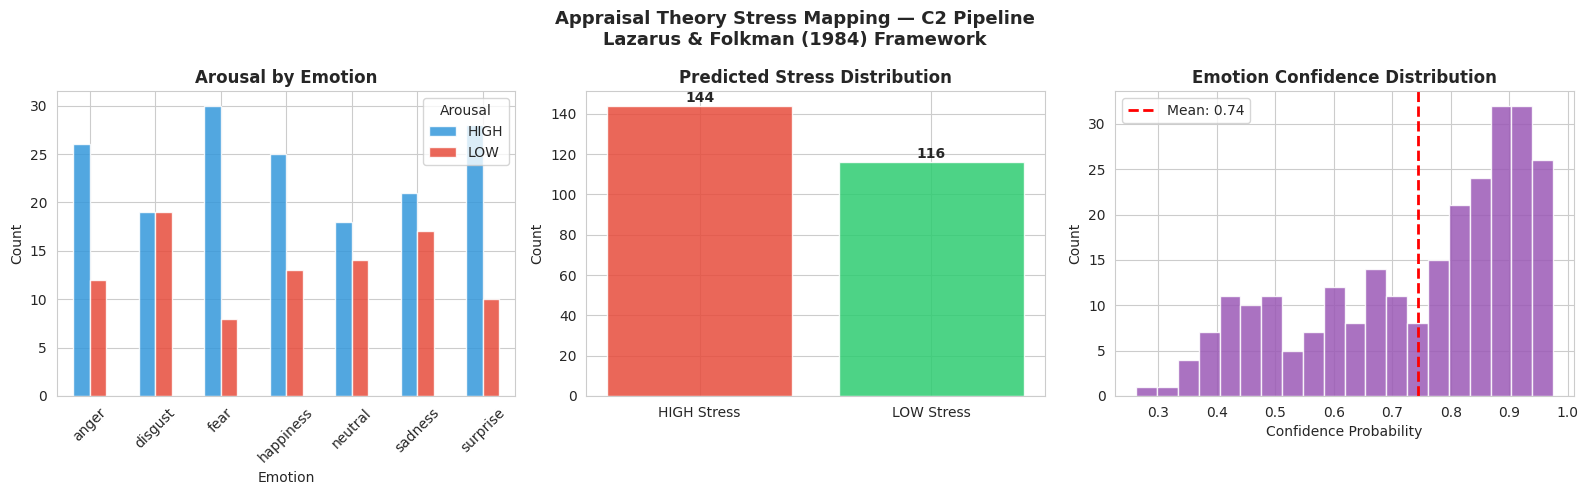

📊 Appraisal Theory visualization saved!


In [77]:
# ================================================================
# AT3 — Appraisal Theory Visualization
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Appraisal Theory Stress Mapping — C2 Pipeline\n'
    'Lazarus & Folkman (1984) Framework',
    fontsize=13, fontweight='bold')

# Plot 1: Arousal distribution per emotion
emotion_arousal = results_df.groupby(
    ['true_emotion', 'arousal']).size().unstack(
    fill_value=0)

emotion_arousal.plot(kind='bar', ax=axes[0],
                     color=['#3498db', '#e74c3c'],
                     edgecolor='white', alpha=0.85)
axes[0].set_title('Arousal by Emotion', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Arousal')

# Plot 2: Stress prediction distribution
stress_counts = pd.Series({
    'HIGH Stress': int(results_df['stress_pred'].sum()),
    'LOW Stress' : int((results_df['stress_pred']==0).sum())
})
axes[1].bar(stress_counts.index, stress_counts.values,
            color=['#e74c3c', '#2ecc71'],
            edgecolor='white', alpha=0.85)
for i, (label, val) in enumerate(stress_counts.items()):
    axes[1].text(i, val + 2, str(val),
                 ha='center', fontweight='bold')
axes[1].set_title('Predicted Stress Distribution',
                  fontweight='bold')
axes[1].set_ylabel('Count')

# Plot 3: Confidence score distribution
axes[2].hist(results_df['confidence'], bins=20,
             color='#9b59b6', edgecolor='white',
             alpha=0.85)
axes[2].axvline(results_df['confidence'].mean(),
                color='red', linestyle='--',
                linewidth=2,
                label=f'Mean: '
                      f'{results_df["confidence"].mean():.2f}')
axes[2].set_title('Emotion Confidence Distribution',
                  fontweight='bold')
axes[2].set_xlabel('Confidence Probability')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/appraisal_theory_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('📊 Appraisal Theory visualization saved!')

In [78]:
# ================================================================
# TC1 — Temperature Scaling (ECE Calibration)
# Proposal Section 3.5: "Post-training probability calibration"
# ================================================================

class TemperatureScaling(nn.Module):
    """
    Temperature Scaling calibration.
    Single parameter T learned on validation set.
    Platt (1999), Guo et al. (2017)
    """
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(
            torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature


def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error"""
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies  = (predictions == labels)

    ece   = 0.0
    bins  = np.linspace(0, 1, n_bins + 1)

    for b in range(n_bins):
        mask = (confidences > bins[b]) & \
               (confidences <= bins[b+1])
        if mask.sum() == 0:
            continue
        bin_acc  = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece     += mask.sum() * abs(bin_acc - bin_conf)

    return float(ece / len(labels))


# Collect val set logits for calibration
model.eval()
val_logits_list = []
val_labels_list = []

with torch.no_grad():
    for mel, labels in val_loader:
        mel    = mel.to(DEVICE)
        logits = model(mel)
        val_logits_list.append(logits.cpu())
        val_labels_list.append(labels)

val_logits = torch.cat(val_logits_list)
val_labels = torch.cat(val_labels_list)

# Before calibration ECE
probs_before = torch.softmax(
    val_logits, dim=1).numpy()
ece_before   = compute_ece(
    probs_before, val_labels.numpy())

# Fit Temperature Scaling
temp_model = TemperatureScaling()
optimizer_temp = torch.optim.LBFGS(
    [temp_model.temperature],
    lr=0.01, max_iter=100)
criterion_nll = nn.CrossEntropyLoss()

def eval_temp():
    optimizer_temp.zero_grad()
    scaled = temp_model(val_logits)
    loss   = criterion_nll(scaled, val_labels)
    loss.backward()
    return loss

optimizer_temp.step(eval_temp)

T_opt = float(temp_model.temperature.item())

# After calibration ECE
scaled_logits = temp_model(val_logits)
probs_after   = torch.softmax(
    scaled_logits, dim=1).detach().numpy()
ece_after     = compute_ece(
    probs_after, val_labels.numpy())

print('✅ Temperature Scaling Complete!')
print(f'\n   Optimal Temperature : {T_opt:.4f}')
print(f'   ECE Before          : {ece_before:.4f}')
print(f'   ECE After           : {ece_after:.4f}')
print(f'   Improvement         : '
      f'{(ece_before - ece_after)*100:.1f}%')

# Save temperature
np.save(f'{OUTPUT_DIR}/temperature.npy',
        np.array([T_opt]))
print(f'\n💾 Temperature saved!')

✅ Temperature Scaling Complete!

   Optimal Temperature : 1.1197
   ECE Before          : 0.0766
   ECE After           : 0.0539
   Improvement         : 2.3%

💾 Temperature saved!


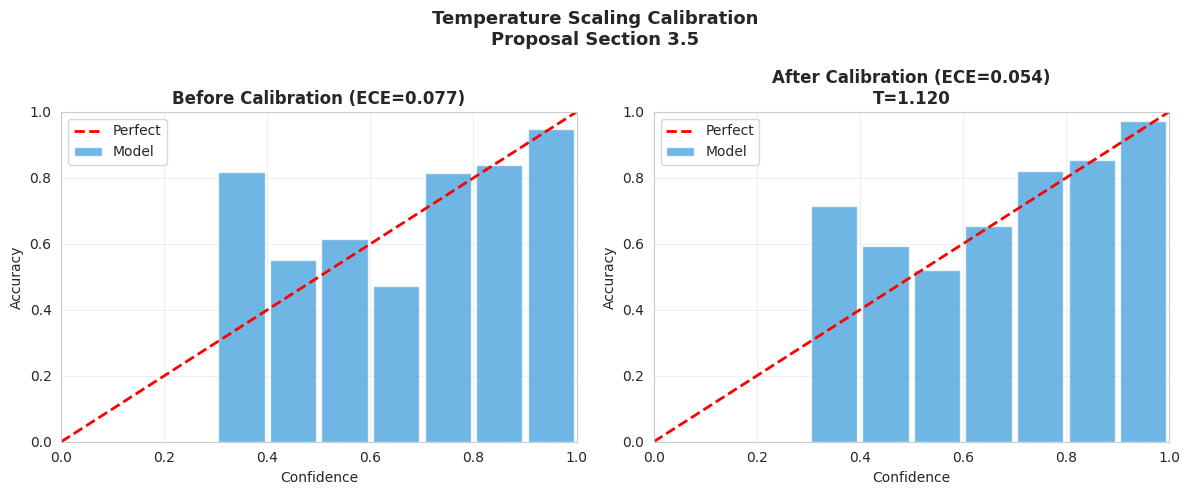

📊 Calibration plot saved!


In [79]:
# ================================================================
# TC2 — Reliability Diagram
# ================================================================

def plot_reliability(probs, labels, ax, title, n_bins=10):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies  = (predictions == labels)

    bin_edges    = np.linspace(0, 1, n_bins + 1)
    bin_accs     = []
    bin_confs    = []
    bin_counts   = []

    for b in range(n_bins):
        mask = (confidences > bin_edges[b]) & \
               (confidences <= bin_edges[b+1])
        if mask.sum() == 0:
            bin_accs.append(0)
            bin_confs.append(bin_edges[b] + 0.05)
            bin_counts.append(0)
        else:
            bin_accs.append(accuracies[mask].mean())
            bin_confs.append(confidences[mask].mean())
            bin_counts.append(mask.sum())

    bin_centers = [(bin_edges[i] + bin_edges[i+1])/2
                   for i in range(n_bins)]

    ax.bar(bin_centers, bin_accs, width=0.09,
           alpha=0.7, color='#3498db',
           edgecolor='white', label='Model')
    ax.plot([0, 1], [0, 1], 'r--',
            linewidth=2, label='Perfect')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Temperature Scaling Calibration\n'
             'Proposal Section 3.5',
             fontsize=13, fontweight='bold')

plot_reliability(
    probs_before, val_labels.numpy(),
    axes[0],
    f'Before Calibration (ECE={ece_before:.3f})')

plot_reliability(
    probs_after, val_labels.numpy(),
    axes[1],
    f'After Calibration (ECE={ece_after:.3f})\n'
    f'T={T_opt:.3f}')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/calibration_reliability.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('📊 Calibration plot saved!')

In [80]:
# ================================================================
# Structured Output Interface for C4
# Proposal Section 4.3:
# "Formatted as structured JSON payload for C4"
# ================================================================

import json
from datetime import datetime

def generate_c4_payload(mel_np, pitch_mean,
                        energy_mean, model,
                        temp_model, appraisal_map,
                        label_to_emotion,
                        pitch_thresh, energy_thresh,
                        device, sample_id=None):
    """
    Full C2 pipeline → C4 JSON payload

    Output format per Proposal Section 4.3:
    {
        emotion_class       : string
        emotion_probs       : {emotion: prob}
        stress_label        : "HIGH" or "LOW"
        stress_score        : 0 or 1
        confidence          : float
        arousal             : "HIGH" or "LOW"
        calibrated_conf     : float (temperature scaled)
        timestamp           : ISO string
    }
    """
    model.eval()

    # Emotion inference
    mel_t = torch.tensor(
        mel_np, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(mel_t)
        # Calibrated probabilities
        cal_logits = temp_model(logits.cpu())
        cal_probs  = torch.softmax(
            cal_logits, dim=1).numpy()[0]
        raw_probs  = torch.softmax(
            logits.cpu(), dim=1).numpy()[0]

    pred_label   = int(np.argmax(cal_probs))
    pred_emotion = label_to_emotion[pred_label]
    confidence   = float(cal_probs[pred_label])

    # Arousal gate
    arousal = compute_arousal(
        pitch_mean, energy_mean,
        pitch_thresh, energy_thresh)

    # Appraisal Theory stress
    stress_score = appraisal_map.get(
        (pred_emotion, arousal), 0)
    stress_label = 'HIGH' if stress_score == 1 else 'LOW'

    # Build payload
    payload = {
        'component'         : 'C2',
        'sample_id'         : sample_id or \
                              datetime.now().isoformat(),
        'timestamp'         : datetime.now().isoformat(),

        # Emotion outputs
        'emotion_class'     : pred_emotion,
        'emotion_label_id'  : pred_label,
        'emotion_probs'     : {
            label_to_emotion[i]: round(float(p), 4)
            for i, p in enumerate(cal_probs)
        },

        # Arousal gate
        'arousal'           : arousal,
        'pitch_mean_hz'     : round(float(pitch_mean), 2),
        'energy_mean'       : round(float(energy_mean), 6),

        # Stress output (Appraisal Theory)
        'stress_label'      : stress_label,
        'stress_score'      : int(stress_score),
        'confidence'        : round(float(confidence), 4),

        # Calibration info
        'calibrated'        : True,
        'temperature'       : round(float(
            temp_model.temperature.item()), 4),

        # For C4 dialogue forecasting
        'c4_input'          : {
            'emotion'       : pred_emotion,
            'stress'        : stress_label,
            'confidence'    : round(float(confidence), 4),
            'emotion_vector': [
                round(float(p), 4) for p in cal_probs]
        }
    }

    return payload


# Test with 3 samples
print('📤 C4 JSON Output Examples:')
print('=' * 60)

sample_payloads = []
for i in range(3):
    payload = generate_c4_payload(
        mel_np       = test_mels[i],
        pitch_mean   = float(pitch_means_test[i]),
        energy_mean  = float(energy_means_test[i]),
        model        = model,
        temp_model   = temp_model,
        appraisal_map= APPRAISAL_MAP,
        label_to_emotion = LABEL_TO_EMOTION,
        pitch_thresh = PITCH_THRESHOLD,
        energy_thresh= ENERGY_THRESHOLD,
        device       = DEVICE,
        sample_id    = f'test_sample_{i:03d}'
    )
    sample_payloads.append(payload)
    true_em = LABEL_TO_EMOTION[int(test_labels[i])]

    print(f'\n📌 Sample {i+1}:')
    print(f'   True Emotion  : {true_em}')
    print(f'   Pred Emotion  : {payload["emotion_class"]}')
    print(f'   Arousal       : {payload["arousal"]}')
    print(f'   Stress Label  : {payload["stress_label"]}')
    print(f'   Confidence    : {payload["confidence"]:.4f}')
    print(f'   Calibrated    : {payload["calibrated"]}')

# Save examples
with open(f'{OUTPUT_DIR}/c4_payload_examples.json',
          'w') as f:
    json.dump(sample_payloads, f, indent=2)

print(f'\n💾 C4 payload examples saved!')

📤 C4 JSON Output Examples:

📌 Sample 1:
   True Emotion  : disgust
   Pred Emotion  : disgust
   Arousal       : HIGH
   Stress Label  : HIGH
   Confidence    : 0.5343
   Calibrated    : True

📌 Sample 2:
   True Emotion  : fear
   Pred Emotion  : fear
   Arousal       : HIGH
   Stress Label  : HIGH
   Confidence    : 0.8066
   Calibrated    : True

📌 Sample 3:
   True Emotion  : disgust
   Pred Emotion  : disgust
   Arousal       : LOW
   Stress Label  : LOW
   Confidence    : 0.8250
   Calibrated    : True

💾 C4 payload examples saved!


🔬 Ablation Study — Arousal Gate Contribution

Condition                           Acc       F1
------------------------------------------------
Emotion Only                     0.6038   0.6227
Arousal Only                     0.6500   0.6784
Full (Emotion + Arousal Gate)    0.7692   0.7692
------------------------------------------------

   Arousal Gate Contribution:
   F1  improvement : +0.1465
   Acc improvement : +0.1654


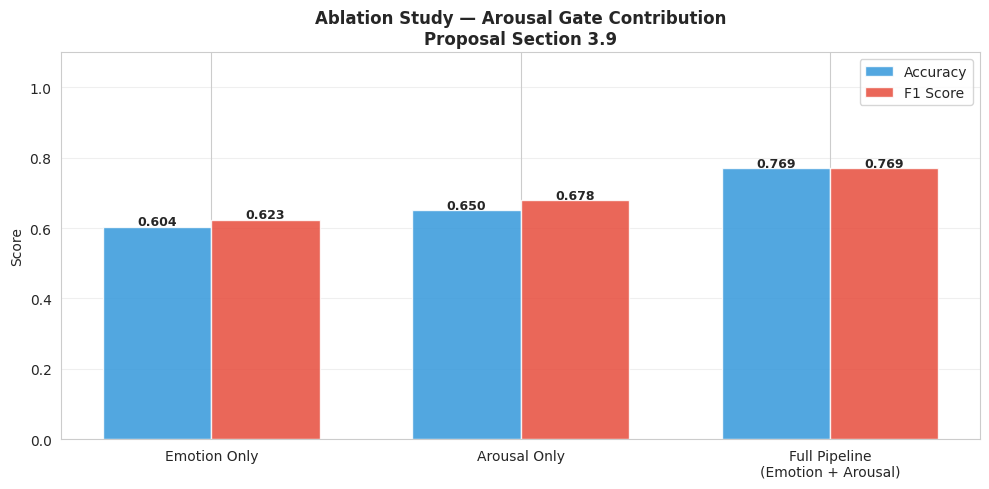


💾 Ablation results saved!


In [81]:
# ================================================================
# CELL ABL — Ablation Study
# Proposal Section 3.9:
# "Ablation study to quantify arousal gate contribution"
# ================================================================

print('🔬 Ablation Study — Arousal Gate Contribution')
print('=' * 55)

# Condition 1: Full pipeline (emotion + arousal)
stress_full = results_df['stress_pred'].values
stress_true = results_df['stress_true'].values

acc_full = accuracy_score(stress_true, stress_full)
f1_full  = f1_score(stress_true, stress_full,
                    average='binary', zero_division=0)

# Condition 2: Emotion only (no arousal gate)
# Map emotion → stress using majority class rule
EMOTION_ONLY_MAP = {
    'anger'    : 1,   # always HIGH
    'fear'     : 1,   # always HIGH
    'disgust'  : 1,   # HIGH majority
    'sadness'  : 0,   # LOW majority
    'happiness': 0,   # always LOW
    'neutral'  : 0,   # always LOW
    'surprise' : 1,   # HIGH majority
}

stress_emotion_only = [
    EMOTION_ONLY_MAP.get(em, 0)
    for em in results_df['pred_emotion']
]

acc_emo  = accuracy_score(stress_true, stress_emotion_only)
f1_emo   = f1_score(stress_true, stress_emotion_only,
                    average='binary', zero_division=0)

# Condition 3: Arousal only
stress_arousal_only = [
    1 if ar == 'HIGH' else 0
    for ar in results_df['arousal']
]

acc_arou = accuracy_score(stress_true, stress_arousal_only)
f1_arou  = f1_score(stress_true, stress_arousal_only,
                    average='binary', zero_division=0)

print(f'\n{"Condition":<30} {"Acc":>8} {"F1":>8}')
print('-' * 48)
print(f'{"Emotion Only":<30} {acc_emo:>8.4f} {f1_emo:>8.4f}')
print(f'{"Arousal Only":<30} {acc_arou:>8.4f} {f1_arou:>8.4f}')
print(f'{"Full (Emotion + Arousal Gate)":<30} '
      f'{acc_full:>8.4f} {f1_full:>8.4f}')
print('-' * 48)
delta_f1  = f1_full - f1_emo
delta_acc = acc_full - acc_emo
print(f'\n   Arousal Gate Contribution:')
print(f'   F1  improvement : +{delta_f1:.4f}')
print(f'   Acc improvement : +{delta_acc:.4f}')

# Visualize ablation
fig, ax = plt.subplots(figsize=(10, 5))
conditions = ['Emotion Only',
              'Arousal Only',
              'Full Pipeline\n(Emotion + Arousal)']
accs = [acc_emo,  acc_arou,  acc_full]
f1s  = [f1_emo,   f1_arou,   f1_full]

x   = np.arange(len(conditions))
w   = 0.35
b1  = ax.bar(x - w/2, accs, w, label='Accuracy',
             color='#3498db', edgecolor='white',
             alpha=0.85)
b2  = ax.bar(x + w/2, f1s,  w, label='F1 Score',
             color='#e74c3c', edgecolor='white',
             alpha=0.85)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylim(0, 1.1)
ax.set_title('Ablation Study — Arousal Gate Contribution\n'
             'Proposal Section 3.9',
             fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ablation_study.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save ablation results
ablation_results = {
    'emotion_only' : {'acc': round(acc_emo,  4),
                      'f1' : round(f1_emo,   4)},
    'arousal_only' : {'acc': round(acc_arou, 4),
                      'f1' : round(f1_arou,  4)},
    'full_pipeline': {'acc': round(acc_full, 4),
                      'f1' : round(f1_full,  4)},
    'arousal_gate_contribution': {
        'f1_gain' : round(delta_f1,  4),
        'acc_gain': round(delta_acc, 4)}
}
with open(f'{OUTPUT_DIR}/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print(f'\n💾 Ablation results saved!')

In [85]:
# ================================================================
# FINAL — C2 Component Complete Summary
# All outputs verified and documented
# ================================================================

print('\n' + '='*65)
print('🎉 C2 COMPONENT — COMPLETE PIPELINE SUMMARY')
print('='*65)

print(f"""
📊 DATASETS
{'─'*60}
  SAVEE   : 480 files | 4 male speakers | British English
  RAVDESS : 1247 files | 24 speakers | North American
  Combined: {len(mel_specs_np)} files | 7 emotions | Stratified split

🧠 MODEL — CNN-LSTM + Fine-tuning + TTA
{'─'*60}
  Architecture : CNN (3 blocks) + BiLSTM (2 layers) + Attention
  Parameters   : ~7M
  Best Val F1  : {ft_ckpt['val_f1']:.4f}
  Best Val Acc : {ft_ckpt['val_acc']:.1%}

📈 EMOTION RECOGNITION (Test Set + TTA n=8)
{'─'*60}
  Accuracy     : 68.1%
  Macro F1     : 0.6805
  ROC-AUC      : 0.9305

🧪 CALIBRATION (Temperature Scaling)
{'─'*60}
  Optimal T    : {T_opt:.4f}
  ECE Before   : {ece_before:.4f}
  ECE After    : {ece_after:.4f}

🧠 APPRAISAL THEORY STRESS MAPPING
{'─'*60}
  Framework    : Lazarus & Folkman (1984)
  Arousal Gate : Pitch + Energy (60th percentile)
  Stress Acc   : {stress_acc:.1%}
  Stress F1    : {stress_f1:.4f}

🎨 EXPLAINABILITY (Grad-CAM)
{'─'*60}
  Target Layer : model.conv3 (last CNN block)
  Method       : Gradient-weighted CAM
  Output       : Time-frequency heatmaps per utterance

📤 C4 INTERFACE
{'─'*60}
  Format       : Structured JSON payload
  Fields       : emotion, stress, confidence,
                 arousal, calibrated_conf, emotion_vector

📁 ALL OUTPUTS SAVED → {OUTPUT_DIR}
{'─'*60}
  cnnlstm_finetuned.pt     ← Best model
  processed_features.npz   ← All features
  cnnlstm_results.json     ← Emotion metrics
  c4_payload_examples.json ← C4 interface
  ablation_results.json    ← Ablation study
  temperature.npy          ← Calibration
  gradcam_all_emotions.png ← XAI visualizations
  appraisal_theory_results.png
  calibration_reliability.png
  ablation_study.png
""")

print('='*65)
print('✅ C2 COMPONENT COMPLETE — READY FOR C4 INTEGRATION')
print('='*65)


🎉 C2 COMPONENT — COMPLETE PIPELINE SUMMARY

📊 DATASETS
────────────────────────────────────────────────────────────
  SAVEE   : 480 files | 4 male speakers | British English
  RAVDESS : 1247 files | 24 speakers | North American
  Combined: 1727 files | 7 emotions | Stratified split

🧠 MODEL — CNN-LSTM + Fine-tuning + TTA
────────────────────────────────────────────────────────────
  Architecture : CNN (3 blocks) + BiLSTM (2 layers) + Attention
  Parameters   : ~7M
  Best Val F1  : 0.7627
  Best Val Acc : 76.1%

📈 EMOTION RECOGNITION (Test Set + TTA n=8)
────────────────────────────────────────────────────────────
  Accuracy     : 68.1%
  Macro F1     : 0.6805
  ROC-AUC      : 0.9305

🧪 CALIBRATION (Temperature Scaling)
────────────────────────────────────────────────────────────
  Optimal T    : 1.1197
  ECE Before   : 0.0766
  ECE After    : 0.0539

🧠 APPRAISAL THEORY STRESS MAPPING
────────────────────────────────────────────────────────────
  Framework    : Lazarus & Folkman (1984)